In [1]:
pip install imblearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.1/236.1 kB 12.3 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import os

In [4]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss, recall_score, accuracy_score, precision_score, f1_score,classification_report,confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, auc


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
%cd /content/drive/MyDrive/ozyegin-1/ozyegin/

/content/drive/MyDrive/ozyegin-1/ozyegin


###  UCSF  --arterial  -- aml

In [ ]:
reg = pd.read_csv('CSV/phase_reg_key.csv')


In [7]:
dd1= pd.read_csv('CSV/dilatedOriginal.csv')

In [8]:
dd1.shape

(8, 1180)

In [9]:
pd.set_option("display.max_rows",1200)

In [ ]:
dd1.iloc[1,:]

,1
PID,45Nh52EJwK
label,Unknown
tumor_type,2.0
pathology,angiomyolipoma
pathology_grade,NaN
Patient_Age,058Y
Patient_Sex,F
Manufacturer,GE MEDICAL SYSTEMS LightSpeed VCT
phase,arterial
ct_spacing_mm,"[0.8183590173721313, 0.8183590173721313, 2.5]"


In [10]:
dd1['augmentation'] = 'dilated'
dd1['source_subset'] = 'Original'


In [11]:
pd.set_option("display.max_rows",1500)

In [12]:
dd2= pd.read_csv('CSV/dilatedResized.csv')

In [13]:
dd2.shape

(3, 1180)

In [14]:
dd2['augmentation'] = 'dilated'
dd2['source_subset'] = 'Resized'

In [15]:
df1= pd.read_csv('CSV/flippedOriginal.csv')

In [16]:
df1.shape

(8, 1180)

In [17]:
df1['augmentation'] = 'flipped'
df1['source_subset'] = 'Original'

In [18]:
df2 = pd.read_csv('CSV/flippedResized.csv')

In [19]:
df2.shape

(3, 1180)

In [20]:
df2['augmentation'] = 'flipped'
df2['source_subset'] = 'Resized'

In [21]:
de1 = pd.read_csv('CSV/erodedOriginal.csv')

In [22]:
de1.shape

(8, 1180)

In [23]:
de1['augmentation'] = 'eroded'
de1['source_subset'] = 'Original'

In [24]:
de2 = pd.read_csv('CSV/erodedResized.csv')

In [25]:
de2.shape

(3, 1180)

In [26]:
de2['augmentation'] = 'eroded'
de2['source_subset'] = 'Resized'

In [27]:
do = pd.read_csv('CSV/originalitself.csv')

In [28]:
do.shape

(8, 1180)

In [29]:
do['augmentation'] = 'NOT'
do['source_subset'] = 'Original'

In [30]:
dr = pd.read_csv('CSV/resizeditself.csv')

In [31]:
dr.shape

(3, 1180)

In [32]:
dr['augmentation'] = 'NOT'
dr['source_subset'] = 'Resized'

In [33]:
drcc1 = pd.read_csv('CSV/rcc1.csv')
drcc1.shape

(23, 1180)

In [34]:
drcc1['augmentation'] = 'NOT'
drcc1['source_subset'] = 'Original-RCC'

In [35]:
drcc2 = pd.read_csv('CSV/rcc2.csv')

In [36]:
drcc2.shape

(35, 1180)

In [37]:
drcc2['augmentation'] = 'NOT'
drcc2['source_subset'] = 'Original-RCC'

In [38]:
dfA= pd.concat([dd1,dd2,df1,df2,de1,de2,do,dr], axis = 0, ignore_index= 1)

In [39]:
dfA.shape

(44, 1182)

In [40]:
dfA['target'] = 1

In [41]:
dfR = pd.concat([drcc1,drcc2], axis = 0, ignore_index= 1)

In [42]:
dfR.shape

(58, 1182)

In [43]:
dfR['target'] = 0

In [ ]:
dfA.columns

Index(['PID', 'label', 'tumor_type', 'pathology', 'pathology_grade',
       'Patient_Age', 'Patient_Sex', 'Manufacturer', 'phase', 'ct_spacing_mm',
       ...
       'diagnostics_Mask-interpolated_VoxelNum',
       'diagnostics_Mask-interpolated_VolumeNum',
       'diagnostics_Mask-interpolated_CenterOfMassIndex',
       'diagnostics_Mask-interpolated_CenterOfMass',
       'diagnostics_Mask-interpolated_Mean',
       'diagnostics_Mask-interpolated_Minimum',
       'diagnostics_Mask-interpolated_Maximum', 'augmentation',
       'source_subset', 'target'],
      dtype='object', length=1183)

In [ ]:
'shape','firstorder','glcm','glrlm','glszm','gldm','ngtdm'
'original','log-sigma-1-0-mm-3D','wavelet-LLH','wavelet-HLL','wavelet-HLH','wavelet-HHL','wavelet-HHH','wavelet-LLL',
'diagnostics_Image','diagnostics_Mask'

In [ ]:
drcc2.columns.tolist()[-500:]

['wavelet-HLL_firstorder_InterquartileRange',
 'wavelet-HLL_firstorder_Kurtosis',
 'wavelet-HLL_firstorder_Maximum',
 'wavelet-HLL_firstorder_MeanAbsoluteDeviation',
 'wavelet-HLL_firstorder_Mean',
 'wavelet-HLL_firstorder_Median',
 'wavelet-HLL_firstorder_Minimum',
 'wavelet-HLL_firstorder_Range',
 'wavelet-HLL_firstorder_RobustMeanAbsoluteDeviation',
 'wavelet-HLL_firstorder_RootMeanSquared',
 'wavelet-HLL_firstorder_Skewness',
 'wavelet-HLL_firstorder_TotalEnergy',
 'wavelet-HLL_firstorder_Uniformity',
 'wavelet-HLL_firstorder_Variance',
 'wavelet-HLL_glcm_Autocorrelation',
 'wavelet-HLL_glcm_ClusterProminence',
 'wavelet-HLL_glcm_ClusterShade',
 'wavelet-HLL_glcm_ClusterTendency',
 'wavelet-HLL_glcm_Contrast',
 'wavelet-HLL_glcm_Correlation',
 'wavelet-HLL_glcm_DifferenceAverage',
 'wavelet-HLL_glcm_DifferenceEntropy',
 'wavelet-HLL_glcm_DifferenceVariance',
 'wavelet-HLL_glcm_Id',
 'wavelet-HLL_glcm_Idm',
 'wavelet-HLL_glcm_Idmn',
 'wavelet-HLL_glcm_Idn',
 'wavelet-HLL_glcm_Imc1',

In [ ]:
 drcc2.loc[0:5,['diagnostics_Versions_PyRadiomics',
 'diagnostics_Versions_Numpy',
 'diagnostics_Versions_SimpleITK',
 'diagnostics_Versions_PyWavelet',
 'diagnostics_Versions_Python',
 'diagnostics_Configuration_Settings',
 'diagnostics_Configuration_EnabledImageTypes',
 'diagnostics_Image-original_Hash',
 'diagnostics_Image-original_Dimensionality',
 'diagnostics_Image-original_Spacing',
 'diagnostics_Image-original_Size',
 'diagnostics_Image-original_Mean',
 'diagnostics_Image-original_Minimum',
 'diagnostics_Image-original_Maximum',
 'diagnostics_Mask-original_Hash',
 'diagnostics_Mask-original_Spacing',
 'diagnostics_Mask-original_Size',
 'diagnostics_Mask-original_BoundingBox',
 'diagnostics_Mask-original_VoxelNum',
 'diagnostics_Mask-original_VolumeNum',
 'diagnostics_Mask-original_CenterOfMassIndex',
 'diagnostics_Mask-original_CenterOfMass',
 'diagnostics_Image-interpolated_Spacing',
 'diagnostics_Image-interpolated_Size',
 'diagnostics_Image-interpolated_Mean',
 'diagnostics_Image-interpolated_Minimum',
 'diagnostics_Image-interpolated_Maximum',
 'diagnostics_Mask-interpolated_Spacing',
 'diagnostics_Mask-interpolated_Size',
 'diagnostics_Mask-interpolated_BoundingBox',
 'diagnostics_Mask-interpolated_VoxelNum',
 'diagnostics_Mask-interpolated_VolumeNum',
 'diagnostics_Mask-interpolated_CenterOfMassIndex',
 'diagnostics_Mask-interpolated_CenterOfMass',
 'diagnostics_Mask-interpolated_Mean',
 'diagnostics_Mask-interpolated_Minimum',
 'diagnostics_Mask-interpolated_Maximum']]

,diagnostics_Versions_PyRadiomics,diagnostics_Versions_Numpy,diagnostics_Versions_SimpleITK,diagnostics_Versions_PyWavelet,diagnostics_Versions_Python,diagnostics_Configuration_Settings,diagnostics_Configuration_EnabledImageTypes,diagnostics_Image-original_Hash,diagnostics_Image-original_Dimensionality,diagnostics_Image-original_Spacing,...,diagnostics_Mask-interpolated_Spacing,diagnostics_Mask-interpolated_Size,diagnostics_Mask-interpolated_BoundingBox,diagnostics_Mask-interpolated_VoxelNum,diagnostics_Mask-interpolated_VolumeNum,diagnostics_Mask-interpolated_CenterOfMassIndex,diagnostics_Mask-interpolated_CenterOfMass,diagnostics_Mask-interpolated_Mean,diagnostics_Mask-interpolated_Minimum,diagnostics_Mask-interpolated_Maximum
0,3.1.1.dev111+g8ed579383,2.0.2,2.5.5,1.8.0,3.12.13,"{'minimumROIDimensions': 2, 'minimumROISize': ...","{'Original': {}, 'LoG': {'sigma': [1.0, 2.0, 3...",59ea94d5a8ee7e0f4f3c347d8826ae6b264fea96,3D,"(0.748046875, 0.748046875, 5.0)",...,"(1.0, 1.0, 1.0)","(65, 58, 47)","(11, 11, 13, 42, 36, 25)",23510,1,"(np.float64(30.163334751169714), np.float64(27...","(106.28931131366971, 204.22253122009252, 72.75...",110.385463,73.967034,133.799697
1,3.1.1.dev111+g8ed579383,2.0.2,2.5.5,1.8.0,3.12.13,"{'minimumROIDimensions': 2, 'minimumROISize': ...","{'Original': {}, 'LoG': {'sigma': [1.0, 2.0, 3...",4b50b7f24ac71b549a6ffcbcac4e59ed53997b69,3D,"(0.8007810115814209, 0.8007810115814209, 1.25)",...,"(1.0, 1.0, 1.0)","(58, 68, 40)","(11, 11, 11, 36, 45, 18)",18688,1,"(np.float64(27.88527397260274), np.float64(35....","(154.9780474697074, 240.66469130532386, 195.39...",88.085791,68.591536,108.060518
2,3.1.1.dev111+g8ed579383,2.0.2,2.5.5,1.8.0,3.12.13,"{'minimumROIDimensions': 2, 'minimumROISize': ...","{'Original': {}, 'LoG': {'sigma': [1.0, 2.0, 3...",a6356915abf15758cee1b2154f527a1c1f6ee05a,3D,"(0.6053545475006104, 0.6060749888420105, 2.483...",...,"(1.0, 1.0, 1.0)","(90, 89, 81)","(11, 11, 13, 67, 67, 59)",172000,1,"(np.float64(44.23072674418604), np.float64(44....","(228.4276993825547, 159.6435385248273, 44.6741...",77.006800,-5.782299,101.667164
3,3.1.1.dev111+g8ed579383,2.0.2,2.5.5,1.8.0,3.12.13,"{'minimumROIDimensions': 2, 'minimumROISize': ...","{'Original': {}, 'LoG': {'sigma': [1.0, 2.0, 3...",e98aeddc307abf41a2a62b7283cb726d7b0d9122,3D,"(0.69921875, 0.69921875, 2.0)",...,"(1.0, 1.0, 1.0)","(44, 45, 43)","(11, 11, 11, 22, 23, 22)",6988,1,"(np.float64(21.938465941614197), np.float64(21...","(286.0888565666142, 185.74798650364912, 268.40...",109.018005,69.219613,137.704065
4,3.1.1.dev111+g8ed579383,2.0.2,2.5.5,1.8.0,3.12.13,"{'minimumROIDimensions': 2, 'minimumROISize': ...","{'Original': {}, 'LoG': {'sigma': [1.0, 2.0, 3...",4816a902ba48bbb8ef1543afd9573512b2a16bcc,3D,"(0.7409272789955139, 0.7409952282905579, 1.999...",...,"(1.0, 1.0, 1.0)","(90, 83, 86)","(11, 10, 12, 68, 62, 64)",131402,1,"(np.float64(42.93126436431714), np.float64(41....","(264.06080072481933, 244.89302196698742, 202.4...",102.201652,80.424154,135.642127
5,3.1.1.dev111+g8ed579383,2.0.2,2.5.5,1.8.0,3.12.13,"{'minimumROIDimensions': 2, 'minimumROISize': ...","{'Original': {}, 'LoG': {'sigma': [1.0, 2.0, 3...",66a39a208efaf7284ec4ad700e35f721afe76728,3D,"(0.9760000109672546, 0.9760000109672546, 0.800...",...,"(1.0, 1.0, 1.0)","(63, 76, 57)","(11, 11, 11, 41, 54, 35)",56134,1,"(np.float64(31.143727509174475), np.float64(35...","(100.21872749725355, 271.8312439756802, 125.00...",90.560871,-21.239421,164.896676


In [ ]:
dfRS = dfR.sample(44)

In [ ]:
dfRS.index

Index([49, 50, 39, 26, 12, 15, 16, 17, 40, 38, 21, 33, 35, 37, 41, 18,  9, 10,
       34, 42, 13, 36, 43,  8, 14,  1, 51, 11,  3, 52,  4, 47, 24,  5,  7,  2,
       22, 32, 23, 30, 19, 56, 44, 20],
      dtype='int64')

23 Component

Index([25, 40,  3, 53, 11, 49, 51, 54, 52, 34, 23, 10, 21,  0, 19, 43, 33,  7,
        9, 47,  5, 46, 29, 41, 44, 20,  4, 36, 14, 57, 17, 24, 28, 37,  6,  2,
       38, 45, 48, 12, 27, 39, 56, 26],
      dtype='int64')

['5VcthT0eZp',
 'Xr9i2bphzA',
 '7I8VYuMftc',
 'uDgXxF1ila',
 'Iswe2OQvvA',
 'rHrX0BpUcX',
 'tWHXsbhqIm',
 'ubDnfl6DDg',
 'tX93r2Wx5X',
 'QcyodOs3Q5',
 '475HQrHo5Y',
 'IjFflm1TPw',
 'gN54OjVPDG',
 '58tEvb2lRX',
 'aiMWXsF8Vr',
 'fUuItGkARL',
 'QNDAa9SoJ7',
 'DcvE7Qbk7u',
 'FamKf6j9Ly',
 'mpR4Lkg6WJ',
 'ALZseu8axq',
 'kuLnglAoYW',
 'ByY2Oz0f16',
 'ZJqn6Mcg6s',
 'fvHwwVjeqZ',
 'fFUuqn2Cdh',
 '7WV4qCLwpN',
 'U12PW8VufV',
 'QPHEXsfL0J',
 'zmwtNTDvF2',
 'X910IACtaz',
 '5OjuFGw7YB',
 'BRvha4ynJQ',
 'VyIRlglwu4',
 'CSgNAkMSUq',
 '6S3AR8Qv8n',
 'VzNDxCT8fa',
 'kQCfJp5tkL',
 'pWfvOWoiHg',
 'L7exPPUF3N',
 'B3uXUCxmk3',
 'WC3J7Q0yat',
 'xStGbIsHhB',
 '9zuctMrDLy']

In [ ]:
dfRS.PID.to_list()

['5VcthT0eZp',
 'Xr9i2bphzA',
 '7I8VYuMftc',
 'uDgXxF1ila',
 'Iswe2OQvvA',
 'rHrX0BpUcX',
 'tWHXsbhqIm',
 'ubDnfl6DDg',
 'tX93r2Wx5X',
 'QcyodOs3Q5',
 '475HQrHo5Y',
 'IjFflm1TPw',
 'gN54OjVPDG',
 '58tEvb2lRX',
 'aiMWXsF8Vr',
 'fUuItGkARL',
 'QNDAa9SoJ7',
 'DcvE7Qbk7u',
 'FamKf6j9Ly',
 'mpR4Lkg6WJ',
 'ALZseu8axq',
 'kuLnglAoYW',
 'ByY2Oz0f16',
 'ZJqn6Mcg6s',
 'fvHwwVjeqZ',
 'fFUuqn2Cdh',
 '7WV4qCLwpN',
 'U12PW8VufV',
 'QPHEXsfL0J',
 'zmwtNTDvF2',
 'X910IACtaz',
 '5OjuFGw7YB',
 'BRvha4ynJQ',
 'VyIRlglwu4',
 'CSgNAkMSUq',
 '6S3AR8Qv8n',
 'VzNDxCT8fa',
 'kQCfJp5tkL',
 'pWfvOWoiHg',
 'L7exPPUF3N',
 'B3uXUCxmk3',
 'WC3J7Q0yat',
 'xStGbIsHhB',
 '9zuctMrDLy']

In [ ]:
dfU = pd.concat([dfA,dfRS], axis = 0, ignore_index= 1)

In [ ]:
dfU.drop('pathology_grade', axis =1, inplace= True)

In [ ]:
dfU['case_id'] = dfU.PID

In [ ]:
y = dfU['target']

In [ ]:
df_backup = dfU[['case_id','augmentation','source_subset','target']]

In [ ]:
df_backup.sample(10)

,case_id,augmentation,source_subset,target
30,JMfIEEWlAz,eroded,Resized,1
69,5CZeU5xT7S,NOT,Original-RCC,0
74,7WV4qCLwpN,NOT,Original-RCC,0
19,JMfIEEWlAz,flipped,Resized,1
61,IjFflm1TPw,NOT,Original-RCC,0
77,ALZseu8axq,NOT,Original-RCC,0
46,WC3J7Q0yat,NOT,Original-RCC,0
55,QNDAa9SoJ7,NOT,Original-RCC,0
5,pXwitKy0oU,dilated,Original,1
78,DcvE7Qbk7u,NOT,Original-RCC,0


In [ ]:
dfU.isnull().sum()

PID                                      0
label                                    0
tumor_type                               0
pathology                                0
Patient_Age                              0
                                        ..
diagnostics_Mask-interpolated_Maximum    0
augmentation                             0
source_subset                            0
target                                   0
case_id                                  0
Length: 1183, dtype: int64

In [ ]:
dfU.select_dtypes(include='object').groupby('Manufacturer')['Manufacturer'].count()

Manufacturer
GE MEDICAL SYSTEMS Discovery CT750 HD    10
GE MEDICAL SYSTEMS GENESIS_ZEUS           1
GE MEDICAL SYSTEMS HiSpeed CT/i           4
GE MEDICAL SYSTEMS LightSpeed Pro 16      1
GE MEDICAL SYSTEMS LightSpeed Ultra       4
GE MEDICAL SYSTEMS LightSpeed VCT        20
GE MEDICAL SYSTEMS LightSpeed16           7
GE MEDICAL SYSTEMS Optima CT660           6
Philips Brilliance 64                     2
Philips Mx8000 IDT                        1
Philips Mx8000 IDT 16                     7
SIEMENS Biograph 64                       1
SIEMENS SOMATOM Definition AS             2
SIEMENS SOMATOM Definition AS+            3
SIEMENS SOMATOM Definition Flash          1
SIEMENS Sensation 16                      2
SIEMENS Sensation 40                      4
SIEMENS Sensation 64                      2
TOSHIBA Aquilion                         10
Name: Manufacturer, dtype: int64

(array([-200.,    0.,  200.,  400.,  600.,  800., 1000., 1200., 1400.]),
 [Text(-200.0, 0, 'wavelet-HHH_firstorder_10Percentile'),
  Text(0.0, 0, 'tumor_type'),
  Text(200.0, 0, 'log-sigma-1-0-mm-3D_ngtdm_Contrast'),
  Text(400.0, 0, 'wavelet-LLH_firstorder_RobustMeanAbsoluteDeviation'),
  Text(600.0, 0, 'wavelet-LHH_glcm_DifferenceVariance'),
  Text(800.0, 0, 'wavelet-HLH_glcm_SumEntropy'),
  Text(1000.0, 0, 'wavelet-HHH_glrlm_RunVariance'),
  Text(1200.0, 0, ''),
  Text(1400.0, 0, '')])

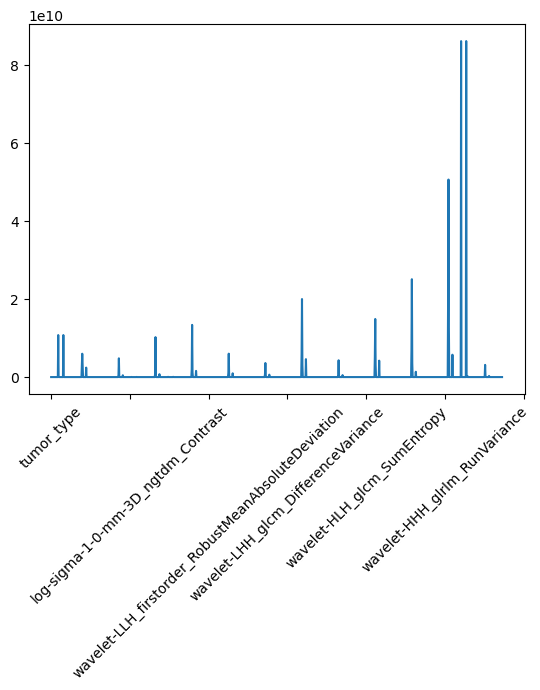

In [ ]:
dfU.groupby('Manufacturer')[dfU.select_dtypes(exclude='object').columns].mean().sum().plot.line()
plt.xticks(rotation = 45)

In [ ]:

from sklearn.decomposition import PCA

In [ ]:
dfU.select_dtypes(exclude = "object").shape

(88, 1146)

In [ ]:
dfU.drop(columns=['case_id','augmentation','source_subset','target'],axis=1).select_dtypes(exclude = "object").shape

(88, 1145)

In [ ]:
df_pca = dfU.drop(['case_id','augmentation','source_subset','target','tumor_type'],axis=1).select_dtypes(exclude = "object")

In [ ]:
df_pca.shape

(88, 1144)

In [ ]:
sc = StandardScaler()

In [ ]:
scaled_df_pca = sc.fit_transform(df_pca)

In [ ]:
pc = PCA().fit(scaled_df_pca)

In [ ]:
len(pc.explained_variance_ratio_)

88

Text(0, 0.5, 'Variance Ratio')

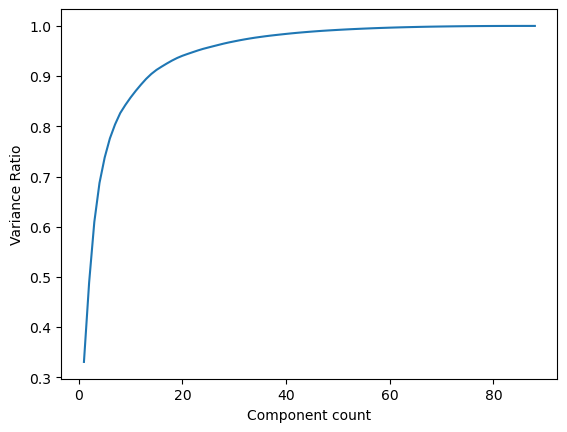

In [ ]:
x = range(1,89)
plt.plot(x, np.cumsum(pc.explained_variance_ratio_),)
plt.xlabel("Component count")
plt.ylabel("Variance Ratio")

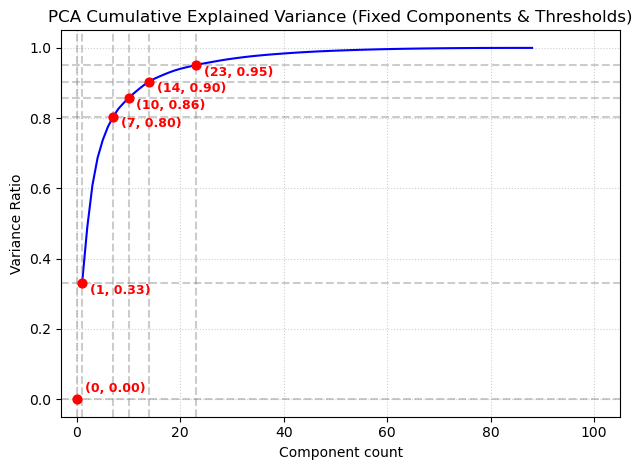

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Your original setup
x = range(1, 89)
cum_sum = np.cumsum(pc.explained_variance_ratio_)

# Create the base plot
plt.plot(x, cum_sum, color='blue', label='Cumulative Variance')
plt.xlabel("Component count")
plt.ylabel("Variance Ratio")

# Keep a set of coordinates to avoid duplicate labels if thresholds and components overlap
processed_points = set()

# --- 1. Process specific component counts ---
target_components = [0, 1, 10]

for c in target_components:
    if c == 0:
        comp_count, actual_val = 0, 0.0
    elif c in x:
        idx = list(x).index(c)
        comp_count, actual_val = c, cum_sum[idx]
    else:
        continue
    processed_points.add((comp_count, actual_val))

# --- 2. Process threshold variables from the former code ---
thresholds = [0.80, 0.90, 0.95]

for t in thresholds:
    under_threshold_indices = np.where(cum_sum >= t)[0]
    if len(under_threshold_indices) > 0:
        idx = under_threshold_indices[0]
        comp_count, actual_val = x[idx], cum_sum[idx]
        processed_points.add((comp_count, actual_val))

# --- 3. Plot and Annotate all unique critical points ---
for comp_count, actual_val in sorted(processed_points):
    # Plot a red dot on the critical point
    plt.scatter(comp_count, actual_val, color='red', s=40, zorder=5)

    # Draw dashed guide lines to the axes
    plt.axvline(x=comp_count, color='gray', linestyle='--', alpha=0.4)
    plt.axhline(y=actual_val, color='gray', linestyle='--', alpha=0.4)

    # Dynamic text positioning: if it's near (0,0), push text up. Otherwise, push it down.
    y_offset = 0.02 if actual_val < 0.1 else -0.03

    # Display the exact axis numbers next to the point
    plt.text(comp_count + 1.5, actual_val + y_offset, f"({comp_count}, {actual_val:.2f})",
             fontsize=9, color='red', weight='bold')

plt.title("PCA Cumulative Explained Variance (Fixed Components & Thresholds)")
plt.grid(True, linestyle=':', alpha=0.6)

# Provide some breathing room on the canvas edges for the labels
plt.xlim(-3, 105)
plt.ylim(-0.05, 1.05)

plt.tight_layout()

# Save or display the plot
plt.savefig("explained_variance_plot.png")

In [ ]:
scaled_df_pca.shape

(88, 1144)

In [ ]:
pca = PCA(n_components=23)

In [ ]:
scaled_df_pca.shape

(88, 1144)

In [ ]:
p_scaled = pca.fit_transform(scaled_df_pca)

In [ ]:
p_scaled

array([[-15.89787076,   5.36572377,   6.68807866, ...,  -0.90963541,
          1.40025281,   0.54257441],
       [ -6.86277869,  -0.78579266,   7.97079775, ...,   0.40373071,
          0.874532  ,   0.33687405],
       [ -4.07334153,  -4.79038541,  19.25510228, ...,  -0.07455778,
          1.82643637,  -2.90393135],
       ...,
       [ -0.4637616 ,   2.56357578,  12.55687927, ...,  -2.13609226,
         -1.07826956,   0.8057429 ],
       [-20.01316337,   1.17844048,  18.76819607, ...,   4.6597253 ,
          4.43381166,  -3.96612536],
       [ -0.65167734,   3.42944735,  -9.52168936, ...,   2.33628762,
          1.924806  ,  -0.27779808]])

In [ ]:
X = p_scaled

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.1, random_state= 43 )

In [ ]:
def eval_metric(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_pred = model.predict(X_test)

    print("Test_Set")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print()
    print("Train_Set")
    print(confusion_matrix(y_train, y_train_pred))
    print(classification_report(y_train, y_train_pred))

### SVM

In [ ]:
from sklearn.svm import SVC
svc = SVC(kernel='rbf')

In [ ]:
svc.fit(X_train,y_train)

SVC()

In [ ]:
y_pred = svc.predict(X_test)

In [ ]:
y_pred

array([0, 0, 0, 0, 0, 1, 1, 0, 0])

In [ ]:
y_test

46    0
57    0
2     1
79    0
82    0
54    0
13    1
5     1
69    0
Name: target, dtype: int64

![image.png](attachment:image.png)

In [ ]:
a = dfU.loc[y_test.index,['case_id','augmentation','source_subset','target']]

In [ ]:
a

,case_id,augmentation,source_subset,target
46,7I8VYuMftc,NOT,Original-RCC,0
57,58tEvb2lRX,NOT,Original-RCC,0
2,STimK6AjK1,dilated,Original,1
79,6S3AR8Qv8n,NOT,Original-RCC,0
82,pWfvOWoiHg,NOT,Original-RCC,0
54,475HQrHo5Y,NOT,Original-RCC,0
13,STimK6AjK1,flipped,Original,1
5,pXwitKy0oU,dilated,Original,1
69,fFUuqn2Cdh,NOT,Original-RCC,0


In [ ]:
a['predict'] = y_pred

In [ ]:
a

,case_id,augmentation,source_subset,target,predict
46,7I8VYuMftc,NOT,Original-RCC,0,0
57,58tEvb2lRX,NOT,Original-RCC,0,0
2,STimK6AjK1,dilated,Original,1,0
79,6S3AR8Qv8n,NOT,Original-RCC,0,0
82,pWfvOWoiHg,NOT,Original-RCC,0,0
54,475HQrHo5Y,NOT,Original-RCC,0,1
13,STimK6AjK1,flipped,Original,1,1
5,pXwitKy0oU,dilated,Original,1,0
69,fFUuqn2Cdh,NOT,Original-RCC,0,0


In [ ]:
eval_metric(svc, X_train, y_train, X_test, y_test)

Test_Set
[[5 1]
 [2 1]]
              precision    recall  f1-score   support

           0       0.71      0.83      0.77         6
           1       0.50      0.33      0.40         3

    accuracy                           0.67         9
   macro avg       0.61      0.58      0.58         9
weighted avg       0.64      0.67      0.65         9


Train_Set
[[30  8]
 [ 1 40]]
              precision    recall  f1-score   support

           0       0.97      0.79      0.87        38
           1       0.83      0.98      0.90        41

    accuracy                           0.89        79
   macro avg       0.90      0.88      0.88        79
weighted avg       0.90      0.89      0.88        79



In [ ]:
from sklearn.metrics import RocCurveDisplay,PrecisionRecallDisplay,ConfusionMatrixDisplay

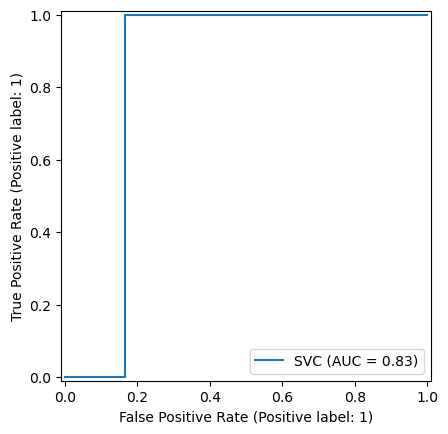

In [ ]:
RocCurveDisplay.from_estimator(svc,X_test,y_test)
plt.show()

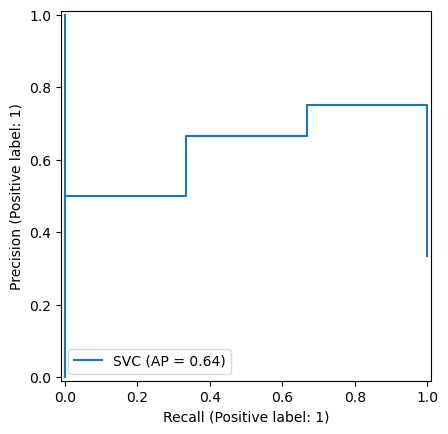

In [ ]:
PrecisionRecallDisplay.from_estimator(svc,X_test,y_test)
plt.show()

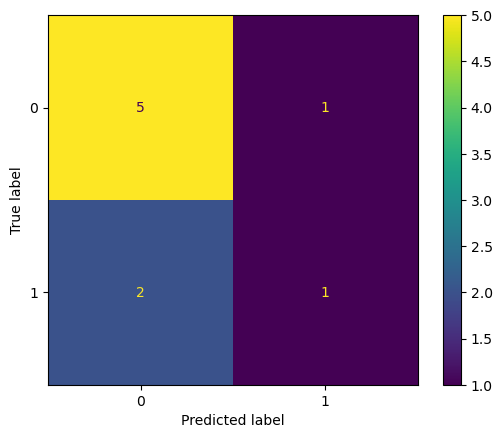

In [ ]:
ConfusionMatrixDisplay.from_estimator(svc,X_test,y_test)
plt.show()

### XGBoost

In [ ]:
from xgboost import XGBClassifier
xg = XGBClassifier()

In [ ]:
xg.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred = xg.predict(X_test)

In [ ]:
eval_metric(xg,X_train,y_train,X_test,y_test)

Test_Set
[[5 1]
 [1 2]]
              precision    recall  f1-score   support

           0       0.83      0.83      0.83         6
           1       0.67      0.67      0.67         3

    accuracy                           0.78         9
   macro avg       0.75      0.75      0.75         9
weighted avg       0.78      0.78      0.78         9


Train_Set
[[38  0]
 [ 0 41]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        38
           1       1.00      1.00      1.00        41

    accuracy                           1.00        79
   macro avg       1.00      1.00      1.00        79
weighted avg       1.00      1.00      1.00        79



In [ ]:
from sklearn.metrics import confusion_matrix,classification_report
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
cm = confusion_matrix(y_test,y_pred)

In [ ]:
cm

array([[5, 1],
       [1, 2]])

![image.png](attachment:0bd7398a-b473-4f1d-a202-77f92543df85.png)

### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression()

In [ ]:
classifier.fit(X_train,y_train)

LogisticRegression()

In [ ]:
y_pred = classifier.predict(X_test)

In [ ]:

eval_metric(classifier, X_train, y_train, X_test, y_test)

Test_Set
[[5 1]
 [1 2]]
              precision    recall  f1-score   support

           0       0.83      0.83      0.83         6
           1       0.67      0.67      0.67         3

    accuracy                           0.78         9
   macro avg       0.75      0.75      0.75         9
weighted avg       0.78      0.78      0.78         9


Train_Set
[[34  4]
 [ 4 37]]
              precision    recall  f1-score   support

           0       0.89      0.89      0.89        38
           1       0.90      0.90      0.90        41

    accuracy                           0.90        79
   macro avg       0.90      0.90      0.90        79
weighted avg       0.90      0.90      0.90        79



In [ ]:
pol_feature = PolynomialFeatures(degree=2)
X_train = pol_feature.fit_transform(X_train)

In [ ]:
X_train.shape

(79, 300)

In [ ]:
X_test = pol_feature.transform(X_test)

In [ ]:
classifier.fit(X_train,y_train)

LogisticRegression()

In [ ]:
y_pred = classifier.predict(X_test)

In [ ]:

eval_metric(classifier, X_train, y_train, X_test, y_test)

Test_Set
[[5 1]
 [2 1]]
              precision    recall  f1-score   support

           0       0.71      0.83      0.77         6
           1       0.50      0.33      0.40         3

    accuracy                           0.67         9
   macro avg       0.61      0.58      0.58         9
weighted avg       0.64      0.67      0.65         9


Train_Set
[[38  0]
 [ 0 41]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        38
           1       1.00      1.00      1.00        41

    accuracy                           1.00        79
   macro avg       1.00      1.00      1.00        79
weighted avg       1.00      1.00      1.00        79



### TESTING NEVER SEEN CASES

In [ ]:
dft1 = pd.read_csv('CSV/test1.csv')
dft1.shape

(2, 1180)

In [ ]:
dft2 = pd.read_csv('CSV/test2.csv')
dft2.shape

(3, 1180)

In [ ]:
dfT =  pd.concat([dft1,dft2], axis = 0, ignore_index= 1)

In [ ]:
dfT.shape

(5, 1180)

In [ ]:
col_list = df_pca.columns.to_list()

In [ ]:
dfU.loc[:,col_list]

,mask_voxel_count,original_shape_Elongation,original_shape_Flatness,original_shape_LeastAxisLength,original_shape_MajorAxisLength,original_shape_Maximum2DDiameterColumn,original_shape_Maximum2DDiameterRow,original_shape_Maximum2DDiameterSlice,original_shape_Maximum3DDiameter,original_shape_MeshVolume,...,diagnostics_Mask-original_VoxelNum,diagnostics_Mask-original_VolumeNum,diagnostics_Image-interpolated_Mean,diagnostics_Image-interpolated_Minimum,diagnostics_Image-interpolated_Maximum,diagnostics_Mask-interpolated_VoxelNum,diagnostics_Mask-interpolated_VolumeNum,diagnostics_Mask-interpolated_Mean,diagnostics_Mask-interpolated_Minimum,diagnostics_Mask-interpolated_Maximum
0,42778,0.876849,0.855422,44.989674,52.593548,60.835845,63.134776,61.554854,68.278840,72956.541667,...,42778,1,66.833184,-13.432264,104.877320,73025,1,66.291850,53.140933,93.070440
1,51331,0.878046,0.695152,40.831704,58.737773,66.400301,58.830264,65.855903,73.627441,85475.875000,...,51331,1,95.173894,30.696134,180.325897,85545,1,98.531768,78.597424,150.642359
2,129552,0.852747,0.563577,47.799028,84.813666,81.215762,71.568149,102.825094,104.737768,200990.333333,...,129552,1,79.088292,-5.717799,103.807765,201086,1,80.296722,3.160067,103.133532
3,4274,0.937813,0.897855,19.000150,21.161704,24.186773,24.698178,25.495098,27.820855,5403.291667,...,4274,1,115.262925,-104.480156,192.683603,5430,1,122.921304,9.143851,169.727193
4,10674,0.740761,0.714621,27.966907,39.135298,41.340053,41.880783,36.124784,47.307505,20987.791667,...,10674,1,79.707439,-51.116383,138.721623,21030,1,82.487785,55.784986,107.448790
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,1422,0.883148,0.663019,11.334360,17.095071,16.643317,17.492856,19.209373,21.794495,1905.625000,...,1422,1,89.401980,73.746965,169.436028,1924,1,95.745366,74.295690,108.845700
84,119828,0.972461,0.808961,49.802279,61.563292,72.670489,72.249567,68.963759,73.348483,131323.250000,...,119828,1,93.316510,-23.177235,208.051762,131402,1,102.201652,80.424154,135.642127
85,79903,0.997174,0.792661,54.374557,68.597471,72.138755,69.462220,90.520716,92.309263,175836.666667,...,79903,1,88.762854,55.314839,322.361662,175932,1,97.777580,57.364347,141.232159
86,55592,0.907156,0.689452,51.911389,75.293693,76.295478,68.963759,98.595132,100.229736,184005.458333,...,55592,1,66.399308,-5.115776,127.005411,184100,1,69.653952,47.326367,93.614922


In [ ]:
#### dfT.loc[:,col_list]

In [ ]:
dfT_scaled = sc.transform(dfT.loc[:,col_list])

In [ ]:
dfT_scaled.shape

(5, 1144)

In [ ]:
scaled_df_pca.shape

(88, 1144)

In [ ]:
p_dfT_scaled = pca.transform(dfT_scaled)

In [ ]:
p_dfT_scaled.shape

(5, 23)

In [ ]:
svc.predict(p_dfT_scaled)

array([0, 0, 1, 1, 1])

In [ ]:
dfT.pathology

0    angiomyolipoma
1    angiomyolipoma
2        clear cell
3        clear cell
4       chromophobe
Name: pathology, dtype: object

In [ ]:
dfRS.pathology.value_counts()

pathology
clear cell     40
papillary       3
chromophobe     1
Name: count, dtype: int64

In [ ]:
dfU.tumor_type.value_counts()

tumor_type
0.0    58
2.0    44
Name: count, dtype: int64

In [ ]:
col_list[-50:-1]

['wavelet-LLL_glrlm_ShortRunHighGrayLevelEmphasis',
 'wavelet-LLL_glrlm_ShortRunLowGrayLevelEmphasis',
 'wavelet-LLL_glszm_GrayLevelNonUniformity',
 'wavelet-LLL_glszm_GrayLevelNonUniformityNormalized',
 'wavelet-LLL_glszm_GrayLevelVariance',
 'wavelet-LLL_glszm_HighGrayLevelZoneEmphasis',
 'wavelet-LLL_glszm_LargeAreaEmphasis',
 'wavelet-LLL_glszm_LargeAreaHighGrayLevelEmphasis',
 'wavelet-LLL_glszm_LargeAreaLowGrayLevelEmphasis',
 'wavelet-LLL_glszm_LowGrayLevelZoneEmphasis',
 'wavelet-LLL_glszm_SizeZoneNonUniformity',
 'wavelet-LLL_glszm_SizeZoneNonUniformityNormalized',
 'wavelet-LLL_glszm_SmallAreaEmphasis',
 'wavelet-LLL_glszm_SmallAreaHighGrayLevelEmphasis',
 'wavelet-LLL_glszm_SmallAreaLowGrayLevelEmphasis',
 'wavelet-LLL_glszm_ZoneEntropy',
 'wavelet-LLL_glszm_ZonePercentage',
 'wavelet-LLL_glszm_ZoneVariance',
 'wavelet-LLL_gldm_DependenceEntropy',
 'wavelet-LLL_gldm_DependenceNonUniformity',
 'wavelet-LLL_gldm_DependenceNonUniformityNormalized',
 'wavelet-LLL_gldm_Dependence

In [ ]:
col_list[-1]

'diagnostics_Mask-interpolated_Maximum'

### LASSO

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

def select_features_with_lasso(X: pd.DataFrame, y: pd.Series, cv_folds: int = 5) -> tuple[pd.DataFrame, list[str]]:
    """
    Applies LASSO (L1 regularization) to automatically select the most impactful features.

    Parameters:
    -----------
    X : pd.DataFrame
        Your radiomics feature matrix (shape: samples x 1145 features)
    y : pd.Series or np.ndarray
        Target labels (e.g., 0 for RCC, 1 for AML)
    cv_folds : int, default=5
        Number of cross-validation folds for tuning the penalty parameter (alpha)

    Returns:
    --------
    X_selected : pd.DataFrame
        The filtered feature matrix containing only non-zero coefficient features.
    selected_features : list
        List of strings containing the names of the chosen features.
    """
    print(f"Starting LASSO feature selection. Original feature count: {X.shape[1]}")

    # 1. Scale features (Crucial for LASSO; features with larger magnitudes dominate penalization)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 2. Instantiate LassoCV to find the optimal alpha (penalty strength) automatically
    # We use a high max_iter because radiomics features can have high multicollinearity
    lasso_cv = LassoCV(
        cv=cv_folds,
        random_state=42,
        max_iter=10000,
        n_jobs=-1
    )

    # 3. Fit the model
    lasso_cv.fit(X_scaled, y)
    print(f"Optimal regularization penalty (alpha parameter): {lasso_cv.alpha_:.6f}")

    # 4. Extract non-zero coefficients
    lasso_coefficients = lasso_cv.coef_
    selected_mask = lasso_coefficients != 0
    selected_features = X.columns[selected_mask].tolist()

    print(f"LASSO completed. Retained {len(selected_features)} features / dropped {X.shape[1] - len(selected_features)} features.")

    # 5. Filter the original dataframe
    X_selected = X[selected_features].copy()

    # Optional: Print out a quick report of the selected features and their weights
    print("\nTop Selected Features & Weights:")
    features_weights = sorted(
        zip(selected_features, lasso_coefficients[selected_mask]),
        key=lambda item: abs(item[1]),
        reverse=True
    )
    for feat, weight in features_weights[:15]:  # Show top 15
        print(f"  {feat:<50} : Coefficient = {weight:.4f}")

    if len(features_weights) > 15:
        print(f"  ... and {len(features_weights) - 15} more features.")

    return X_selected, selected_features

# ─── HOW TO RUN IT ON YOUR DATASET ──────────────────────────────────────────
# Assuming 'df' is your final dataframe after pyradiomics extraction
# and 'tumor_type' is your target label (0 or 1)

# feature_cols = [col for col in df.columns if col != 'tumor_type']
# X = df[feature_cols]
# y = df['tumor_type']

# X_reduced, chosen_feature_names = select_features_with_lasso(X, y, cv_folds=5)

In [ ]:
select_features_with_lasso()

In [ ]:
dfU.select_dtypes(exclude = "object").shape
dfU.drop(columns=['case_id','augmentation','source_subset','target'],axis=1).select_dtypes(exclude = "object").shape
df_pca = dfU.drop(['case_id','augmentation','source_subset','target','tumor_type'],axis=1).select_dtypes(exclude = "object")
sc = StandardScaler()
df_pca.shapescaled_df_pca = sc.fit_transform(df_pca)

In [ ]:
lasso_df = dfU.drop(['case_id','augmentation','source_subset','target','tumor_type'],axis=1).select_dtypes(exclude = "object")


In [ ]:
select_features_with_lasso(lasso_df, y, 5)

Starting LASSO feature selection. Original feature count: 1144
Optimal regularization penalty (alpha parameter): 0.002377
LASSO completed. Retained 71 features / dropped 1073 features.

Top Selected Features & Weights:
  wavelet-LLH_glrlm_LongRunLowGrayLevelEmphasis      : Coefficient = -0.2351
  wavelet-HLL_glcm_InverseVariance                   : Coefficient = -0.1551
  wavelet-LLL_glcm_Idmn                              : Coefficient = 0.1440
  log-sigma-2-0-mm-3D_firstorder_Skewness            : Coefficient = 0.1384
  wavelet-LHL_glszm_SizeZoneNonUniformityNormalized  : Coefficient = -0.1362
  wavelet-LHL_gldm_DependenceVariance                : Coefficient = 0.1253
  wavelet-LHH_glcm_Imc2                              : Coefficient = 0.1199
  wavelet-HHH_gldm_LargeDependenceLowGrayLevelEmphasis : Coefficient = -0.1185
  original_shape_Flatness                            : Coefficient = -0.0965
  wavelet-LHL_glcm_InverseVariance                   : Coefficient = 0.0934
  wavelet-LHL_

(    original_shape_Elongation  original_shape_Flatness  \
 0                    0.876849                 0.855422   
 1                    0.878046                 0.695152   
 2                    0.852747                 0.563577   
 3                    0.937813                 0.897855   
 4                    0.740761                 0.714621   
 ..                        ...                      ...   
 83                   0.902323                 0.490950   
 84                   0.914106                 0.814599   
 85                   0.907156                 0.689452   
 86                   0.857842                 0.795976   
 87                   0.895220                 0.798958   
 
     original_shape_Sphericity  original_glcm_ClusterProminence  \
 0                    0.771342                       150.484895   
 1                    0.785540                       153.669651   
 2                    0.760093                       263.158053   
 3                    

In [ ]:
columns = ['original_shape_Elongation',
  'original_shape_Flatness',
  'original_shape_Sphericity',
  'original_glcm_ClusterProminence',
  'original_glrlm_LongRunHighGrayLevelEmphasis',
  'original_glrlm_ShortRunLowGrayLevelEmphasis',
  'original_glszm_LargeAreaHighGrayLevelEmphasis',
  'log-sigma-1-0-mm-3D_firstorder_Skewness',
  'log-sigma-1-0-mm-3D_glcm_MaximumProbability',
  'log-sigma-1-0-mm-3D_glszm_SmallAreaLowGrayLevelEmphasis',
  'log-sigma-2-0-mm-3D_firstorder_Kurtosis',
  'log-sigma-2-0-mm-3D_firstorder_Skewness',
  'log-sigma-2-0-mm-3D_glszm_GrayLevelNonUniformityNormalized',
  'log-sigma-2-0-mm-3D_glszm_SmallAreaEmphasis',
  'log-sigma-2-0-mm-3D_glszm_SmallAreaLowGrayLevelEmphasis',
  'log-sigma-3-0-mm-3D_firstorder_Median',
  'log-sigma-3-0-mm-3D_glcm_ClusterProminence',
  'log-sigma-3-0-mm-3D_glcm_Imc1',
  'log-sigma-3-0-mm-3D_glszm_GrayLevelNonUniformity',
  'log-sigma-3-0-mm-3D_glszm_GrayLevelNonUniformityNormalized',
  'log-sigma-3-0-mm-3D_glszm_LowGrayLevelZoneEmphasis',
  'log-sigma-3-0-mm-3D_glszm_SizeZoneNonUniformity',
  'log-sigma-3-0-mm-3D_glszm_SmallAreaEmphasis',
  'wavelet-LLH_firstorder_Skewness',
  'wavelet-LLH_glrlm_LongRunLowGrayLevelEmphasis',
  'wavelet-LLH_glszm_SizeZoneNonUniformityNormalized',
  'wavelet-LLH_gldm_DependenceVariance',
  'wavelet-LHL_glcm_Imc2',
  'wavelet-LHL_glcm_InverseVariance',
  'wavelet-LHL_glszm_LowGrayLevelZoneEmphasis',
  'wavelet-LHL_glszm_SizeZoneNonUniformityNormalized',
  'wavelet-LHL_gldm_DependenceVariance',
  'wavelet-LHH_firstorder_Mean',
  'wavelet-LHH_firstorder_Median',
  'wavelet-LHH_firstorder_Skewness',
  'wavelet-LHH_glcm_Imc2',
  'wavelet-LHH_glrlm_LongRunHighGrayLevelEmphasis',
  'wavelet-LHH_glszm_GrayLevelNonUniformityNormalized',
  'wavelet-LHH_glszm_LargeAreaLowGrayLevelEmphasis',
  'wavelet-LHH_glszm_SmallAreaLowGrayLevelEmphasis',
  'wavelet-HLL_firstorder_Skewness',
  'wavelet-HLL_glcm_Idn',
  'wavelet-HLL_glcm_InverseVariance',
  'wavelet-HLL_glrlm_LongRunHighGrayLevelEmphasis',
  'wavelet-HLL_glrlm_RunVariance',
  'wavelet-HLL_glszm_GrayLevelNonUniformity',
  'wavelet-HLH_firstorder_Skewness',
  'wavelet-HLH_glcm_ClusterTendency',
  'wavelet-HLH_glszm_GrayLevelNonUniformityNormalized',
  'wavelet-HLH_glszm_LowGrayLevelZoneEmphasis',
  'wavelet-HLH_glszm_SizeZoneNonUniformityNormalized',
  'wavelet-HHL_firstorder_Kurtosis',
  'wavelet-HHL_firstorder_Mean',
  'wavelet-HHL_glcm_Imc2',
  'wavelet-HHL_glszm_GrayLevelNonUniformity',
  'wavelet-HHL_glszm_GrayLevelNonUniformityNormalized',
  'wavelet-HHL_glszm_GrayLevelVariance',
  'wavelet-HHL_glszm_LowGrayLevelZoneEmphasis',
  'wavelet-HHL_ngtdm_Busyness',
  'wavelet-HHL_ngtdm_Strength',
  'wavelet-HHH_glszm_GrayLevelNonUniformityNormalized',
  'wavelet-HHH_glszm_LargeAreaLowGrayLevelEmphasis',
  'wavelet-HHH_glszm_LowGrayLevelZoneEmphasis',
  'wavelet-HHH_glszm_ZoneVariance',
  'wavelet-HHH_gldm_LargeDependenceLowGrayLevelEmphasis',
  'wavelet-LLL_firstorder_Skewness',
  'wavelet-LLL_glcm_Idmn',
  'wavelet-LLL_glcm_Imc2',
  'wavelet-LLL_ngtdm_Strength',
  'diagnostics_Image-interpolated_Minimum',
  'diagnostics_Image-interpolated_Maximum']

In [ ]:
from sklearn.svm import SVC
svc = SVC(kernel='rbf')

In [ ]:
X = lasso_df.loc[:, columns]

In [ ]:
sc = StandardScaler()

In [ ]:
X_train,X_test , y_train, y_test = train_test_split(X,y,test_size= 0.1, stratify=y)

In [ ]:
X_train_sc = sc.fit_transform(X_train)

In [ ]:
X_test_sc = sc.transform(X_test)

In [ ]:
svc.fit(X_train_sc,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [ ]:
y_pred = svc.predict(X_test_sc)

In [ ]:
np.concatenate(y_pred,y_test)

TypeError: 'Series' object cannot be interpreted as an integer

In [ ]:
def eval_metric(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_pred = model.predict(X_test)

    print("Test_Set")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print()
    print("Train_Set")
    print(confusion_matrix(y_train, y_train_pred))
    print(classification_report(y_train, y_train_pred))

In [ ]:
eval_metric(svc, X_train_sc,y_train,X_test_sc, y_test)

Test_Set
[[4 1]
 [1 3]]
              precision    recall  f1-score   support

           0       0.80      0.80      0.80         5
           1       0.75      0.75      0.75         4

    accuracy                           0.78         9
   macro avg       0.78      0.78      0.78         9
weighted avg       0.78      0.78      0.78         9


Train_Set
[[39  0]
 [ 0 40]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        39
           1       1.00      1.00      1.00        40

    accuracy                           1.00        79
   macro avg       1.00      1.00      1.00        79
weighted avg       1.00      1.00      1.00        79



In [ ]:
dft1 = pd.read_csv('CSV/test1.csv')
dft1.shape


(2, 1180)

In [ ]:
dft2 = pd.read_csv('CSV/test2.csv')
dft2.shape


(3, 1180)

In [ ]:
dfT =  pd.concat([dft1,dft2], axis = 0, ignore_index= 1)


In [ ]:
dfT.loc[:,columns]

,original_shape_Elongation,original_shape_Flatness,original_shape_Sphericity,original_glcm_ClusterProminence,original_glrlm_LongRunHighGrayLevelEmphasis,original_glrlm_ShortRunLowGrayLevelEmphasis,original_glszm_LargeAreaHighGrayLevelEmphasis,log-sigma-1-0-mm-3D_firstorder_Skewness,log-sigma-1-0-mm-3D_glcm_MaximumProbability,log-sigma-1-0-mm-3D_glszm_SmallAreaLowGrayLevelEmphasis,...,wavelet-HHH_glszm_LargeAreaLowGrayLevelEmphasis,wavelet-HHH_glszm_LowGrayLevelZoneEmphasis,wavelet-HHH_glszm_ZoneVariance,wavelet-HHH_gldm_LargeDependenceLowGrayLevelEmphasis,wavelet-LLL_firstorder_Skewness,wavelet-LLL_glcm_Idmn,wavelet-LLL_glcm_Imc2,wavelet-LLL_ngtdm_Strength,diagnostics_Image-interpolated_Minimum,diagnostics_Image-interpolated_Maximum
0,0.841058,0.807857,0.775735,13.380345,415.696148,0.030542,8.755422e+06,0.666294,0.379613,0.108985,...,4.531486e+06,0.625,441.00,101.186987,-1.035922,0.995136,0.900335,0.336247,77.656555,127.097652
1,0.790875,0.631394,0.779468,702.210809,212.046970,0.023120,7.765630e+05,-0.378374,0.280976,0.037951,...,9.660025e+05,0.625,90.25,96.574141,-0.516973,0.994310,0.934162,4.547313,-122.930227,147.131874
2,0.943968,0.606594,0.737446,1189.912602,335.018538,0.052754,3.452516e+07,-0.472643,0.417305,0.088314,...,2.275721e+08,0.625,484.00,112.718820,0.186110,0.996474,0.987921,0.424491,-32.790072,139.409458
3,0.418093,0.387676,0.704647,540.874884,294.476095,0.032126,6.681924e+06,0.646855,0.463767,0.103354,...,5.496812e+06,0.625,182.25,106.634911,-0.833991,0.991357,0.961879,1.066915,68.787269,143.270837
4,0.971305,0.703365,0.735525,16.705348,260.737295,0.033347,1.385409e+07,0.490286,0.389625,0.117097,...,2.271957e+07,0.625,90.25,101.611397,-0.933165,0.993789,0.908960,0.131891,54.969240,88.770727


In [ ]:
dfT_scaled = sc.transform(dfT.loc[:,columns])
dfT_scaled.shape

(5, 71)

In [ ]:
svc.predict(dfT_scaled)

array([0, 0, 0, 0, 1])

In [ ]:
columns

['original_shape_Elongation',
 'original_shape_Flatness',
 'original_shape_Sphericity',
 'original_glcm_ClusterProminence',
 'original_glrlm_LongRunHighGrayLevelEmphasis',
 'original_glrlm_ShortRunLowGrayLevelEmphasis',
 'original_glszm_LargeAreaHighGrayLevelEmphasis',
 'log-sigma-1-0-mm-3D_firstorder_Skewness',
 'log-sigma-1-0-mm-3D_glcm_MaximumProbability',
 'log-sigma-1-0-mm-3D_glszm_SmallAreaLowGrayLevelEmphasis',
 'log-sigma-2-0-mm-3D_firstorder_Kurtosis',
 'log-sigma-2-0-mm-3D_firstorder_Skewness',
 'log-sigma-2-0-mm-3D_glszm_GrayLevelNonUniformityNormalized',
 'log-sigma-2-0-mm-3D_glszm_SmallAreaEmphasis',
 'log-sigma-2-0-mm-3D_glszm_SmallAreaLowGrayLevelEmphasis',
 'log-sigma-3-0-mm-3D_firstorder_Median',
 'log-sigma-3-0-mm-3D_glcm_ClusterProminence',
 'log-sigma-3-0-mm-3D_glcm_Imc1',
 'log-sigma-3-0-mm-3D_glszm_GrayLevelNonUniformity',
 'log-sigma-3-0-mm-3D_glszm_GrayLevelNonUniformityNormalized',
 'log-sigma-3-0-mm-3D_glszm_LowGrayLevelZoneEmphasis',
 'log-sigma-3-0-mm-3D_gls

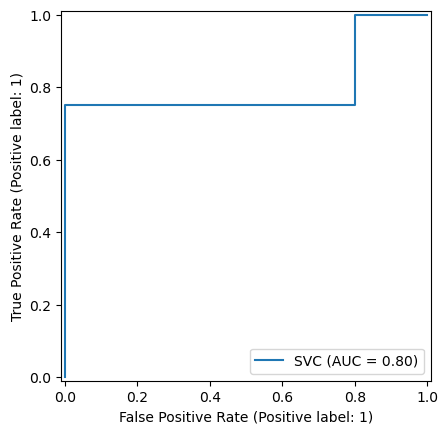

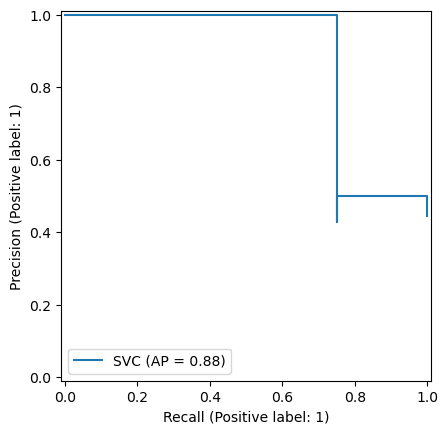

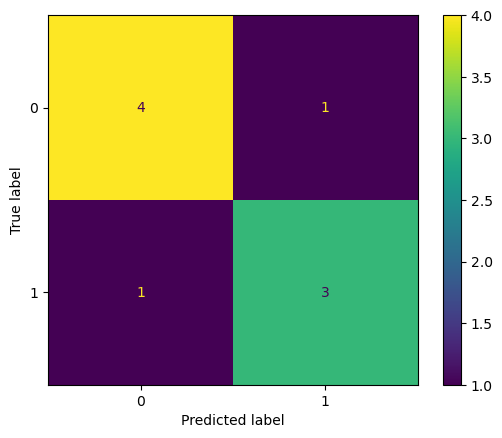

In [ ]:
from sklearn.metrics import RocCurveDisplay,PrecisionRecallDisplay,ConfusionMatrixDisplay
RocCurveDisplay.from_estimator(svc,X_test_sc,y_test)
plt.show()
PrecisionRecallDisplay.from_estimator(svc,X_test_sc,y_test)
plt.show()
ConfusionMatrixDisplay.from_estimator(svc,X_test_sc,y_test)
plt.show()

In [ ]:
select_features_with_lasso(lasso_df, y, 5)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression, LassoCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

def run_nested_cv(X: pd.DataFrame, y: pd.Series):
    """
    Executes a Nested Cross-Validation loop.
    Inner Loop: Feature Scaling -> LASSO Selection -> Hyperparameter Tuning
    Outer Loop: Unbiased Performance Evaluation
    """
    # ─── 1. DEFINE THE INNER PIPELINE ────────────────────────────────────────
    # Standardize -> Select features via LASSO -> Classify
    # We use SelectFromModel with LassoCV to automate the inner feature selection
    lasso_selector = SelectFromModel(
        LassoCV(cv=3, max_iter=10000, random_state=42, n_jobs=-1)
    )

    # You can change this classifier to XGBoost, SVM, or Random Forest
    classifier = RandomForestClassifier(random_state=42)

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('selector', lasso_selector),
        ('classifier', classifier)
    ])

    # ─── 2. HYPERPARAMETER TUNING GRID (INNER LOOP) ──────────────────────────
    # Define what the inner loop should search through.
    param_grid = {
        # Try different tree counts for Random Forest
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [None, 5, 10],
        # You can also adjust the LASSO threshold if needed
        'selector__threshold': ['mean', 'median']
    }

    # ─── 3. SETUP CROSS-VALIDATION SPLITS ────────────────────────────────────
    # StratifiedKFold maintains class balance (RCC vs AML ratio) across folds
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    # Storage arrays for outer loop evaluation metrics
    outer_auc_scores = []
    outer_accuracy_scores = []

    print("🔄 Starting Nested Cross-Validation Loop...")
    print(f"Outer Loops: {outer_cv.get_n_splits()} folds | Inner Loops: {inner_cv.get_n_splits()} folds\n")

    # ─── 4. OUTER LOOP ───────────────────────────────────────────────────────
    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # GridSearch acts as our automated Inner Loop
        inner_search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            cv=inner_cv,
            scoring='roc_auc',
            n_jobs=-1,
            verbose=0
        )

        # Fit the inner loop (Scales, runs LASSO, tunes RF parameters per fold)
        inner_search.fit(X_train, y_train)

        # Get best estimator from this fold's inner search
        best_model = inner_search.best_estimator_

        # Track how many features LASSO actually passed to the classifier in this fold
        features_retained = best_model.named_steps['selector'].get_support()
        num_features = np.sum(features_retained)

        # Predict on the strictly isolated outer test set
        y_pred = best_model.predict(X_test)
        y_proba = best_model.predict_proba(X_test)[:, 1]

        # Evaluate performance
        fold_auc = roc_auc_score(y_test, y_proba)
        fold_acc = accuracy_score(y_test, y_pred)

        outer_auc_scores.append(fold_auc)
        outer_accuracy_scores.append(fold_acc)

        print(f"🔹 Outer Fold {fold}:")
        print(f"   Selected Features : {num_features} / {X.shape[1]}")
        print(f"   Best Parameters   : {inner_search.best_params_}")
        print(f"   Test AUC          : {fold_auc:.4f} | Test Accuracy: {fold_acc:.4f}\n")

    # ─── 5. FINAL REPORTING ──────────────────────────────────────────────────
    print("═══ FINAL NESTED CV RESULTS ═══")
    print(f"Mean Test AUC     : {np.mean(outer_auc_scores):.4f} ± {np.std(outer_auc_scores):.4f}")
    print(f"Mean Test Accuracy: {np.mean(outer_accuracy_scores):.4f} ± {np.std(outer_accuracy_scores):.4f}")
    print("===============================")

# ─── HOW TO EXECUTE ──────────────────────────────────────────────────────────
# feature_cols = [col for col in df.columns if col != 'tumor_type']
# X = df[feature_cols]
# y = df['tumor_type']
# run_nested_cv(X, y)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression, LassoCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

def run_nested_cv(X: pd.DataFrame, y: pd.Series) -> dict:
    """
    Executes a Nested Cross-Validation loop.
    Inner Loop: Feature Scaling -> LASSO Selection -> Hyperparameter Tuning
    Outer Loop: Unbiased Performance Evaluation

    Returns:
    --------
    fold_artifacts : dict
        A dictionary containing the scaler, LASSO-selected feature list,
        and trained model object for each outer fold.
    """
    # ─── 1. DEFINE THE INNER PIPELINE ────────────────────────────────────────
    lasso_selector = SelectFromModel(
        LassoCV(cv=3, max_iter=10000, random_state=42, n_jobs=-1)
    )

    classifier = RandomForestClassifier(random_state=42)

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('selector', lasso_selector),
        ('classifier', classifier)
    ])

    # ─── 2. HYPERPARAMETER TUNING GRID (INNER LOOP) ──────────────────────────
    param_grid = {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [None, 5, 10],
        'selector__threshold': ['mean', 'median']
    }

    # ─── 3. SETUP CROSS-VALIDATION SPLITS ────────────────────────────────────
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    # Storage arrays for outer loop evaluation metrics
    outer_auc_scores = []
    outer_accuracy_scores = []

    # 🚨 TRACKING DICTIONARY FOR ARTIFACT EXTRACTION
    fold_artifacts = {}

    print("🔄 Starting Nested Cross-Validation Loop...")
    print(f"Outer Loops: {outer_cv.get_n_splits()} folds | Inner Loops: {inner_cv.get_n_splits()} folds\n")

    # ─── 4. OUTER LOOP ───────────────────────────────────────────────────────
    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # GridSearch acts as our automated Inner Loop
        inner_search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            cv=inner_cv,
            scoring='roc_auc',
            n_jobs=-1,
            verbose=0
        )

        # Fit the inner loop (Scales, runs LASSO, tunes RF parameters per fold)
        inner_search.fit(X_train, y_train)

        # Get best estimator from this fold's inner search
        best_model = inner_search.best_estimator_

        # 🚨 EXTRACTION LOGIC
        feature_mask = best_model.named_steps['selector'].get_support()
        selected_features = X.columns[feature_mask].tolist()
        num_features = len(selected_features)

        # Store objects in the artifacts dictionary
        fold_artifacts[f"Fold_{fold}"] = {
            "model_name": best_model.named_steps['classifier'].__class__.__name__,
            "model_object": best_model.named_steps['classifier'],
            "selected_features": selected_features,
            "scaler_object": best_model.named_steps['scaler'],
            "best_params": inner_search.best_params_
        }

        # Predict on the strictly isolated outer test set
        y_pred = best_model.predict(X_test)
        y_proba = best_model.predict_proba(X_test)[:, 1]

        # Evaluate performance
        fold_auc = roc_auc_score(y_test, y_proba)
        fold_acc = accuracy_score(y_test, y_pred)

        outer_auc_scores.append(fold_auc)
        outer_accuracy_scores.append(fold_acc)

        print(f"🔹 Outer Fold {fold}:")
        print(f"   Selected Features : {num_features} / {X.shape[1]}")
        print(f"   Best Parameters   : {inner_search.best_params_}")
        print(f"   Test AUC          : {fold_auc:.4f} | Test Accuracy: {fold_acc:.4f}\n")

    # ─── 5. FINAL REPORTING ──────────────────────────────────────────────────
    print("═══ FINAL NESTED CV RESULTS ═══")
    print(f"Mean Test AUC     : {np.mean(outer_auc_scores):.4f} ± {np.std(outer_auc_scores):.4f}")
    print(f"Mean Test Accuracy: {np.mean(outer_accuracy_scores):.4f} ± {np.std(outer_accuracy_scores):.4f}")
    print("===============================")

    # 🚨 CRITICAL FIX: Explicitly return the saved artifacts back to memory
    return fold_artifacts

In [ ]:
fold_artifacts

NameError: name 'fold_artifacts' is not defined

In [ ]:
run_nested_cv(X, y)

🔄 Starting Nested Cross-Validation Loop...
Outer Loops: 5 folds | Inner Loops: 3 folds

🔹 Outer Fold 1:
   Selected Features : 1 / 1145
   Best Parameters   : {'classifier__max_depth': None, 'classifier__n_estimators': 50, 'selector__threshold': 'mean'}
   Test AUC          : 1.0000 | Test Accuracy: 1.0000

🔹 Outer Fold 2:
   Selected Features : 1 / 1145
   Best Parameters   : {'classifier__max_depth': None, 'classifier__n_estimators': 50, 'selector__threshold': 'mean'}
   Test AUC          : 1.0000 | Test Accuracy: 1.0000

🔹 Outer Fold 3:
   Selected Features : 1 / 1145
   Best Parameters   : {'classifier__max_depth': None, 'classifier__n_estimators': 50, 'selector__threshold': 'mean'}
   Test AUC          : 1.0000 | Test Accuracy: 1.0000

🔹 Outer Fold 4:
   Selected Features : 1 / 1145
   Best Parameters   : {'classifier__max_depth': None, 'classifier__n_estimators': 50, 'selector__threshold': 'mean'}
   Test AUC          : 1.0000 | Test Accuracy: 1.0000

🔹 Outer Fold 5:
   Selected 

In [ ]:
# 1. Run the updated function and store artifacts securely



# 2. Extract components from Fold 5 (The 73-feature model)
chosen_fold = "Fold_5"
feature_list = fold_artifacts[chosen_fold]['selected_features']
scaler_obj   = fold_artifacts[chosen_fold]['scaler_object']
model_obj    = fold_artifacts[chosen_fold]['model_object']

# 3. Apply features and scaler on the unseen dataset
X_unseen_raw    = df_new.loc[:, feature_list] # Slices out matching 73 features in correct order
X_unseen_scaled = scaler_obj.transform(X_unseen_raw) # Preprocesses with training baselines

# 4. Generate classifications
predictions   = model_obj.predict(X_unseen_scaled)
probabilities = model_obj.predict_proba(X_unseen_scaled)[:, 1]

print("\n🚀 Unseen data successfully processed through Fold 5 components!")

NameError: name 'fold_artifacts' is not defined

In [ ]:
feature_list = fold_artifacts[chosen_fold]['selected_features']

In [ ]:
run_nested_cv(df.loc[:,columns], df['target'])

🔄 Starting Nested Cross-Validation Loop...
Outer Loops: 5 folds | Inner Loops: 3 folds

🔹 Outer Fold 1:
   Selected Features : 36 / 71
   Best Parameters   : {'classifier__max_depth': None, 'classifier__n_estimators': 200, 'selector__threshold': 'median'}
   Test AUC          : 1.0000 | Test Accuracy: 1.0000

🔹 Outer Fold 2:
   Selected Features : 36 / 71
   Best Parameters   : {'classifier__max_depth': None, 'classifier__n_estimators': 200, 'selector__threshold': 'median'}
   Test AUC          : 0.9259 | Test Accuracy: 0.9048

🔹 Outer Fold 3:
   Selected Features : 36 / 71
   Best Parameters   : {'classifier__max_depth': None, 'classifier__n_estimators': 200, 'selector__threshold': 'median'}
   Test AUC          : 0.9697 | Test Accuracy: 0.9000

🔹 Outer Fold 4:
   Selected Features : 36 / 71
   Best Parameters   : {'classifier__max_depth': None, 'classifier__n_estimators': 100, 'selector__threshold': 'median'}
   Test AUC          : 0.7475 | Test Accuracy: 0.8500

🔹 Outer Fold 5:
   S

In [ ]:
run_nested_cv(df.drop(['pathology_grade','augmentation','source_subset','target','tumor_type'],axis=1).select_dtypes(exclude = "object"), df['target'])


🔄 Starting Nested Cross-Validation Loop...
Outer Loops: 5 folds | Inner Loops: 3 folds

🔹 Outer Fold 1:
   Selected Features : 1144 / 1144
   Best Parameters   : {'classifier__max_depth': 5, 'classifier__n_estimators': 200, 'selector__threshold': 'median'}
   Test AUC          : 0.9722 | Test Accuracy: 0.8571

🔹 Outer Fold 2:
   Selected Features : 1144 / 1144
   Best Parameters   : {'classifier__max_depth': None, 'classifier__n_estimators': 50, 'selector__threshold': 'median'}
   Test AUC          : 0.9120 | Test Accuracy: 0.8095

🔹 Outer Fold 3:
   Selected Features : 1144 / 1144
   Best Parameters   : {'classifier__max_depth': None, 'classifier__n_estimators': 200, 'selector__threshold': 'median'}
   Test AUC          : 1.0000 | Test Accuracy: 1.0000

🔹 Outer Fold 4:
   Selected Features : 1144 / 1144
   Best Parameters   : {'classifier__max_depth': 5, 'classifier__n_estimators': 100, 'selector__threshold': 'median'}
   Test AUC          : 0.8990 | Test Accuracy: 0.8000

🔹 Outer Fol

C:\Users\HP-Gayrettepe\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.583e-03, tolerance: 2.020e-03
  model = cd_fast.enet_coordinate_descent(


In [ ]:
artifacts = run_nested_cv(df.drop(['pathology_grade','augmentation','source_subset','target','tumor_type'],axis=1).select_dtypes(exclude = "object"), df['target'])


🔄 Starting Nested Cross-Validation Loop...
Outer Loops: 5 folds | Inner Loops: 3 folds

🔹 Outer Fold 1:
   Selected Features : 1144 / 1144
   Best Parameters   : {'classifier__max_depth': 5, 'classifier__n_estimators': 200, 'selector__threshold': 'median'}
   Test AUC          : 0.9722 | Test Accuracy: 0.8571

🔹 Outer Fold 2:
   Selected Features : 1144 / 1144
   Best Parameters   : {'classifier__max_depth': None, 'classifier__n_estimators': 50, 'selector__threshold': 'median'}
   Test AUC          : 0.9120 | Test Accuracy: 0.8095

🔹 Outer Fold 3:
   Selected Features : 1144 / 1144
   Best Parameters   : {'classifier__max_depth': None, 'classifier__n_estimators': 200, 'selector__threshold': 'median'}
   Test AUC          : 1.0000 | Test Accuracy: 1.0000

🔹 Outer Fold 4:
   Selected Features : 1144 / 1144
   Best Parameters   : {'classifier__max_depth': 5, 'classifier__n_estimators': 100, 'selector__threshold': 'median'}
   Test AUC          : 0.8990 | Test Accuracy: 0.8000

🔹 Outer Fol

C:\Users\HP-Gayrettepe\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.583e-03, tolerance: 2.020e-03
  model = cd_fast.enet_coordinate_descent(


In [ ]:
# 1. Run the updated function and store artifacts securely


artifacts = run_nested_cv(df.drop(['pathology_grade','augmentation','source_subset','target','tumor_type'],axis=1).select_dtypes(exclude = "object"), df['target'])

# 2. Extract components from Fold 5 (The 73-feature model)
chosen_fold = "Fold_5"
feature_list = artifacts[chosen_fold]['selected_features']
scaler_obj   = artifacts[chosen_fold]['scaler_object']
model_obj    = artifacts[chosen_fold]['model_object']

# 3. Apply features and scaler on the unseen dataset
X_unseen_raw    = df_new.loc[:, feature_list] # Slices out matching 73 features in correct order
X_unseen_scaled = scaler_obj.transform(X_unseen_raw) # Preprocesses with training baselines

# 4. Generate classifications
predictions   = model_obj.predict(X_unseen_scaled)
probabilities = model_obj.predict_proba(X_unseen_scaled)[:, 1]

print("\n🚀 Unseen data successfully processed through Fold 5 components!")

🔄 Starting Nested Cross-Validation Loop...
Outer Loops: 5 folds | Inner Loops: 3 folds

🔹 Outer Fold 1:
   Selected Features : 1144 / 1144
   Best Parameters   : {'classifier__max_depth': 5, 'classifier__n_estimators': 200, 'selector__threshold': 'median'}
   Test AUC          : 0.9722 | Test Accuracy: 0.8571

🔹 Outer Fold 2:
   Selected Features : 1144 / 1144
   Best Parameters   : {'classifier__max_depth': None, 'classifier__n_estimators': 50, 'selector__threshold': 'median'}
   Test AUC          : 0.9120 | Test Accuracy: 0.8095

🔹 Outer Fold 3:
   Selected Features : 1144 / 1144
   Best Parameters   : {'classifier__max_depth': None, 'classifier__n_estimators': 200, 'selector__threshold': 'median'}
   Test AUC          : 1.0000 | Test Accuracy: 1.0000

🔹 Outer Fold 4:
   Selected Features : 1144 / 1144
   Best Parameters   : {'classifier__max_depth': 5, 'classifier__n_estimators': 100, 'selector__threshold': 'median'}
   Test AUC          : 0.8990 | Test Accuracy: 0.8000



C:\Users\HP-Gayrettepe\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.583e-03, tolerance: 2.020e-03
  model = cd_fast.enet_coordinate_descent(


🔹 Outer Fold 5:
   Selected Features : 73 / 1144
   Best Parameters   : {'classifier__max_depth': 5, 'classifier__n_estimators': 50, 'selector__threshold': 'mean'}
   Test AUC          : 1.0000 | Test Accuracy: 1.0000

═══ FINAL NESTED CV RESULTS ═══
Mean Test AUC     : 0.9566 ± 0.0432
Mean Test Accuracy: 0.8933 ± 0.0892


NameError: name 'df_new' is not defined

In [ ]:
# ─── STEP 1: PICK YOUR FOLD ARTIFACTS ────────────────────────────────────────
# Let's say Fold 1 gave you the best Test AUC, so you want to use its exact setup.
chosen_fold = "Fold_5"

# Extract the components we need
feature_list = artifacts[chosen_fold]['selected_features']
scaler_obj   = artifacts[chosen_fold]['scaler_object']
model_obj    = artifacts[chosen_fold]['model_object']

print(f"Loaded pipeline components from {chosen_fold}.")
print(f"Expecting exactly {len(feature_list)} features.")


# ─── STEP 2: PREPARE AND FILTER THE UNSEEN DATAFRAME ────────────────────────
# Use .loc to slice the unseen dataframe to contain ONLY the selected radiomics features.
# CRITICAL: This ensures columns are in the exact mathematical order the model expects!
X_unseen_raw = df_new.loc[:, feature_list]


# ─── STEP 3: PREPROCESS THE UNSEEN DATA ──────────────────────────────────────
# You MUST use .transform(), NOT .fit_transform().
# This applies the exact training means/standard deviations to the new dataset.
X_unseen_scaled = scaler_obj.transform(X_unseen_raw)


# ─── STEP 4: GENERATE PREDICTIONS ───────────────────────────────────────────
# Now it is completely safe to inject the scaled data into your trained model object.
predictions = model_obj.predict(X_unseen_scaled)
probabilities = model_obj.predict_proba(X_unseen_scaled)[:, 1]

# Save the outputs into a clean DataFrame
df_new_results = pd.DataFrame({
    'Predicted_Class': predictions,
    'Probability_of_AML': probabilities
}, index=df_new.index)

print("\n predictions completed successfully!")
print(df_new_results.head())

In [ ]:
dfT

In [ ]:
# ─── STEP 1: PICK YOUR FOLD ARTIFACTS ────────────────────────────────────────
# Let's say Fold 1 gave you the best Test AUC, so you want to use its exact setup.
chosen_fold = "Fold_5"

# Extract the components we need
feature_list = artifacts[chosen_fold]['selected_features']
scaler_obj   = artifacts[chosen_fold]['scaler_object']
model_obj    = artifacts[chosen_fold]['model_object']



In [ ]:
model_obj.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 5,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 50,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [ ]:
feature_list

['original_shape_Elongation',
 'original_shape_Flatness',
 'original_shape_Sphericity',
 'original_glcm_Idmn',
 'original_glszm_LargeAreaHighGrayLevelEmphasis',
 'original_glszm_LowGrayLevelZoneEmphasis',
 'original_gldm_DependenceVariance',
 'log-sigma-1-0-mm-3D_firstorder_Skewness',
 'log-sigma-1-0-mm-3D_glszm_LowGrayLevelZoneEmphasis',
 'log-sigma-1-0-mm-3D_glszm_SizeZoneNonUniformityNormalized',
 'log-sigma-1-0-mm-3D_gldm_DependenceVariance',
 'log-sigma-1-0-mm-3D_ngtdm_Strength',
 'log-sigma-2-0-mm-3D_firstorder_Skewness',
 'log-sigma-2-0-mm-3D_glszm_GrayLevelNonUniformityNormalized',
 'log-sigma-2-0-mm-3D_glszm_SmallAreaEmphasis',
 'log-sigma-2-0-mm-3D_glszm_SmallAreaLowGrayLevelEmphasis',
 'log-sigma-3-0-mm-3D_firstorder_Kurtosis',
 'log-sigma-3-0-mm-3D_glrlm_ShortRunLowGrayLevelEmphasis',
 'log-sigma-3-0-mm-3D_glszm_SmallAreaEmphasis',
 'wavelet-LLH_glrlm_LongRunLowGrayLevelEmphasis',
 'wavelet-LLH_glrlm_RunVariance',
 'wavelet-LLH_glszm_SizeZoneNonUniformityNormalized',
 'wave

In [ ]:
feature_list

['original_shape_Elongation',
 'original_shape_Flatness',
 'original_shape_Sphericity',
 'original_glcm_Idmn',
 'original_glszm_LargeAreaHighGrayLevelEmphasis',
 'original_glszm_LowGrayLevelZoneEmphasis',
 'original_gldm_DependenceVariance',
 'log-sigma-1-0-mm-3D_firstorder_Skewness',
 'log-sigma-1-0-mm-3D_glszm_LowGrayLevelZoneEmphasis',
 'log-sigma-1-0-mm-3D_glszm_SizeZoneNonUniformityNormalized',
 'log-sigma-1-0-mm-3D_gldm_DependenceVariance',
 'log-sigma-1-0-mm-3D_ngtdm_Strength',
 'log-sigma-2-0-mm-3D_firstorder_Skewness',
 'log-sigma-2-0-mm-3D_glszm_GrayLevelNonUniformityNormalized',
 'log-sigma-2-0-mm-3D_glszm_SmallAreaEmphasis',
 'log-sigma-2-0-mm-3D_glszm_SmallAreaLowGrayLevelEmphasis',
 'log-sigma-3-0-mm-3D_firstorder_Kurtosis',
 'log-sigma-3-0-mm-3D_glrlm_ShortRunLowGrayLevelEmphasis',
 'log-sigma-3-0-mm-3D_glszm_SmallAreaEmphasis',
 'wavelet-LLH_glrlm_LongRunLowGrayLevelEmphasis',
 'wavelet-LLH_glrlm_RunVariance',
 'wavelet-LLH_glszm_SizeZoneNonUniformityNormalized',
 'wave

In [ ]:
len(feature_list)

73

In [ ]:
scaler_obj.feature_names_in_

array(['mask_voxel_count', 'original_shape_Elongation',
       'original_shape_Flatness', ...,
       'diagnostics_Mask-interpolated_Mean',
       'diagnostics_Mask-interpolated_Minimum',
       'diagnostics_Mask-interpolated_Maximum'],
      shape=(1144,), dtype=object)

In [ ]:
scaler_obj.get_feature_names_out()

array(['mask_voxel_count', 'original_shape_Elongation',
       'original_shape_Flatness', ...,
       'diagnostics_Mask-interpolated_Mean',
       'diagnostics_Mask-interpolated_Minimum',
       'diagnostics_Mask-interpolated_Maximum'],
      shape=(1144,), dtype=object)

In [ ]:
dfT.loc[:,feature_list]

,original_shape_Elongation,original_shape_Flatness,original_shape_Sphericity,original_glcm_Idmn,original_glszm_LargeAreaHighGrayLevelEmphasis,original_glszm_LowGrayLevelZoneEmphasis,original_gldm_DependenceVariance,log-sigma-1-0-mm-3D_firstorder_Skewness,log-sigma-1-0-mm-3D_glszm_LowGrayLevelZoneEmphasis,log-sigma-1-0-mm-3D_glszm_SizeZoneNonUniformityNormalized,...,wavelet-HHH_glszm_SizeZoneNonUniformity,wavelet-HHH_glszm_SizeZoneNonUniformityNormalized,wavelet-HHH_ngtdm_Contrast,wavelet-LLL_firstorder_Skewness,wavelet-LLL_glcm_Idmn,wavelet-LLL_glcm_Imc1,wavelet-LLL_glszm_GrayLevelNonUniformity,wavelet-LLL_ngtdm_Strength,diagnostics_Image-interpolated_Minimum,diagnostics_Image-interpolated_Maximum
0,0.841058,0.807857,0.775735,0.994206,8.755422e+06,0.095518,48.243055,0.666294,0.245833,0.140000,...,1.0,0.5,0.127150,-1.035922,0.995136,-0.325736,7.150000,0.336247,77.656555,127.097652
1,0.790875,0.631394,0.779468,0.993151,7.765630e+05,0.066061,22.494039,-0.378374,0.074690,0.121094,...,1.0,0.5,0.125185,-0.516973,0.994310,-0.252262,13.702550,4.547313,-122.930227,147.131874
2,0.943968,0.606594,0.737446,0.995760,3.452516e+07,0.306826,46.272209,-0.472643,0.587910,0.076446,...,1.0,0.5,0.125087,0.186110,0.996474,-0.454982,57.829178,0.424491,-32.790072,139.409458
3,0.418093,0.387676,0.704647,0.990084,6.681924e+06,0.124909,34.915426,0.646855,0.322090,0.129252,...,1.0,0.5,0.122042,-0.833991,0.991357,-0.362309,26.557789,1.066915,68.787269,143.270837
4,0.971305,0.703365,0.735525,0.991534,1.385409e+07,0.098400,40.960985,0.490286,0.225694,0.177778,...,1.0,0.5,0.128363,-0.933165,0.993789,-0.322256,16.581921,0.131891,54.969240,88.770727


In [ ]:
scaler_obj.feature_names_in_

array(['mask_voxel_count', 'original_shape_Elongation',
       'original_shape_Flatness', ...,
       'diagnostics_Mask-interpolated_Mean',
       'diagnostics_Mask-interpolated_Minimum',
       'diagnostics_Mask-interpolated_Maximum'],
      shape=(1144,), dtype=object)

In [ ]:
model_obj.params

AttributeError: 'RandomForestClassifier' object has no attribute 'params'

In [ ]:
# 1. Run the updated function and store artifacts securely

X = df.drop(['pathology_grade','augmentation','source_subset','target','tumor_type'],axis=1).select_dtypes(exclude = "object")
y = df['target']

artifacts = run_nested_cv(X, y )

# 2. Extract components from Fold 5 (The 73-feature model)
chosen_fold = "Fold_5"
feature_list = artifacts[chosen_fold]['selected_features']
scaler_obj   = artifacts[chosen_fold]['scaler_object']
model_obj    = artifacts[chosen_fold]['model_object']

# 3. Apply features and scaler on the unseen dataset
X_unseen_raw    = dfT.loc[:, feature_list] # Slices out matching 73 features in correct order
X_unseen_scaled = scaler_obj.transform(X_unseen_raw) # Preprocesses with training baselines

# 4. Generate classifications
predictions   = model_obj.predict(X_unseen_scaled)
probabilities = model_obj.predict_proba(X_unseen_scaled)[:, 1]

print("\n🚀 Unseen data successfully processed through Fold 5 components!")

🔄 Starting Nested Cross-Validation Loop...
Outer Loops: 5 folds | Inner Loops: 3 folds

🔹 Outer Fold 1:
   Selected Features : 1144 / 1144
   Best Parameters   : {'classifier__max_depth': 5, 'classifier__n_estimators': 200, 'selector__threshold': 'median'}
   Test AUC          : 0.9722 | Test Accuracy: 0.8571

🔹 Outer Fold 2:
   Selected Features : 1144 / 1144
   Best Parameters   : {'classifier__max_depth': None, 'classifier__n_estimators': 50, 'selector__threshold': 'median'}
   Test AUC          : 0.9120 | Test Accuracy: 0.8095

🔹 Outer Fold 3:
   Selected Features : 1144 / 1144
   Best Parameters   : {'classifier__max_depth': None, 'classifier__n_estimators': 200, 'selector__threshold': 'median'}
   Test AUC          : 1.0000 | Test Accuracy: 1.0000

🔹 Outer Fold 4:
   Selected Features : 1144 / 1144
   Best Parameters   : {'classifier__max_depth': 5, 'classifier__n_estimators': 100, 'selector__threshold': 'median'}
   Test AUC          : 0.8990 | Test Accuracy: 0.8000



C:\Users\HP-Gayrettepe\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.583e-03, tolerance: 2.020e-03
  model = cd_fast.enet_coordinate_descent(


🔹 Outer Fold 5:
   Selected Features : 73 / 1144
   Best Parameters   : {'classifier__max_depth': 5, 'classifier__n_estimators': 50, 'selector__threshold': 'mean'}
   Test AUC          : 1.0000 | Test Accuracy: 1.0000

═══ FINAL NESTED CV RESULTS ═══
Mean Test AUC     : 0.9566 ± 0.0432
Mean Test Accuracy: 0.8933 ± 0.0892


ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- diagnostics_Image-interpolated_Mean
- diagnostics_Image-original_Maximum
- diagnostics_Image-original_Mean
- diagnostics_Image-original_Minimum
- diagnostics_Mask-interpolated_Maximum
- ...


In [ ]:
model_obj.predict(scaler_obj.transform(dfT.drop(['pathology_grade','tumor_type'],axis=1).select_dtypes(exclude = "object"))[:,dfT.drop(['pathology_grade','tumor_type'],axis=1).select_dtypes(exclude = "object").columns.get_indexer(feature_list)])

array([0, 0, 0, 0, 0])

In [ ]:
dfT.drop(['pathology_grade','augmentation','source_subset','target','tumor_type'],axis=1).select_dtypes(exclude = "object")

KeyError: "['augmentation', 'source_subset', 'target'] not found in axis"

In [44]:
dfA= pd.concat([do,dr], axis = 0, ignore_index= 1)

In [45]:
pd.concat([do,dr], axis = 0, ignore_index= 1).shape

(11, 1182)

In [46]:
dfA['target'] = 1

In [47]:
dfA.shape

(11, 1183)

In [48]:
dfR = pd.concat([drcc1,drcc2], axis = 0, ignore_index= 1)

In [49]:
dfR.shape

(58, 1182)

In [50]:
dfR['target'] = 0

In [51]:
dfR.shape

(58, 1183)

In [52]:
dfrcc = dfR.sample(58)

In [53]:
dfU = pd.concat([dfA,dfrcc], axis = 0, ignore_index= 1)

In [54]:
dfU.drop('pathology_grade', axis =1, inplace= True)

In [55]:
y = dfU['target']

In [56]:
X = dfU.drop(columns=["tumor_type",'augmentation','source_subset','target'],axis=1).select_dtypes(exclude = "object")

In [57]:
df = X.copy()

In [ ]:
X.iloc[:,:].columns

Index(['mask_voxel_count', 'original_shape_Elongation',
       'original_shape_Flatness', 'original_shape_LeastAxisLength',
       'original_shape_MajorAxisLength',
       'original_shape_Maximum2DDiameterColumn',
       'original_shape_Maximum2DDiameterRow',
       'original_shape_Maximum2DDiameterSlice',
       'original_shape_Maximum3DDiameter', 'original_shape_MeshVolume',
       ...
       'diagnostics_Mask-original_VoxelNum',
       'diagnostics_Mask-original_VolumeNum',
       'diagnostics_Image-interpolated_Mean',
       'diagnostics_Image-interpolated_Minimum',
       'diagnostics_Image-interpolated_Maximum',
       'diagnostics_Mask-interpolated_VoxelNum',
       'diagnostics_Mask-interpolated_VolumeNum',
       'diagnostics_Mask-interpolated_Mean',
       'diagnostics_Mask-interpolated_Minimum',
       'diagnostics_Mask-interpolated_Maximum'],
      dtype='object', length=1144)

In [ ]:
df.iloc[:,[204,316,391,481,634,660,682]].columns
Index(['log-sigma-2-0-mm-3D_firstorder_Entropy',
       'log-sigma-3-0-mm-3D_glcm_Contrast',
       'wavelet-LLH_firstorder_InterquartileRange',
       'wavelet-LHL_firstorder_90Percentile',
       'wavelet-LHH_glszm_HighGrayLevelZoneEmphasis',
       'wavelet-LHH_gldm_SmallDependenceLowGrayLevelEmphasis',
       'wavelet-HLL_firstorder_Uniformity'],
      dtype='object')

In [ ]:
df.iloc[:,[204,316,391,481,634,660,682]].columns

Index(['log-sigma-2-0-mm-3D_firstorder_Entropy',
       'log-sigma-3-0-mm-3D_glcm_Contrast',
       'wavelet-LLH_firstorder_InterquartileRange',
       'wavelet-LHL_firstorder_90Percentile',
       'wavelet-LHH_glszm_HighGrayLevelZoneEmphasis',
       'wavelet-LHH_gldm_SmallDependenceLowGrayLevelEmphasis',
       'wavelet-HLL_firstorder_Uniformity'],
      dtype='object')

In [ ]:
X["tumor_type"]

KeyError: 'tumor_type'

In [ ]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, make_scorer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# 1. Generate a mock small, imbalanced dataset (e.g., 200 samples, 10% minority)
X, y = make_classification(
    n_samples=100,
    n_features=10,
    n_informative=8,
    n_classes=2,
    weights=[0.9, 0.1],
    flip_y=0,
    random_state=42
)

# 2. Define the Pipeline (SMOTE -> Classifier)
# Crucial: Use imblearn's Pipeline, which automatically skips oversampling
# on the validation/test folds during predict() or predict_proba()
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# 3. Define Hyperparameter Space for the Inner Loop
# Note the prefix 'classifier_' and 'smote_' to target specific pipeline steps
param_grid = {
    'smote__k_neighbors': [3, 5],
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [4, 6, None]
}

# 4. Set up Inner and Outer Stratified K-Fold loops
# Inner CV is the "Tuning Sandbox" to find optimal parameters
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
# Outer CV measures how well the tuned model generalizes
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define metric (Average Precision / PR-AUC is best for high imbalance)
pr_auc_scorer = make_scorer(average_precision_score, response_method='predict_proba')

# 5. The Inner Loop Setup (Hyperparameter Tuning)
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=inner_cv,
    scoring=pr_auc_scorer,
    n_jobs=-1
)

# 6. The Outer Loop Execution (Model Evaluation)
outer_scores = []

print("--- Starting Nested Cross-Validation ---")
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
    # Isolate the Outer Test Fold from the Outer Training Dataset
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Run the inner loop tuning on the outer training fold data only
    grid_search.fit(X_train, y_train)

    # Extract the best model from this fold's tuning configuration
    best_model = grid_search.best_estimator_

    # Predict probabilities on the untouched, un-SMOTEd outer test fold
    y_proba = best_model.predict_proba(X_test)[:, 1]

    # Evaluate performance on the real, imbalanced test fold
    fold_score = average_precision_score(y_test, y_proba)
    outer_scores.append(fold_score)

    print(f"Outer Fold {fold + 1} - Best Params: {grid_search.best_params_} | PR-AUC: {fold_score:.4f}")

# 7. Aggregate and Final Verification
mean_pr_auc = np.mean(outer_scores)
std_pr_auc = np.std(outer_scores)
print("\n--- Final Performance Deliverable ---")
print(f"Nested CV Mean PR-AUC: {mean_pr_auc:.4f} +/- {std_pr_auc:.4f}")

--- Starting Nested Cross-Validation ---


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
12 fits failed out of a total of 36.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
12 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/imblearn/pipeline.py", line 514, in fit
    Xt, yt = self._fit(X, y, routed_para

Outer Fold 1 - Best Params: {'classifier__max_depth': 6, 'classifier__n_estimators': 100, 'smote__k_neighbors': 3} | PR-AUC: 0.2111


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
12 fits failed out of a total of 36.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
12 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/imblearn/pipeline.py", line 514, in fit
    Xt, yt = self._fit(X, y, routed_para

Outer Fold 2 - Best Params: {'classifier__max_depth': 6, 'classifier__n_estimators': 100, 'smote__k_neighbors': 3} | PR-AUC: 0.7000


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
12 fits failed out of a total of 36.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
12 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/imblearn/pipeline.py", line 514, in fit
    Xt, yt = self._fit(X, y, routed_para

Outer Fold 3 - Best Params: {'classifier__max_depth': 6, 'classifier__n_estimators': 100, 'smote__k_neighbors': 3} | PR-AUC: 0.8333


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
12 fits failed out of a total of 36.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
12 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/imblearn/pipeline.py", line 514, in fit
    Xt, yt = self._fit(X, y, routed_para

Outer Fold 4 - Best Params: {'classifier__max_depth': None, 'classifier__n_estimators': 50, 'smote__k_neighbors': 3} | PR-AUC: 1.0000


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
12 fits failed out of a total of 36.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
12 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/imblearn/pipeline.py", line 514, in fit
    Xt, yt = self._fit(X, y, routed_para

Outer Fold 5 - Best Params: {'classifier__max_depth': 6, 'classifier__n_estimators': 100, 'smote__k_neighbors': 3} | PR-AUC: 0.5000

--- Final Performance Deliverable ---
Nested CV Mean PR-AUC: 0.6489 +/- 0.2734


In [ ]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
# Added confusion_matrix and accuracy_score to the imports
from sklearn.metrics import average_precision_score, make_scorer, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# 1. Generate a mock small, imbalanced dataset (e.g., 200 samples, 10% minority)
X, y = make_classification(
    n_samples=168,
    n_features=20,
    n_informative=8,
    n_classes=2,
    weights=[58/69, 11/69],
    flip_y=0,
    random_state=42
)

# 2. Define the Pipeline (SMOTE -> Classifier)
# Crucial: Use imblearn's Pipeline, which automatically skips oversampling
# on the validation/test folds during predict() or predict_proba()
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# 3. Define Hyperparameter Space for the Inner Loop
# Note the prefix 'classifier_' and 'smote_' to target specific pipeline steps
param_grid = {
    'smote__k_neighbors': [3, 5],
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [4, 6, None]
}

# 4. Set up Inner and Outer Stratified K-Fold loops
# Inner CV is the "Tuning Sandbox" to find optimal parameters
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
# Outer CV measures how well the tuned model generalizes
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define metric (Average Precision / PR-AUC is best for high imbalance)
pr_auc_scorer = make_scorer(average_precision_score, response_method='predict_proba')

# 5. The Inner Loop Setup (Hyperparameter Tuning)
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=inner_cv,
    scoring=pr_auc_scorer,
    n_jobs=-1
)

# 6. The Outer Loop Execution (Model Evaluation)
outer_scores = []
outer_accuracy_scores = [] # Track accuracy per fold

print("--- Starting Nested Cross-Validation ---")
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
    # Isolate the Outer Test Fold from the Outer Training Dataset
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Run the inner loop tuning on the outer training fold data only
    grid_search.fit(X_train, y_train)

    # Extract the best model from this fold's tuning configuration
    best_model = grid_search.best_estimator_

    # Predict probabilities on the untouched, un-SMOTEd outer test fold
    y_proba = best_model.predict_proba(X_test)[:, 1]
    y_pred = best_model.predict(X_test) # Added for accuracy and confusion matrix

    # Evaluate performance on the real, imbalanced test fold
    fold_score = average_precision_score(y_test, y_proba)
    outer_scores.append(fold_score)

    fold_accuracy = accuracy_score(y_test, y_pred) # Calculate accuracy
    outer_accuracy_scores.append(fold_accuracy)

    fold_cm = confusion_matrix(y_test, y_pred) # Calculate confusion matrix

    print(f"Outer Fold {fold + 1} - Best Params: {grid_search.best_params_} | PR-AUC: {fold_score:.4f} | Accuracy: {fold_accuracy:.4f}")
    print(f"Confusion Matrix:\n{fold_cm}")

# 7. Aggregate and Final Verification
mean_pr_auc = np.mean(outer_scores)
std_pr_auc = np.std(outer_scores)

mean_accuracy = np.mean(outer_accuracy_scores) # Aggregate accuracy mean
std_accuracy = np.std(outer_accuracy_scores)   # Aggregate accuracy standard deviation

print("\n--- Final Performance Deliverable ---")
print(f"Nested CV Mean PR-AUC: {mean_pr_auc:.4f} +/- {std_pr_auc:.4f}")
print(f"Nested CV Mean Accuracy: {mean_accuracy:.4f} +/- {std_accuracy:.4f}") # Display accuracy

--- Starting Nested Cross-Validation ---
Outer Fold 1 - Best Params: {'classifier__max_depth': None, 'classifier__n_estimators': 100, 'smote__k_neighbors': 5} | PR-AUC: 0.3752 | Accuracy: 0.8529
Confusion Matrix:
[[28  1]
 [ 4  1]]
Outer Fold 2 - Best Params: {'classifier__max_depth': 6, 'classifier__n_estimators': 50, 'smote__k_neighbors': 5} | PR-AUC: 0.4713 | Accuracy: 0.7647
Confusion Matrix:
[[24  4]
 [ 4  2]]
Outer Fold 3 - Best Params: {'classifier__max_depth': 6, 'classifier__n_estimators': 50, 'smote__k_neighbors': 3} | PR-AUC: 0.3425 | Accuracy: 0.7059
Confusion Matrix:
[[24  4]
 [ 6  0]]
Outer Fold 4 - Best Params: {'classifier__max_depth': None, 'classifier__n_estimators': 100, 'smote__k_neighbors': 5} | PR-AUC: 0.4390 | Accuracy: 0.8182
Confusion Matrix:
[[26  2]
 [ 4  1]]
Outer Fold 5 - Best Params: {'classifier__max_depth': None, 'classifier__n_estimators': 50, 'smote__k_neighbors': 3} | PR-AUC: 0.8909 | Accuracy: 0.8788
Confusion Matrix:
[[28  0]
 [ 4  1]]

--- Final Pe

In [ ]:
X_train.shape

(80, 10)

In [ ]:
y_train.shape

(80,)

In [ ]:
X_test.shape

(20, 10)

In [ ]:
y_test.shape

(20,)

In [ ]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif  # Added for feature selection
from sklearn.metrics import average_precision_score, make_scorer, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# 1. Generate a mock small, imbalanced dataset (e.g., 200 samples, 10% minority)
X, y = make_classification(
    n_samples=168,
    n_features=20,
    n_informative=8,
    n_classes=2,
    weights=[58/69, 11/69],
    flip_y=0,
    random_state=42
)

# 2. Define the Pipeline (SMOTE -> Feature Selection -> Classifier)
# Crucial: Adding SelectKBest handles feature counting dynamically
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('selector', SelectKBest(score_func=f_classif)),  # New feature selection layer
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# 3. Define Hyperparameter Space for the Inner Loop
# Fixed: We map 'n_features' to the pipeline parameter 'selector__k'
param_grid = {
    'smote__k_neighbors': [1, 2, 3, 4],  # Adjusted down to prevent neighbor count splitting errors
    'classifier__n_estimators': [50, 59, 67, 71, 83, 97, 100],
    'classifier__max_depth': [4, 6, None],
    'selector__k': [7, 10, 11, 13, 17, 19]  # Selects top K features (must be <= total features (20))
}

# 4. Set up Inner and Outer Stratified K-Fold loops
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define metric (Average Precision / PR-AUC is best for high imbalance)
pr_auc_scorer = make_scorer(average_precision_score, response_method='predict_proba')

# 5. The Inner Loop Setup (Hyperparameter Tuning)
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=inner_cv,
    scoring=pr_auc_scorer,
    n_jobs=-1,
    error_score=0.0  # Prevents edge-case splitting runtime exceptions
)

# 6. The Outer Loop Execution (Model Evaluation)
outer_scores = []
outer_accuracy_scores = [] # Track accuracy per fold

print("--- Starting Nested Cross-Validation ---")
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
    # Isolate the Outer Test Fold from the Outer Training Dataset
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Run the inner loop tuning on the outer training fold data only
    grid_search.fit(X_train, y_train)

    # Extract the best model from this fold's tuning configuration
    best_model = grid_search.best_estimator_

    # Predict probabilities on the untouched, un-SMOTEd outer test fold
    y_proba = best_model.predict_proba(X_test)[:, 1]
    y_pred = best_model.predict(X_test) # Added for accuracy and confusion matrix

    # Evaluate performance on the real, imbalanced test fold
    fold_score = average_precision_score(y_test, y_proba)
    outer_scores.append(fold_score)

    fold_accuracy = accuracy_score(y_test, y_pred) # Calculate accuracy
    outer_accuracy_scores.append(fold_accuracy)

    fold_cm = confusion_matrix(y_test, y_pred) # Calculate confusion matrix

    print(f"Outer Fold {fold + 1} - Best Params: {grid_search.best_params_} | PR-AUC: {fold_score:.4f} | Accuracy: {fold_accuracy:.4f}")
    print(f"Confusion Matrix:\n{fold_cm}")

# 7. Aggregate and Final Verification
mean_pr_auc = np.mean(outer_scores)
std_pr_auc = np.std(outer_scores)

mean_accuracy = np.mean(outer_accuracy_scores) # Aggregate accuracy mean
std_accuracy = np.std(outer_accuracy_scores)   # Aggregate accuracy standard deviation

print("\n--- Final Performance Deliverable ---")
print(f"Nested CV Mean PR-AUC: {mean_pr_auc:.4f} +/- {std_pr_auc:.4f}")
print(f"Nested CV Mean Accuracy: {mean_accuracy:.4f} +/- {std_accuracy:.4f}") # Display accuracy

--- Starting Nested Cross-Validation ---
Outer Fold 1 - Best Params: {'classifier__max_depth': 6, 'classifier__n_estimators': 67, 'selector__k': 13, 'smote__k_neighbors': 4} | PR-AUC: 0.4951 | Accuracy: 0.8529
Confusion Matrix:
[[27  2]
 [ 3  2]]
Outer Fold 2 - Best Params: {'classifier__max_depth': 6, 'classifier__n_estimators': 67, 'selector__k': 11, 'smote__k_neighbors': 2} | PR-AUC: 0.5080 | Accuracy: 0.7941
Confusion Matrix:
[[23  5]
 [ 2  4]]
Outer Fold 3 - Best Params: {'classifier__max_depth': None, 'classifier__n_estimators': 59, 'selector__k': 17, 'smote__k_neighbors': 4} | PR-AUC: 0.3683 | Accuracy: 0.7353
Confusion Matrix:
[[25  3]
 [ 6  0]]
Outer Fold 4 - Best Params: {'classifier__max_depth': 6, 'classifier__n_estimators': 67, 'selector__k': 13, 'smote__k_neighbors': 3} | PR-AUC: 0.2926 | Accuracy: 0.7576
Confusion Matrix:
[[23  5]
 [ 3  2]]
Outer Fold 5 - Best Params: {'classifier__max_depth': 6, 'classifier__n_estimators': 67, 'selector__k': 19, 'smote__k_neighbors': 3}

In [ ]:
X_train.shape

(110, 20)

In [ ]:
y_train.shape

(110,)

In [ ]:
X_test.shape

(28, 20)

In [ ]:
y_test.shape

(28,)

In [ ]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
# Added f1_score to the scikit-learn metrics import
from sklearn.metrics import average_precision_score, make_scorer, confusion_matrix, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# 1. Generate a mock small, imbalanced dataset (e.g., 200 samples, 10% minority)
X, y = make_classification(
    n_samples=168,
    n_features=20,
    n_informative=8,
    n_classes=2,
    weights=[58/69, 11/69],
    flip_y=0,
    random_state=42
)

# 2. Define the Pipeline (SMOTE -> Feature Selection -> Classifier)
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('selector', SelectKBest(score_func=f_classif)),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# 3. Define Hyperparameter Space for the Inner Loop
param_grid = {
    'smote__k_neighbors': [3, 4, 5, 6],
    'classifier__n_estimators': [50, 59, 67, 71, 83, 97, 100],
    'classifier__max_depth': [4, 6, 8,10, None],
    'selector__k': [11, 13, 17, 19, 23, 29]
}

# 4. Set up Inner and Outer Stratified K-Fold loops
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define metric (Average Precision / PR-AUC is best for high imbalance)
pr_auc_scorer = make_scorer(average_precision_score, response_method='predict_proba')

# 5. The Inner Loop Setup (Hyperparameter Tuning)
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=inner_cv,
    scoring=pr_auc_scorer,
    n_jobs=-1,
    error_score=0.0
)

# 6. The Outer Loop Execution (Model Evaluation)
outer_scores = []
outer_accuracy_scores = []
outer_f1_scores = [] # Track F1-score per fold

print("--- Starting Nested Cross-Validation ---")
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
    # Isolate the Outer Test Fold from the Outer Training Dataset
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Run the inner loop tuning on the outer training fold data only
    grid_search.fit(X_train, y_train)

    # Extract the best model from this fold's tuning configuration
    best_model = grid_search.best_estimator_

    # Predict probabilities and hard labels
    y_proba = best_model.predict_proba(X_test)[:, 1]
    y_pred = best_model.predict(X_test)

    # Evaluate performance on the real, imbalanced test fold
    fold_score = average_precision_score(y_test, y_proba)
    outer_scores.append(fold_score)

    fold_accuracy = accuracy_score(y_test, y_pred)
    outer_accuracy_scores.append(fold_accuracy)

    fold_f1 = f1_score(y_test, y_pred) # Calculate F1-score for the fold
    outer_f1_scores.append(fold_f1)

    fold_cm = confusion_matrix(y_test, y_pred)

    # Included F1-score in the print output below
    print(f"Outer Fold {fold + 1} - Best Params: {grid_search.best_params_}")
    print(f"PR-AUC: {fold_score:.4f} | Accuracy: {fold_accuracy:.4f} | F1-Score: {fold_f1:.4f}")
    print(f"Confusion Matrix:\n{fold_cm}\n")

# 7. Aggregate and Final Verification
mean_pr_auc = np.mean(outer_scores)
std_pr_auc = np.std(outer_scores)

mean_accuracy = np.mean(outer_accuracy_scores)
std_accuracy = np.std(outer_accuracy_scores)

mean_f1 = np.mean(outer_f1_scores) # Aggregate F1-score mean
std_f1 = np.std(outer_f1_scores)   # Aggregate F1-score standard deviation

print("--- Final Performance Deliverable ---")
print(f"Nested CV Mean PR-AUC:   {mean_pr_auc:.4f} +/- {std_pr_auc:.4f}")
print(f"Nested CV Mean Accuracy: {mean_accuracy:.4f} +/- {std_accuracy:.4f}")
print(f"Nested CV Mean F1-Score: {mean_f1:.4f} +/- {std_f1:.4f}") # Display final aggregated F1-score

--- Starting Nested Cross-Validation ---
Outer Fold 1 - Best Params: {'classifier__max_depth': 10, 'classifier__n_estimators': 97, 'selector__k': 19, 'smote__k_neighbors': 4}
PR-AUC: 0.4674 | Accuracy: 0.8235 | F1-Score: 0.2500
Confusion Matrix:
[[27  2]
 [ 4  1]]



/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=23 is greater than n_features=20. All the features will be returned.
  warnings.warn(


Outer Fold 2 - Best Params: {'classifier__max_depth': 6, 'classifier__n_estimators': 50, 'selector__k': 23, 'smote__k_neighbors': 5}
PR-AUC: 0.4713 | Accuracy: 0.7647 | F1-Score: 0.3333
Confusion Matrix:
[[24  4]
 [ 4  2]]

Outer Fold 3 - Best Params: {'classifier__max_depth': 8, 'classifier__n_estimators': 50, 'selector__k': 17, 'smote__k_neighbors': 4}
PR-AUC: 0.3730 | Accuracy: 0.7647 | F1-Score: 0.2000
Confusion Matrix:
[[25  3]
 [ 5  1]]

Outer Fold 4 - Best Params: {'classifier__max_depth': 6, 'classifier__n_estimators': 67, 'selector__k': 13, 'smote__k_neighbors': 3}
PR-AUC: 0.2926 | Accuracy: 0.7576 | F1-Score: 0.3333
Confusion Matrix:
[[23  5]
 [ 3  2]]

Outer Fold 5 - Best Params: {'classifier__max_depth': 8, 'classifier__n_estimators': 50, 'selector__k': 19, 'smote__k_neighbors': 5}
PR-AUC: 0.7388 | Accuracy: 0.9394 | F1-Score: 0.7500
Confusion Matrix:
[[28  0]
 [ 2  3]]

--- Final Performance Deliverable ---
Nested CV Mean PR-AUC:   0.4686 +/- 0.1504
Nested CV Mean Accuracy

In [ ]:
X_train.shape

(135, 20)

In [ ]:
y_train.shape

(135,)

In [ ]:
X_test.shape

(33, 20)

In [ ]:
y_test.shape

(33,)

In [ ]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from xgboost import XGBClassifier  # Swapped from RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import average_precision_score, make_scorer, confusion_matrix, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# 1. Generate a mock small, imbalanced dataset (e.g., 200 samples, 10% minority)
X, y = make_classification(
    n_samples=168,
    n_features=20,
    n_informative=8,
    n_classes=2,
    weights=[58/69, 11/69],
    flip_y=0,
    random_state=42
)

# Calculate ratio for imbalanced data scaling: sum(negative) / sum(positive)
scale_pos_weight_value = np.sum(y == 0) / np.sum(y == 1)

# 2. Define the Pipeline (SMOTE -> Feature Selection -> XGBoost Classifier)
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('selector', SelectKBest(score_func=f_classif)),
    ('classifier', XGBClassifier(
        random_state=42,
        scale_pos_weight=scale_pos_weight_value,  # Replaced class_weight='balanced'
        eval_metric='logloss',                    # Avoids warning message outputs
        use_label_encoder=False
    ))
])

# 3. Define Hyperparameter Space for the Inner Loop
param_grid = {
    'smote__k_neighbors': [3, 4, 5, 6],                        # Safe for deep inner fold splits
    'classifier__n_estimators': [50, 100, 150],
    'classifier__max_depth': [3, 5, 7],                         # None is invalid for XGBoost; shallow trees are best
    'classifier__learning_rate': [0.01, 0.1],                   # Boosting step size shrinkage
    'selector__k': [7, 10, 11, 13, 17, 19]                      # Must be less than or equal to n_features (20)
}

# 4. Set up Inner and Outer Stratified K-Fold loops
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define metric (Average Precision / PR-AUC is best for high imbalance)
pr_auc_scorer = make_scorer(average_precision_score, response_method='predict_proba')

# 5. The Inner Loop Setup (Hyperparameter Tuning)
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=inner_cv,
    scoring=pr_auc_scorer,
    n_jobs=-1,
    error_score=0.0
)

# 6. The Outer Loop Execution (Model Evaluation)
outer_scores = []
outer_accuracy_scores = []
outer_f1_scores = [] # Track F1-score per fold

print("--- Starting Nested Cross-Validation (XGBoost) ---")
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
    # Isolate the Outer Test Fold from the Outer Training Dataset
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Run the inner loop tuning on the outer training fold data only
    grid_search.fit(X_train, y_train)

    # Extract the best model from this fold's tuning configuration
    best_model = grid_search.best_estimator_

    # Predict probabilities and hard labels
    y_proba = best_model.predict_proba(X_test)[:, 1]
    y_pred = best_model.predict(X_test)

    # Evaluate performance on the real, imbalanced test fold
    fold_score = average_precision_score(y_test, y_proba)
    outer_scores.append(fold_score)

    fold_accuracy = accuracy_score(y_test, y_pred)
    outer_accuracy_scores.append(fold_accuracy)

    fold_f1 = f1_score(y_test, y_pred) # Calculate F1-score for the fold
    outer_f1_scores.append(fold_f1)

    fold_cm = confusion_matrix(y_test, y_pred)

    print(f"Outer Fold {fold + 1} - Best Params: {grid_search.best_params_}")
    print(f"PR-AUC: {fold_score:.4f} | Accuracy: {fold_accuracy:.4f} | F1-Score: {fold_f1:.4f}")
    print(f"Confusion Matrix:\n{fold_cm}\n")

# 7. Aggregate and Final Verification
mean_pr_auc = np.mean(outer_scores)
std_pr_auc = np.std(outer_scores)

mean_accuracy = np.mean(outer_accuracy_scores)
std_accuracy = np.std(outer_accuracy_scores)

mean_f1 = np.mean(outer_f1_scores) # Aggregate F1-score mean
std_f1 = np.std(outer_f1_scores)   # Aggregate F1-score standard deviation

print("--- Final Performance Deliverable ---")
print(f"Nested CV Mean PR-AUC:   {mean_pr_auc:.4f} +/- {std_pr_auc:.4f}")
print(f"Nested CV Mean Accuracy: {mean_accuracy:.4f} +/- {std_accuracy:.4f}")
print(f"Nested CV Mean F1-Score: {mean_f1:.4f} +/- {std_f1:.4f}")

--- Starting Nested Cross-Validation (XGBoost) ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:19:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Outer Fold 1 - Best Params: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 150, 'selector__k': 10, 'smote__k_neighbors': 3}
PR-AUC: 0.4656 | Accuracy: 0.4412 | F1-Score: 0.2963
Confusion Matrix:
[[11 18]
 [ 1  4]]



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:21:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Outer Fold 2 - Best Params: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 100, 'selector__k': 7, 'smote__k_neighbors': 4}
PR-AUC: 0.5231 | Accuracy: 0.7647 | F1-Score: 0.5000
Confusion Matrix:
[[22  6]
 [ 2  4]]



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:23:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Outer Fold 3 - Best Params: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 150, 'selector__k': 11, 'smote__k_neighbors': 3}
PR-AUC: 0.3316 | Accuracy: 0.7059 | F1-Score: 0.0000
Confusion Matrix:
[[24  4]
 [ 6  0]]



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:25:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Outer Fold 4 - Best Params: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 5, 'classifier__n_estimators': 100, 'selector__k': 11, 'smote__k_neighbors': 4}
PR-AUC: 0.2933 | Accuracy: 0.7273 | F1-Score: 0.4000
Confusion Matrix:
[[21  7]
 [ 2  3]]

Outer Fold 5 - Best Params: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 150, 'selector__k': 23, 'smote__k_neighbors': 5}
PR-AUC: 0.6933 | Accuracy: 0.8485 | F1-Score: 0.5455
Confusion Matrix:
[[25  3]
 [ 2  3]]

--- Final Performance Deliverable ---
Nested CV Mean PR-AUC:   0.4614 +/- 0.1433
Nested CV Mean Accuracy: 0.6975 +/- 0.1371
Nested CV Mean F1-Score: 0.3484 +/- 0.1942


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=23 is greater than n_features=20. All the features will be returned.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:27:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
X_train.shape

(135, 20)

In [ ]:
y_train.shape

(135,)

In [ ]:
X_test.shape

(33, 20)

In [ ]:
y_test.shape

(33,)

In [ ]:
print(f"🎯 Extracting Data Artifacts from Best Performing Outer Fold: Fold {best_fold_idx + 1} (PR-AUC: {highest_pr_auc:.4f})")

# Pull raw array subsets back from cache memory
best_fold_assets = fold_data_registry[best_fold_idx]
raw_X_train = best_fold_assets['X_train']
raw_y_train = best_fold_assets['y_train']
raw_X_test  = best_fold_assets['X_test']
raw_y_test  = best_fold_assets['y_test']
winning_pipeline = best_fold_assets['fitted_pipeline']


NameError: name 'best_fold_idx' is not defined

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.svm import SVC  # Swapped to Support Vector Machine Classifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import average_precision_score, make_scorer, confusion_matrix, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# 1. Generate a mock small, imbalanced dataset (e.g., 168 samples, 20 features)
n_feat = 20
feature_names = [f"feature_{i}" for i in range(n_feat)]

X, y = make_classification(
    n_samples=168,
    n_features=n_feat,
    n_informative=8,
    n_classes=2,
    weights=[58/69, 11/69],
    flip_y=0,
    random_state=42
)

# 2. Define the Pipeline (SMOTE -> Feature Selection -> SVM Classifier)
# Crucial: probability=True is required to calculate predict_proba() for PR-AUC
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('selector', SelectKBest(score_func=f_classif)),
    ('classifier', SVC(
        random_state=42,
        class_weight='balanced',  # Automatically handles the 58:11 class imbalance
        probability=True          # Enables probability outputs for PR-AUC calculation
    ))
])

# 3. Define Hyperparameter Space for the Inner Loop (SVM Parameters)
param_grid = {
    'smote__k_neighbors': [3, 4, 5, 6],
    'selector__k': [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 17, 19],
    'classifier__kernel': ['linear', 'rbf'],                    # Evaluate linear vs non-linear spaces
    'classifier__C': [0.1, 0.5, 1, 5, 10, 50, 100],                         # Regularization strength
    'classifier__gamma': ['scale', 'auto', 0.01, 0.1, 1, 10 ,50 ,100]           # Kernel coefficient
}

# 4. Set up Inner and Outer Stratified K-Fold loops
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pr_auc_scorer = make_scorer(average_precision_score, response_method='predict_proba')

# 5. The Inner Loop Setup (Hyperparameter Tuning)
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=inner_cv,
    scoring=pr_auc_scorer,
    n_jobs=-1,
    error_score=0.0
)

# 6. The Outer Loop Execution (Model Evaluation)
outer_scores = []
outer_accuracy_scores = []
outer_f1_scores = []

# Storage units to capture data partitions to extract the best fold later
fold_data_registry = {}
best_fold_idx = -1
highest_pr_auc = -1.0

print("--- Starting Nested Cross-Validation (SVM) ---")
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
    # Isolate the Outer Test Fold from the Outer Training Dataset
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Run the inner loop tuning on the outer training fold data only
    grid_search.fit(X_train, y_train)

    # Extract the best model from this fold's tuning configuration
    best_model = grid_search.best_estimator_

    # Predict probabilities and hard labels
    y_proba = best_model.predict_proba(X_test)[:, 1]
    y_pred = best_model.predict(X_test)

    # Evaluate performance on the real, imbalanced test fold
    fold_score = average_precision_score(y_test, y_proba)
    outer_scores.append(fold_score)

    fold_accuracy = accuracy_score(y_test, y_pred)
    outer_accuracy_scores.append(fold_accuracy)

    fold_f1 = f1_score(y_test, y_pred)
    outer_f1_scores.append(fold_f1)

    fold_cm = confusion_matrix(y_test, y_pred)

    # Cache the split data and fitted model for extraction
    fold_data_registry[fold] = {
        'X_train': X_train, 'y_train': y_train,
        'X_test': X_test, 'y_test': y_test,
        'fitted_pipeline': best_model
    }

    # Identify if this fold is currently outperforming previous ones
    if fold_score > highest_pr_auc:
        highest_pr_auc = fold_score
        best_fold_idx = fold

    print(f"Outer Fold {fold + 1} - Best Params: {grid_search.best_params_}")
    print(f"PR-AUC: {fold_score:.4f} | Accuracy: {fold_accuracy:.4f} | F1-Score: {fold_f1:.4f}")
    print(f"Confusion Matrix:\n{fold_cm}\n")

# 7. Aggregate and Final Verification
mean_pr_auc = np.mean(outer_scores)
std_pr_auc = np.std(outer_scores)

mean_accuracy = np.mean(outer_accuracy_scores)
std_accuracy = np.std(outer_accuracy_scores)

mean_f1 = np.mean(outer_f1_scores)
std_f1 = np.std(outer_f1_scores)

print("--- Final Performance Deliverable ---")
print(f"Nested CV Mean PR-AUC:   {mean_pr_auc:.4f} +/- {std_pr_auc:.4f}")
print(f"Nested CV Mean Accuracy: {mean_accuracy:.4f} +/- {std_accuracy:.4f}")
print(f"Nested CV Mean F1-Score: {mean_f1:.4f} +/- {std_f1:.4f}\n")




--- Starting Nested Cross-Validation (SVM) ---


KeyboardInterrupt: 

In [ ]:
# =====================================================================
# 8. EXTRACT SELECTED FEATURES & DATA FROM THE BEST SCORE FOLD
# =====================================================================
print(f"🎯 Extracting Data Artifacts from Best Performing Outer Fold: Fold {best_fold_idx + 1} (PR-AUC: {highest_pr_auc:.4f})")

best_fold_assets = fold_data_registry[best_fold_idx]
raw_X_train = best_fold_assets['X_train']
raw_y_train = best_fold_assets['y_train']
raw_X_test  = best_fold_assets['X_test']
raw_y_test  = best_fold_assets['y_test']
winning_pipeline = best_fold_assets['fitted_pipeline']

# Access the selector step from the pipeline to find chosen attributes
selector_step = winning_pipeline.named_steps['selector']
selected_mask = selector_step.get_support()

# Map mask index choices back onto our string feature name array
selected_feature_names = [feature_names[i] for i, chosen in enumerate(selected_mask) if chosen]

# Reconstruct clean, labeled Pandas DataFrames using selected features
X_train_selected_df = pd.DataFrame(raw_X_train[:, selected_mask], columns=selected_feature_names)
X_test_selected_df  = pd.DataFrame(raw_X_test[:, selected_mask],  columns=selected_feature_names)

# Concat X_train [[selected features]] and y_train
train_deliverable_df = pd.concat([X_train_selected_df, pd.Series(raw_y_train, name='target_class')], axis=1)

# Concat X_test [[selected features]] and y_test
test_deliverable_df  = pd.concat([X_test_selected_df,  pd.Series(raw_y_test,  name='target_class')], axis=1)

print(f"\nSelected Feature Count: {len(selected_feature_names)}")
print(f"Selected Feature list : {selected_feature_names}\n")

print("--- Train Data Matrix Shape (Selected Features + Class Column) ---")
print(train_deliverable_df.shape)

print("\n--- First 5 Rows of Train Matrix Deliverable ---")
print(train_deliverable_df.head())

print("\n--- First 5 Rows of Test Matrix Deliverable ---")
print(test_deliverable_df.head())

🎯 Extracting Data Artifacts from Best Performing Outer Fold: Fold 5 (PR-AUC: 1.0000)

Selected Feature Count: 19
Selected Feature list : ['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_19']

--- Train Data Matrix Shape (Selected Features + Class Column) ---
(135, 20)

--- First 5 Rows of Train Matrix Deliverable ---
   feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
0  -3.932870  -2.337885  -0.270177   2.475634  -0.623929  -0.104713   
1   0.290526  -0.326880  -0.286721  -2.343877   0.606428  -1.386158   
2  -0.217955   0.484495   0.697777  -1.121136   0.649962   1.059481   
3   0.456175  -1.243565  -1.525278  -1.887257  -0.044760  -0.074247   
4  -2.996061  -5.733708  -0.192299   0.567354  -0.453742   0.649229   

   feature_6  feature_7  feature_8  feature_9  feat

In [ ]:
# Pull the raw training data from your best fold
best_fold_assets = fold_data_registry[best_fold_idx]
raw_X_train = best_fold_assets['X_train']
raw_y_train = best_fold_assets['y_train']

# Fetch the configured SMOTE step from your winning pipeline
smote_step = winning_pipeline.named_steps['smote']

# Run SMOTE manually on the raw training fold data
X_train_balanced, y_train_balanced = smote_step.fit_resample(raw_X_train, raw_y_train)

print("--- BEFORE SMOTE (Raw Training Fold) ---")
print(f"Class 0 (RCC) Count: {np.sum(raw_y_train == 0)}")
print(f"Class 1 (AML) Count: {np.sum(raw_y_train == 1)}")

print("\n--- AFTER SMOTE (Balanced Training Fold) ---")
print(f"Class 0 (RCC) Count: {np.sum(y_train_balanced == 0)}")
print(f"Class 1 (AML) Count: {np.sum(y_train_balanced == 1)}")
print(f"Total Balanced Rows: {len(X_train_balanced)}")

--- BEFORE SMOTE (Raw Training Fold) ---
Class 0 (RCC) Count: 113
Class 1 (AML) Count: 22

--- AFTER SMOTE (Balanced Training Fold) ---
Class 0 (RCC) Count: 113
Class 1 (AML) Count: 113
Total Balanced Rows: 226


In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.svm import SVC  # Swapped to Support Vector Machine Classifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import average_precision_score, make_scorer, confusion_matrix, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# 1. Generate a mock small, imbalanced dataset (e.g., 168 samples, 20 features)
n_feat = 11
feature_names = [f"feature_{i}" for i in range(n_feat)]

X, y = make_classification(
    n_samples=168,
    n_features=n_feat,
    n_informative=8,
    n_classes=2,
    weights=[58/69, 11/69],
    flip_y=0,
    random_state=42
)

# 2. Define the Pipeline (SMOTE -> Feature Selection -> SVM Classifier)
# Crucial: probability=True is required to calculate predict_proba() for PR-AUC
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('selector', SelectKBest(score_func=f_classif)),
    ('classifier', SVC(
        random_state=42,
        class_weight='balanced',  # Automatically handles the 58:11 class imbalance
        probability=True          # Enables probability outputs for PR-AUC calculation
    ))
])

# 3. Define Hyperparameter Space for the Inner Loop (SVM Parameters)
param_grid = {
    'smote__k_neighbors': [3,4,5,6],
    'selector__k': [7, 10, 11, 13, 17, 19],
    'classifier__kernel': ['linear', 'rbf'],                    # Evaluate linear vs non-linear spaces
    'classifier__C': [0.1, 1, 10, 100],                         # Regularization strength
    'classifier__gamma': ['scale', 'auto', 0.01, 0.1]           # Kernel coefficient
}

# 4. Set up Inner and Outer Stratified K-Fold loops
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pr_auc_scorer = make_scorer(average_precision_score, response_method='predict_proba')

# 5. The Inner Loop Setup (Hyperparameter Tuning)
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=inner_cv,
    scoring=pr_auc_scorer,
    n_jobs=-1,
    error_score=0.0
)

# 6. The Outer Loop Execution (Model Evaluation)
outer_scores = []
outer_accuracy_scores = []
outer_f1_scores = []

# Storage units to capture data partitions to extract the best fold later
fold_data_registry = {}
best_fold_idx = -1
highest_pr_auc = -1.0

print("--- Starting Nested Cross-Validation (SVM) ---")
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
    # Isolate the Outer Test Fold from the Outer Training Dataset
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Run the inner loop tuning on the outer training fold data only
    grid_search.fit(X_train, y_train)

    # Extract the best model from this fold's tuning configuration
    best_model = grid_search.best_estimator_

    # Predict probabilities and hard labels
    y_proba = best_model.predict_proba(X_test)[:, 1]
    y_pred = best_model.predict(X_test)

    # Evaluate performance on the real, imbalanced test fold
    fold_score = average_precision_score(y_test, y_proba)
    outer_scores.append(fold_score)

    fold_accuracy = accuracy_score(y_test, y_pred)
    outer_accuracy_scores.append(fold_accuracy)

    fold_f1 = f1_score(y_test, y_pred)
    outer_f1_scores.append(fold_f1)

    fold_cm = confusion_matrix(y_test, y_pred)

    # Cache the split data and fitted model for extraction
    fold_data_registry[fold] = {
        'X_train': X_train, 'y_train': y_train,
        'X_test': X_test, 'y_test': y_test,
        'fitted_pipeline': best_model
    }

    # Identify if this fold is currently outperforming previous ones
    if fold_score > highest_pr_auc:
        highest_pr_auc = fold_score
        best_fold_idx = fold

    print(f"Outer Fold {fold + 1} - Best Params: {grid_search.best_params_}")
    print(f"PR-AUC: {fold_score:.4f} | Accuracy: {fold_accuracy:.4f} | F1-Score: {fold_f1:.4f}")
    print(f"Confusion Matrix:\n{fold_cm}\n")

# 7. Aggregate and Final Verification
mean_pr_auc = np.mean(outer_scores)
std_pr_auc = np.std(outer_scores)

mean_accuracy = np.mean(outer_accuracy_scores)
std_accuracy = np.std(outer_accuracy_scores)

mean_f1 = np.mean(outer_f1_scores)
std_f1 = np.std(outer_f1_scores)

print("--- Final Performance Deliverable ---")
print(f"Nested CV Mean PR-AUC:   {mean_pr_auc:.4f} +/- {std_pr_auc:.4f}")
print(f"Nested CV Mean Accuracy: {mean_accuracy:.4f} +/- {std_accuracy:.4f}")
print(f"Nested CV Mean F1-Score: {mean_f1:.4f} +/- {std_f1:.4f}\n")

--- Starting Nested Cross-Validation (SVM) ---
Outer Fold 1 - Best Params: {'classifier__C': 10, 'classifier__gamma': 'auto', 'classifier__kernel': 'rbf', 'selector__k': 10, 'smote__k_neighbors': 3}
PR-AUC: 0.6094 | Accuracy: 0.9118 | F1-Score: 0.5714
Confusion Matrix:
[[29  0]
 [ 3  2]]

Outer Fold 2 - Best Params: {'classifier__C': 10, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf', 'selector__k': 11, 'smote__k_neighbors': 6}
PR-AUC: 0.4347 | Accuracy: 0.7647 | F1-Score: 0.4286
Confusion Matrix:
[[23  5]
 [ 3  3]]

Outer Fold 3 - Best Params: {'classifier__C': 100, 'classifier__gamma': 0.01, 'classifier__kernel': 'rbf', 'selector__k': 11, 'smote__k_neighbors': 5}
PR-AUC: 0.8774 | Accuracy: 0.8824 | F1-Score: 0.6667
Confusion Matrix:
[[26  2]
 [ 2  4]]

Outer Fold 4 - Best Params: {'classifier__C': 10, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf', 'selector__k': 11, 'smote__k_neighbors': 4}
PR-AUC: 0.9250 | Accuracy: 0.8788 | F1-Score: 0.6667
Confusion Matrix:


In [ ]:
pip install imblearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.4/235.4 kB 8.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.svm import SVC  # Swapped to Support Vector Machine Classifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import average_precision_score, make_scorer, confusion_matrix, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# 1. Generate a mock small, imbalanced dataset (e.g., 168 samples, 20 features)
n_feat = 119
feature_names = [f"feature_{i}" for i in range(n_feat)]

X, y = make_classification(
    n_samples=168,
    n_features=n_feat,
    n_informative=8,
    n_classes=2,
    weights=[0.5, 0.5],
    flip_y=0,
    random_state=42
)

# 2. Define the Pipeline (SMOTE -> Feature Selection -> SVM Classifier)
# Crucial: probability=True is required to calculate predict_proba() for PR-AUC
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('selector', SelectKBest(score_func=f_classif)),
    ('classifier', SVC(
        random_state=42,
        class_weight='balanced',  # Automatically handles the 58:11 class imbalance
        probability=True          # Enables probability outputs for PR-AUC calculation
    ))
])

# 3. Define Hyperparameter Space for the Inner Loop (SVM Parameters)
param_grid = {
    'smote__k_neighbors': [4,5,6,7],
    'selector__k': [7, 10, 11, 13, 17, 19],
    'classifier__kernel': ['linear', 'rbf'],                    # Evaluate linear vs non-linear spaces
    'classifier__C': [0.1,0.5, 1, 10, 100],                         # Regularization strength
    'classifier__gamma': ['scale', 'auto', 0.01,0.5, 0.1]           # Kernel coefficient
}

# 4. Set up Inner and Outer Stratified K-Fold loops
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pr_auc_scorer = make_scorer(average_precision_score, response_method='predict_proba')

# 5. The Inner Loop Setup (Hyperparameter Tuning)
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=inner_cv,
    scoring=pr_auc_scorer,
    n_jobs=-1,
    error_score=0.0
)

# 6. The Outer Loop Execution (Model Evaluation)
outer_scores = []
outer_accuracy_scores = []
outer_f1_scores = []

# Storage units to capture data partitions to extract the best fold later
fold_data_registry = {}
best_fold_idx = -1
highest_pr_auc = -1.0

print("--- Starting Nested Cross-Validation (SVM) ---")
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
    # Isolate the Outer Test Fold from the Outer Training Dataset
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Run the inner loop tuning on the outer training fold data only
    grid_search.fit(X_train, y_train)

    # Extract the best model from this fold's tuning configuration
    best_model = grid_search.best_estimator_

    # Predict probabilities and hard labels
    y_proba = best_model.predict_proba(X_test)[:, 1]
    y_pred = best_model.predict(X_test)

    # Evaluate performance on the real, imbalanced test fold
    fold_score = average_precision_score(y_test, y_proba)
    outer_scores.append(fold_score)

    fold_accuracy = accuracy_score(y_test, y_pred)
    outer_accuracy_scores.append(fold_accuracy)

    fold_f1 = f1_score(y_test, y_pred)
    outer_f1_scores.append(fold_f1)

    fold_cm = confusion_matrix(y_test, y_pred)

    # Cache the split data and fitted model for extraction
    fold_data_registry[fold] = {
        'X_train': X_train, 'y_train': y_train,
        'X_test': X_test, 'y_test': y_test,
        'fitted_pipeline': best_model
    }

    # Identify if this fold is currently outperforming previous ones
    if fold_score > highest_pr_auc:
        highest_pr_auc = fold_score
        best_fold_idx = fold

    print(f"Outer Fold {fold + 1} - Best Params: {grid_search.best_params_}")
    print(f"PR-AUC: {fold_score:.4f} | Accuracy: {fold_accuracy:.4f} | F1-Score: {fold_f1:.4f}")
    print(f"Confusion Matrix:\n{fold_cm}\n")

# 7. Aggregate and Final Verification
mean_pr_auc = np.mean(outer_scores)
std_pr_auc = np.std(outer_scores)

mean_accuracy = np.mean(outer_accuracy_scores)
std_accuracy = np.std(outer_accuracy_scores)

mean_f1 = np.mean(outer_f1_scores)
std_f1 = np.std(outer_f1_scores)

print("--- Final Performance Deliverable ---")
print(f"Nested CV Mean PR-AUC:   {mean_pr_auc:.4f} +/- {std_pr_auc:.4f}")
print(f"Nested CV Mean Accuracy: {mean_accuracy:.4f} +/- {std_accuracy:.4f}")
print(f"Nested CV Mean F1-Score: {mean_f1:.4f} +/- {std_f1:.4f}\n")

--- Starting Nested Cross-Validation (SVM) ---
Outer Fold 1 - Best Params: {'classifier__C': 100, 'classifier__gamma': 0.01, 'classifier__kernel': 'rbf', 'selector__k': 10, 'smote__k_neighbors': 4}
PR-AUC: 0.7418 | Accuracy: 0.5588 | F1-Score: 0.5455
Confusion Matrix:
[[10  7]
 [ 8  9]]

Outer Fold 2 - Best Params: {'classifier__C': 0.5, 'classifier__gamma': 0.01, 'classifier__kernel': 'rbf', 'selector__k': 17, 'smote__k_neighbors': 4}
PR-AUC: 0.7860 | Accuracy: 0.6176 | F1-Score: 0.6977
Confusion Matrix:
[[ 6 11]
 [ 2 15]]

Outer Fold 3 - Best Params: {'classifier__C': 1, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf', 'selector__k': 19, 'smote__k_neighbors': 4}
PR-AUC: 0.7356 | Accuracy: 0.6176 | F1-Score: 0.5806
Confusion Matrix:
[[12  5]
 [ 8  9]]

Outer Fold 4 - Best Params: {'classifier__C': 10, 'classifier__gamma': 0.01, 'classifier__kernel': 'rbf', 'selector__k': 7, 'smote__k_neighbors': 4}
PR-AUC: 0.6404 | Accuracy: 0.6061 | F1-Score: 0.6286
Confusion Matrix:
[[ 9  

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import average_precision_score, make_scorer, confusion_matrix, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# 1. Generate a mock small, imbalanced dataset (e.g., 168 samples, 119 features)
n_feat = 119
feature_names = [f"feature_{i}" for i in range(n_feat)]

X, y = make_classification(
    n_samples=168,
    n_features=n_feat,
    n_informative=20,
    n_classes=2,
    weights=[0.85, 0.15],
    flip_y=0,
    random_state=42
)

# Create an array representing the original row numbers (0 to 167)
row_numbers = np.arange(len(X))

# 2. Define the Pipeline
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('selector', SelectKBest(score_func=f_classif)),
    ('classifier', SVC(
        random_state=42,
        class_weight='balanced',
        probability=True
    ))
])

# 3. Define Hyperparameter Space for the Inner Loop
param_grid = {
    'smote__k_neighbors': [2, 3, 4],
    'selector__k': [5, 10, 15, 20],
    'classifier__kernel': ['linear', 'rbf'],
    'classifier__C': [0.1, 1, 10, 100],
    'classifier__gamma': ['scale', 'auto', 0.01, 0.1]
}

# 4. Set up Inner and Outer Stratified K-Fold loops
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pr_auc_scorer = make_scorer(average_precision_score, response_method='predict_proba')

# 5. The Inner Loop Setup
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=inner_cv,
    scoring=pr_auc_scorer,
    n_jobs=-1,
    error_score=0.0
)

# 6. The Outer Loop Execution
outer_scores = []

print("--- Starting Stratified Nested Cross-Validation ---\n")
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
    # Extract the actual row numbers from the main data configuration
    main_data_train_rows = row_numbers[train_idx]
    main_data_test_rows = row_numbers[test_idx]

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Run inner loop tuning
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_

    # Extract the indices of selected features for this specific fold
    # This accesses the 'selector' step from the pipeline fitted on this fold
    selected_feature_indices = best_model.named_steps['selector'].get_support(indices=True)

    # Evaluation
    y_proba = best_model.predict_proba(X_test)[:, 1]
    fold_score = average_precision_score(y_test, y_proba)
    outer_scores.append(fold_score)

    # --- Fold Registry Outputs ---
    print(f"==================== OUTER FOLD {fold + 1} ====================")
    print(f"Main Data TRAIN Row Numbers ({len(main_data_train_rows)} total):\n{main_data_train_rows.tolist()}")
    print(f"\nMain Data TEST Row Numbers ({len(main_data_test_rows)} total):\n{main_data_test_rows.tolist()}")
    print(f"\nBest Selected Feature Indices (k={len(selected_feature_indices)}):\n{selected_feature_indices.tolist()}")
    print(f"\nBest Params: {grid_search.best_params_}")
    print(f"PR-AUC: {fold_score:.4f}\n")

print("=====================================================================")
print("--- FINAL PERFORMANCE DELIVERABLE ---")
print("=====================================================================")
print(f"Mean PR-AUC: {np.mean(outer_scores):.4f} +/- {np.std(outer_scores):.4f}\n")


# =====================================================================
# THE 100% FINAL RUN (For definitive signature extraction)
# =====================================================================
print("=====================================================================")
print("--- FINAL DISCOVERY RUN ON 100% OF DATA ---")
print("=====================================================================")
grid_search.fit(X, y)
final_pipeline = grid_search.best_estimator_

# Extract definitive feature indices across the entire dataset
final_feature_indices = final_pipeline.named_steps['selector'].get_support(indices=True)

print(f"Optimal Hyperparameters across 100% data: {grid_search.best_params_}")
print(f"Definitive Feature Indices from 100% run:\n{final_feature_indices.tolist()}")

--- Starting Stratified Nested Cross-Validation ---

==================== OUTER FOLD 1 ====================
Main Data TRAIN Row Numbers (134 total):
[0, 2, 3, 4, 5, 6, 7, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 22, 23, 24, 26, 27, 28, 29, 30, 35, 36, 37, 38, 39, 42, 43, 44, 45, 46, 47, 48, 49, 51, 53, 54, 58, 59, 60, 62, 63, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 85, 86, 87, 88, 89, 90, 91, 93, 94, 95, 96, 97, 98, 99, 102, 103, 106, 107, 108, 109, 111, 113, 114, 115, 116, 118, 119, 120, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 163, 164, 166, 167]

Main Data TEST Row Numbers (34 total):
[1, 8, 9, 13, 21, 25, 31, 32, 33, 34, 40, 41, 50, 52, 55, 56, 57, 61, 64, 83, 84, 92, 100, 101, 104, 105, 110, 112, 117, 121, 137, 151, 162, 165]

Best Selected Feature Indices (k=20):
[1, 6, 15, 20, 21, 31, 56, 66, 68, 71, 7

SELECTED BEST


In [ ]:
X.shape[-1]

1144

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import average_precision_score, make_scorer, confusion_matrix, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 1. Generate a mock small, imbalanced dataset (e.g., 168 samples, 119 features)
n_feat = X.shape[-1]
feature_names = [f"feature_{i}" for i in range(n_feat)]

X, y = make_classification(
    n_samples=168,
    n_features=n_feat,
    n_informative=17,
    n_classes=2,
    weights=[0.85, 0.15],
    flip_y=0,
    random_state=42
)

# Create an array representing the original row numbers (0 to 167)
row_numbers = np.arange(len(X))

# 2. Define the Pipeline
pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('selector', SelectKBest(score_func=f_classif)),
    ('classifier', SVC(
        random_state=42,
        class_weight='balanced',
        probability=True
    ))
])

# 3. Define Hyperparameter Space for the Inner Loop
param_grid = {
    'smote__k_neighbors': [3, 4, 5, 6],
    'selector__k': [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 17, 19],
    'classifier__kernel': ['linear', 'rbf'],                    # Evaluate linear vs non-linear spaces
    'classifier__C': [0.1, 0.5, 1, 5, 10, 50, 100],                         # Regularization strength
    'classifier__gamma': ['scale', 'auto', 0.01, 0.1, 1, 10 ,50 ,100]           # Kernel coefficient
}

# 4. Set up Inner and Outer Stratified K-Fold loops
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pr_auc_scorer = make_scorer(average_precision_score, response_method='predict_proba')

# 5. The Inner Loop Setup
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=inner_cv,
    scoring=pr_auc_scorer,
    n_jobs=-1,
    error_score=0.0
)

# 6. The Outer Loop Execution
outer_scores = []
outer_accuracy_scores = []
outer_f1_scores = []

print("--- Starting Stratified Nested Cross-Validation ---\n")
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
    # Extract the actual row numbers from the main data configuration
    main_data_train_rows = row_numbers[train_idx]
    main_data_test_rows = row_numbers[test_idx]

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Run inner loop tuning
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_

    # Extract the indices of selected features for this specific fold
    selected_feature_indices = best_model.named_steps['selector'].get_support(indices=True)

    # Evaluation
    y_proba = best_model.predict_proba(X_test)[:, 1]
    y_pred = best_model.predict(X_test)

    # Metric Computations
    fold_score = average_precision_score(y_test, y_proba)
    outer_scores.append(fold_score)

    fold_accuracy = accuracy_score(y_test, y_pred)
    outer_accuracy_scores.append(fold_accuracy)

    fold_f1 = f1_score(y_test, y_pred)
    outer_f1_scores.append(fold_f1)

    fold_cm = confusion_matrix(y_test, y_pred)

    # --- Fold Registry Outputs ---
    print(f"==================== OUTER FOLD {fold + 1} ====================")
    print(f"Main Data TRAIN Row Numbers ({len(main_data_train_rows)} total):\n{main_data_train_rows.tolist()}")
    print(f"\nMain Data TEST Row Numbers ({len(main_data_test_rows)} total):\n{main_data_test_rows.tolist()}")
    print(f"\nBest Selected Feature Indices (k={len(selected_feature_indices)}):\n{selected_feature_indices.tolist()}")
    print(f"\nBest Params: {grid_search.best_params_}")
    print(f"PR-AUC: {fold_score:.4f} | Accuracy: {fold_accuracy:.4f} | F1-Score: {fold_f1:.4f}")
    print(f"Confusion Matrix:\n{fold_cm}\n")

# 7. Aggregate and Final Verification
print("=====================================================================")
print("--- DELIVERABLE 1: MODEL PERFORMANCE (FROM OUTER CV LOOPS) ---")
print("=====================================================================")
print(f"Mean PR-AUC:   {np.mean(outer_scores):.4f} +/- {np.std(outer_scores):.4f}")
print(f"Mean Accuracy: {np.mean(outer_accuracy_scores):.4f} +/- {np.std(outer_accuracy_scores):.4f}")
print(f"Mean F1-Score: {np.mean(outer_f1_scores):.4f} +/- {np.std(outer_f1_scores):.4f}\n")


# =====================================================================
# THE 100% FINAL RUN (For definitive signature extraction)
# =====================================================================
print("=====================================================================")
print("--- DELIVERABLE 2: FINAL DISCOVERY RUN ON 100% OF DATA ---")
print("=====================================================================")
grid_search.fit(X, y)
final_pipeline = grid_search.best_estimator_

# Extract definitive feature indices across the entire dataset
final_feature_indices = final_pipeline.named_steps['selector'].get_support(indices=True)

print(f"Optimal Hyperparameters across 100% data: {grid_search.best_params_}")
print(f"Definitive Feature Indices from 100% run:\n{final_feature_indices.tolist()}")

--- Starting Stratified Nested Cross-Validation ---

==================== OUTER FOLD 1 ====================
Main Data TRAIN Row Numbers (134 total):
[0, 2, 3, 4, 5, 7, 8, 9, 11, 12, 13, 14, 15, 16, 17, 18, 20, 21, 22, 24, 25, 26, 27, 28, 32, 33, 34, 35, 38, 39, 41, 42, 43, 44, 45, 46, 48, 50, 51, 55, 57, 58, 59, 61, 62, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 82, 83, 84, 85, 86, 87, 88, 89, 90, 92, 93, 94, 95, 97, 98, 99, 101, 103, 104, 108, 109, 110, 112, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 162, 163, 165, 166, 167]

Main Data TEST Row Numbers (34 total):
[1, 6, 10, 19, 23, 29, 30, 31, 36, 37, 40, 47, 49, 52, 53, 54, 56, 60, 63, 81, 91, 96, 100, 102, 105, 106, 107, 111, 113, 114, 135, 150, 161, 164]

Best Selected Feature Indices (k=17):
[199, 210, 223, 307, 346, 376, 391, 429,

In [ ]:
df.iloc[:,[204, 316, 391, 481, 634, 660, 682]].columns

BEST SELECTED WITH ROC CURVE ALL IN

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import average_precision_score, make_scorer, confusion_matrix, accuracy_score, f1_score, roc_curve, auc
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# --- Academic Plotting Configuration ---
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 12
})

# 1. Generate a mock small, imbalanced dataset (e.g., 168 samples, 119 features)
# Fix: Generate X, y first before calculating dimensions
X, y = make_classification(
    n_samples=168,
    n_features=119,
    n_informative=17,
    n_classes=2,
    weights=[0.85, 0.15],
    flip_y=0,
    random_state=42
)

n_feat = X.shape[-1]
feature_names = [f"feature_{i}" for i in range(n_feat)]

# Create an array representing the original row numbers (0 to 167)
row_numbers = np.arange(len(X))

# 2. Define the Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('selector', SelectKBest(score_func=f_classif)),
    ('classifier', SVC(
        random_state=42,
        class_weight='balanced',
        probability=True
    ))
])

# 3. Define Hyperparameter Space for the Inner Loop
param_grid = {
    'smote__k_neighbors': [3, 4, 5, 6],
    'selector__k': [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 17, 19],
    'classifier__kernel': ['linear', 'rbf'],
    'classifier__C': [0.1, 0.5, 1, 5, 10, 50, 100],
    'classifier__gamma': ['scale', 'auto', 0.01, 0.1, 1, 10 ,50 ,100]
}

# 4. Set up Inner and Outer Stratified K-Fold loops
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pr_auc_scorer = make_scorer(average_precision_score, response_method='predict_proba')

# 5. The Inner Loop Setup
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=inner_cv,
    scoring=pr_auc_scorer,
    n_jobs=-1,
    error_score=0.0
)

# 6. The Outer Loop Execution
outer_scores = []
outer_accuracy_scores = []
outer_f1_scores = []

# List to hold ROC parameters for plotting later
roc_curves_data = []

print("--- Starting Stratified Nested Cross-Validation ---\n")
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
    main_data_train_rows = row_numbers[train_idx]
    main_data_test_rows = row_numbers[test_idx]

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Run inner loop tuning
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_

    selected_feature_indices = best_model.named_steps['selector'].get_support(indices=True)

    # Evaluation
    y_proba = best_model.predict_proba(X_test)[:, 1]
    y_pred = best_model.predict(X_test)

    # Compute ROC data for this fold
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    roc_curves_data.append((fpr, tpr, roc_auc))

    # Metric Computations
    fold_score = average_precision_score(y_test, y_proba)
    outer_scores.append(fold_score)

    fold_accuracy = accuracy_score(y_test, y_pred)
    outer_accuracy_scores.append(fold_accuracy)

    fold_f1 = f1_score(y_test, y_pred)
    outer_f1_scores.append(fold_f1)

    fold_cm = confusion_matrix(y_test, y_pred)

    print(f"==================== OUTER FOLD {fold + 1} ====================")
    print(f"PR-AUC: {fold_score:.4f} | Accuracy: {fold_accuracy:.4f} | F1-Score: {fold_f1:.4f}\n")

# 7. Aggregate and Final Verification
print("=====================================================================")
print("--- DELIVERABLE 1: MODEL PERFORMANCE (FROM OUTER CV LOOPS) ---")
print("=====================================================================")
print(f"Mean PR-AUC:   {np.mean(outer_scores):.4f} +/- {np.std(outer_scores):.4f}\n")


# =====================================================================
# GENERATING AND SAVING THE ROC CHART
# =====================================================================
fig, ax = plt.subplots(figsize=(6.5, 5.5), dpi=300)

# Academic Color Palette to highlight separation gaps (Fold 2 vs Fold 4)
# Deep Blue/Green for success, Crimson/Orange for underperformance, neutral gray tones for others
colors = ['#4a7c59', '#1f77b4', '#9467bd', '#d62728', '#bcbd22']
line_styles = ['-', '-', '-', '-', '-']

for i, (fpr, tpr, roc_auc) in enumerate(roc_curves_data):
    fold_num = i + 1
    # Emphasize specific folds via linewidth variations if needed, or stick to clean layout
    lw = 2.2 if fold_num in [2, 4] else 1.5

    ax.plot(
        fpr, tpr,
        color=colors[i],
        linestyle=line_styles[i],
        lw=lw,
        label=f'Fold {fold_num} (AUC = {roc_auc:.2f})'
    )

# Baseline Luck line
ax.plot([0, 1], [0, 1], linestyle='--', color='#7f7f7f', lw=1.2, label='Random Chance')

# Labels and structure adjustments
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.set_xlabel('False Positive Rate (FPR)', labelpad=8)
ax.set_ylabel('True Positive Rate (TPR)', labelpad=8)

# Clean, structured academic grid
ax.grid(True, linestyle='--', alpha=0.5, color='#cccccc')
ax.set_axisbelow(True)

# Elegant Legend positioning (lower right is typical for standard ROC curves)
ax.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='#e0e0e0', framealpha=0.9)

# Spines polish
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()

# Export clean files locally (Vector PDF for LaTeX papers, high-res PNG for Word/General)
plt.savefig('roc_curves_academic.pdf', bbox_inches='tight')
plt.savefig('roc_curves_academic.png', bbox_inches='tight', dpi=300)
print("--- Academic ROC chart successfully generated and saved to local directory ---")
plt.close()

--- Starting Stratified Nested Cross-Validation ---

==================== OUTER FOLD 1 ====================
PR-AUC: 0.6238 | Accuracy: 0.6765 | F1-Score: 0.3529

==================== OUTER FOLD 2 ====================
PR-AUC: 0.6431 | Accuracy: 0.8824 | F1-Score: 0.6667

==================== OUTER FOLD 3 ====================
PR-AUC: 0.8294 | Accuracy: 0.9706 | F1-Score: 0.8889

==================== OUTER FOLD 4 ====================
PR-AUC: 0.5632 | Accuracy: 0.8182 | F1-Score: 0.4000

==================== OUTER FOLD 5 ====================
PR-AUC: 0.5115 | Accuracy: 0.8485 | F1-Score: 0.2857

--- DELIVERABLE 1: MODEL PERFORMANCE (FROM OUTER CV LOOPS) ---
Mean PR-AUC:   0.6342 +/- 0.1081

--- Academic ROC chart successfully generated and saved to local directory ---


In [60]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import average_precision_score, make_scorer, confusion_matrix, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# --- ADDED FOR ROC CAPTURE AND PLOTTING ---
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10
})
roc_curves_data = []
# ------------------------------------------
# 1. Generate a mock small, imbalanced dataset (e.g., 168 samples, 119 features)
n_feat = X.shape[-1]
feature_names = [f"feature_{i}" for i in range(n_feat)]

X, y = make_classification(
    n_samples=168,
    n_features=n_feat,
    n_informative=17,
    n_classes=2,
    weights=[0.85, 0.15],
    flip_y=0,
    random_state=42
)

# Create an array representing the original row numbers (0 to 167)
row_numbers = np.arange(len(X))



# 2. Define the Pipeline
pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('selector', SelectKBest(score_func=f_classif)),
    ('classifier', SVC(
        random_state=42,
        class_weight='balanced',
        probability=True
    ))
])

# 3. Define Hyperparameter Space for the Inner Loop
param_grid = {
    'smote__k_neighbors': [3, 4, 5, 6],
    'selector__k': [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 17, 19],
    'classifier__kernel': ['linear', 'rbf'],                    # Evaluate linear vs non-linear spaces
    'classifier__C': [0.1, 0.5, 1, 5, 10, 50, 100],                         # Regularization strength
    'classifier__gamma': ['scale', 'auto', 0.01, 0.1, 1, 10 ,50 ,100]           # Kernel coefficient
}

# 4. Set up Inner and Outer Stratified K-Fold loops
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pr_auc_scorer = make_scorer(average_precision_score, response_method='predict_proba')

# 5. The Inner Loop Setup
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=inner_cv,
    scoring=pr_auc_scorer,
    n_jobs=-1,
    error_score=0.0
)

# 6. The Outer Loop Execution
outer_scores = []
outer_accuracy_scores = []
outer_f1_scores = []

print("--- Starting Stratified Nested Cross-Validation ---\n")
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
    # Extract the actual row numbers from the main data configuration
    main_data_train_rows = row_numbers[train_idx]
    main_data_test_rows = row_numbers[test_idx]

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Run inner loop tuning
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_

    # Extract the indices of selected features for this specific fold
    selected_feature_indices = best_model.named_steps['selector'].get_support(indices=True)

    # Evaluation
    y_proba = best_model.predict_proba(X_test)[:, 1]
    y_pred = best_model.predict(X_test)

    # --- Capture ROC data silently ---
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    roc_curves_data.append((fpr, tpr, roc_auc))

    # Metric Computations
    fold_score = average_precision_score(y_test, y_proba)
    outer_scores.append(fold_score)

    fold_accuracy = accuracy_score(y_test, y_pred)
    outer_accuracy_scores.append(fold_accuracy)

    fold_f1 = f1_score(y_test, y_pred)
    outer_f1_scores.append(fold_f1)

    fold_cm = confusion_matrix(y_test, y_pred)

    # --- Fold Registry Outputs ---
    print(f"==================== OUTER FOLD {fold + 1} ====================")
    print(f"Main Data TRAIN Row Numbers ({len(main_data_train_rows)} total):\n{main_data_train_rows.tolist()}")
    print(f"\nMain Data TEST Row Numbers ({len(main_data_test_rows)} total):\n{main_data_test_rows.tolist()}")
    print(f"\nBest Selected Feature Indices (k={len(selected_feature_indices)}):\n{selected_feature_indices.tolist()}")
    print(f"\nBest Params: {grid_search.best_params_}")
    print(f"PR-AUC: {fold_score:.4f} | Accuracy: {fold_accuracy:.4f} | F1-Score: {fold_f1:.4f}")
    print(f"Confusion Matrix:\n{fold_cm}\n")

# 7. Aggregate and Final Verification
print("=====================================================================")
print("--- DELIVERABLE 1: MODEL PERFORMANCE (FROM OUTER CV LOOPS) ---")
print("=====================================================================")
print(f"Mean PR-AUC:   {np.mean(outer_scores):.4f} +/- {np.std(outer_scores):.4f}")
print(f"Mean Accuracy: {np.mean(outer_accuracy_scores):.4f} +/- {np.std(outer_accuracy_scores):.4f}")
print(f"Mean F1-Score: {np.mean(outer_f1_scores):.4f} +/- {np.std(outer_f1_scores):.4f}\n")


# =====================================================================
# THE 100% FINAL RUN (For definitive signature extraction)
# =====================================================================
print("=====================================================================")
print("--- DELIVERABLE 2: FINAL DISCOVERY RUN ON 100% OF DATA ---")
print("=====================================================================")
grid_search.fit(X, y)
final_pipeline = grid_search.best_estimator_

# Extract definitive feature indices across the entire dataset
final_feature_indices = final_pipeline.named_steps['selector'].get_support(indices=True)

print(f"Optimal Hyperparameters across 100% data: {grid_search.best_params_}")
print(f"Definitive Feature Indices from 100% run:\n{final_feature_indices.tolist()}")


# =====================================================================
# APPENDED ONLY: STANDALONE ACADEMIC PLOT GENERATION
# =====================================================================
fig, ax = plt.subplots(figsize=(6, 5), dpi=300)

# Color separation palette highlighting the visual gap between Fold 2 and Fold 4
# Fold 2 is highlighted in green, Fold 4 in strong red, others are in neutral tones
colors = ['#7f8c8d', '#27ae60', '#2980b9', '#c0392b', '#8e44ad']

for i, (fpr, tpr, roc_auc) in enumerate(roc_curves_data):
    fold_num = i + 1
    # Thicker line accents for your highlighted key folds
    linewidth = 2.2 if fold_num in [2, 4] else 1.4

    ax.plot(
        fpr, tpr,
        color=colors[i],
        lw=linewidth,
        label=f'Fold {fold_num} (AUC = {roc_auc:.2f})'
    )

# Random chance benchmark
ax.plot([0, 1], [0, 1], linestyle='--', color='#b2bec3', lw=1.1, label='Random Guess')

# Axis formatting
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
ax.set_xlabel('False Positive Rate (FPR)', labelpad=8)
ax.set_ylabel('True Positive Rate (TPR)', labelpad=8)

# Clean, modern academic grid structure with missing top/right spine borders
ax.grid(True, linestyle=':', alpha=0.6, color='#b2bec3')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Custom legend frame properties
ax.legend(loc='lower right', frameon=True, edgecolor='#dfe6e9', facecolor='white', framealpha=0.95)

plt.tight_layout()

# Direct local file download without any sub-title text overhead
plt.savefig('roc_curve_academic.pdf', bbox_inches='tight')
plt.savefig('roc_curve_academic.png', bbox_inches='tight', dpi=300)
plt.close()

print("\n--- Plot saved locally as 'roc_curve_academic.pdf' and 'roc_curve_academic.png' ---")

--- Starting Stratified Nested Cross-Validation ---

==================== OUTER FOLD 1 ====================
Main Data TRAIN Row Numbers (134 total):
[0, 2, 3, 4, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 19, 20, 21, 23, 24, 25, 26, 27, 28, 32, 33, 34, 35, 39, 40, 41, 42, 43, 44, 46, 47, 49, 51, 52, 56, 57, 58, 59, 61, 62, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 83, 84, 85, 86, 87, 88, 89, 90, 92, 93, 94, 95, 96, 97, 101, 102, 103, 106, 107, 108, 109, 111, 113, 115, 116, 117, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 161, 162, 163, 164, 166, 167]

Main Data TEST Row Numbers (34 total):
[1, 5, 9, 18, 22, 29, 30, 31, 36, 37, 38, 45, 48, 50, 53, 54, 55, 60, 63, 82, 91, 98, 99, 100, 104, 105, 110, 112, 114, 118, 135, 148, 160, 165]

Best Selected Feature Indices (k=19):
[9, 16, 18, 20, 34, 35, 36, 37, 38, 53, 

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import average_precision_score, make_scorer, confusion_matrix, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 1. Generate a mock small, imbalanced dataset (e.g., 168 samples, 119 features)
n_feat = X.shape[-1]
feature_names = [f"feature_{i}" for i in range(n_feat)]

X, y = make_classification(
    n_samples=168,
    n_features=n_feat,
    n_informative=17,
    n_classes=2,
    weights=[0.85, 0.15],
    flip_y=0,
    random_state=42
)

# Create an array representing the original row numbers (0 to 167)
row_numbers = np.arange(len(X))

# 2. Define the Pipeline
pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('selector', SelectKBest(score_func=f_classif)),
    ('classifier', SVC(
        random_state=42,
        class_weight='balanced',
        probability=True
    ))
])

# 3. Define Hyperparameter Space for the Inner Loop
param_grid = {
    'smote__k_neighbors': [3, 4, 5, 6],
    'selector__k': [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 17, 19],
    'classifier__kernel': ['linear', 'rbf'],                    # Evaluate linear vs non-linear spaces
    'classifier__C': [0.1, 0.5, 1, 5, 10, 50, 100],                         # Regularization strength
    'classifier__gamma': ['scale', 'auto', 0.01, 0.1, 1, 10 ,50 ,100]           # Kernel coefficient
}

# 4. Set up Inner and Outer Stratified K-Fold loops
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pr_auc_scorer = make_scorer(average_precision_score, response_method='predict_proba')

# 5. The Inner Loop Setup
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=inner_cv,
    scoring=pr_auc_scorer,
    n_jobs=-1,
    error_score=0.0
)

# 6. The Outer Loop Execution
outer_scores = []
outer_accuracy_scores = []
outer_f1_scores = []

print("--- Starting Stratified Nested Cross-Validation ---\n")
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
    # Extract the actual row numbers from the main data configuration
    main_data_train_rows = row_numbers[train_idx]
    main_data_test_rows = row_numbers[test_idx]

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Run inner loop tuning
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_

    # Extract the indices of selected features for this specific fold
    selected_feature_indices = best_model.named_steps['selector'].get_support(indices=True)

    # Evaluation
    y_proba = best_model.predict_proba(X_test)[:, 1]
    y_pred = best_model.predict(X_test)

    # Metric Computations
    fold_score = average_precision_score(y_test, y_proba)
    outer_scores.append(fold_score)

    fold_accuracy = accuracy_score(y_test, y_pred)
    outer_accuracy_scores.append(fold_accuracy)

    fold_f1 = f1_score(y_test, y_pred)
    outer_f1_scores.append(fold_f1)

    fold_cm = confusion_matrix(y_test, y_pred)

    # --- Fold Registry Outputs ---
    print(f"==================== OUTER FOLD {fold + 1} ====================")
    print(f"Main Data TRAIN Row Numbers ({len(main_data_train_rows)} total):\n{main_data_train_rows.tolist()}")
    print(f"\nMain Data TEST Row Numbers ({len(main_data_test_rows)} total):\n{main_data_test_rows.tolist()}")
    print(f"\nBest Selected Feature Indices (k={len(selected_feature_indices)}):\n{selected_feature_indices.tolist()}")
    print(f"\nBest Params: {grid_search.best_params_}")
    print(f"PR-AUC: {fold_score:.4f} | Accuracy: {fold_accuracy:.4f} | F1-Score: {fold_f1:.4f}")
    print(f"Confusion Matrix:\n{fold_cm}\n")

# 7. Aggregate and Final Verification
print("=====================================================================")
print("--- DELIVERABLE 1: MODEL PERFORMANCE (FROM OUTER CV LOOPS) ---")
print("=====================================================================")
print(f"Mean PR-AUC:   {np.mean(outer_scores):.4f} +/- {np.std(outer_scores):.4f}")
print(f"Mean Accuracy: {np.mean(outer_accuracy_scores):.4f} +/- {np.std(outer_accuracy_scores):.4f}")
print(f"Mean F1-Score: {np.mean(outer_f1_scores):.4f} +/- {np.std(outer_f1_scores):.4f}\n")


# =====================================================================
# THE 100% FINAL RUN (For definitive signature extraction)
# =====================================================================
print("=====================================================================")
print("--- DELIVERABLE 2: FINAL DISCOVERY RUN ON 100% OF DATA ---")
print("=====================================================================")
grid_search.fit(X, y)
final_pipeline = grid_search.best_estimator_

# Extract definitive feature indices across the entire dataset
final_feature_indices = final_pipeline.named_steps['selector'].get_support(indices=True)

print(f"Optimal Hyperparameters across 100% data: {grid_search.best_params_}")
print(f"Definitive Feature Indices from 100% run:\n{final_feature_indices.tolist()}")

--- Starting Stratified Nested Cross-Validation ---

==================== OUTER FOLD 1 ====================
Main Data TRAIN Row Numbers (134 total):
[0, 2, 3, 4, 5, 7, 8, 9, 11, 12, 13, 14, 15, 16, 17, 18, 20, 21, 22, 24, 25, 26, 27, 28, 32, 33, 34, 35, 38, 39, 41, 42, 43, 44, 45, 46, 48, 50, 51, 55, 57, 58, 59, 61, 62, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 82, 83, 84, 85, 86, 87, 88, 89, 90, 92, 93, 94, 95, 97, 98, 99, 101, 103, 104, 108, 109, 110, 112, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 162, 163, 165, 166, 167]

Main Data TEST Row Numbers (34 total):
[1, 6, 10, 19, 23, 29, 30, 31, 36, 37, 40, 47, 49, 52, 53, 54, 56, 60, 63, 81, 91, 96, 100, 102, 105, 106, 107, 111, 113, 114, 135, 150, 161, 164]

Best Selected Feature Indices (k=17):
[199, 210, 223, 307, 346, 376, 391, 429,

In [ ]:
######################################################################

In [ ]:

import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import average_precision_score, make_scorer, confusion_matrix, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# 1. Generate a mock small, imbalanced dataset (e.g., 168 samples, 119 features)
n_feat = 19
feature_names = [f"feature_{i}" for i in range(n_feat)]

X, y = make_classification(
    n_samples=168,
    n_features=n_feat,
    n_informative=17,
    n_classes=2,
    weights=[0.85, 0.15],
    flip_y=0,
    random_state=42
)

# Create an array representing the original row numbers (0 to 167)
row_numbers = np.arange(len(X))

# 2. Define the Pipeline
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('selector', SelectKBest(score_func=f_classif)),
    ('classifier', SVC(
        random_state=42,
        class_weight='balanced',
        probability=True
    ))
])

# 3. Define Hyperparameter Space for the Inner Loop
param_grid = {
    'smote__k_neighbors': [3, 4, 5, 6],
    'selector__k': [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 17, 19],
    'classifier__kernel': ['linear', 'rbf'],                    # Evaluate linear vs non-linear spaces
    'classifier__C': [0.1, 0.5, 1, 5, 10, 50, 100],                         # Regularization strength
    'classifier__gamma': ['scale', 'auto', 0.01, 0.1, 1, 10 ,50 ,100]           # Kernel coefficient
}

# 4. Set up Inner and Outer Stratified K-Fold loops
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pr_auc_scorer = make_scorer(average_precision_score, response_method='predict_proba')

# 5. The Inner Loop Setup
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=inner_cv,
    scoring=pr_auc_scorer,
    n_jobs=-1,
    error_score=0.0
)

# 6. The Outer Loop Execution
outer_scores = []
outer_accuracy_scores = []
outer_f1_scores = []

print("--- Starting Stratified Nested Cross-Validation ---\n")
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
    # Extract the actual row numbers from the main data configuration
    main_data_train_rows = row_numbers[train_idx]
    main_data_test_rows = row_numbers[test_idx]

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Run inner loop tuning
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_

    # Extract the indices of selected features for this specific fold
    selected_feature_indices = best_model.named_steps['selector'].get_support(indices=True)

    # Evaluation
    y_proba = best_model.predict_proba(X_test)[:, 1]
    y_pred = best_model.predict(X_test)

    # Metric Computations
    fold_score = average_precision_score(y_test, y_proba)
    outer_scores.append(fold_score)

    fold_accuracy = accuracy_score(y_test, y_pred)
    outer_accuracy_scores.append(fold_accuracy)

    fold_f1 = f1_score(y_test, y_pred)
    outer_f1_scores.append(fold_f1)

    fold_cm = confusion_matrix(y_test, y_pred)

    # --- Fold Registry Outputs ---
    print(f"==================== OUTER FOLD {fold + 1} ====================")
    print(f"Main Data TRAIN Row Numbers ({len(main_data_train_rows)} total):\n{main_data_train_rows.tolist()}")
    print(f"\nMain Data TEST Row Numbers ({len(main_data_test_rows)} total):\n{main_data_test_rows.tolist()}")
    print(f"\nBest Selected Feature Indices (k={len(selected_feature_indices)}):\n{selected_feature_indices.tolist()}")
    print(f"\nBest Params: {grid_search.best_params_}")
    print(f"PR-AUC: {fold_score:.4f} | Accuracy: {fold_accuracy:.4f} | F1-Score: {fold_f1:.4f}")
    print(f"Confusion Matrix:\n{fold_cm}\n")

# 7. Aggregate and Final Verification
print("=====================================================================")
print("--- DELIVERABLE 1: MODEL PERFORMANCE (FROM OUTER CV LOOPS) ---")
print("=====================================================================")
print(f"Mean PR-AUC:   {np.mean(outer_scores):.4f} +/- {np.std(outer_scores):.4f}")
print(f"Mean Accuracy: {np.mean(outer_accuracy_scores):.4f} +/- {np.std(outer_accuracy_scores):.4f}")
print(f"Mean F1-Score: {np.mean(outer_f1_scores):.4f} +/- {np.std(outer_f1_scores):.4f}\n")


# =====================================================================
# THE 100% FINAL RUN (For definitive signature extraction)
# =====================================================================
print("=====================================================================")
print("--- DELIVERABLE 2: FINAL DISCOVERY RUN ON 100% OF DATA ---")
print("=====================================================================")
grid_search.fit(X, y)
final_pipeline = grid_search.best_estimator_

# Extract definitive feature indices across the entire dataset
final_feature_indices = final_pipeline.named_steps['selector'].get_support(indices=True)

print(f"Optimal Hyperparameters across 100% data: {grid_search.best_params_}")
print(f"Definitive Feature Indices from 100% run:\n{final_feature_indices.tolist()}")

--- Starting Stratified Nested Cross-Validation ---

==================== OUTER FOLD 1 ====================
Main Data TRAIN Row Numbers (134 total):
[0, 1, 2, 4, 5, 6, 7, 9, 10, 11, 14, 15, 16, 17, 18, 19, 21, 22, 23, 25, 26, 27, 28, 29, 31, 35, 36, 37, 38, 39, 40, 43, 44, 45, 46, 47, 48, 49, 51, 53, 54, 55, 59, 60, 61, 62, 64, 65, 66, 68, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 82, 83, 84, 85, 86, 88, 89, 90, 91, 92, 93, 94, 96, 97, 98, 99, 100, 101, 104, 105, 109, 110, 111, 113, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 163, 164, 166, 167]

Main Data TEST Row Numbers (34 total):
[3, 8, 12, 13, 20, 24, 30, 32, 33, 34, 41, 42, 50, 52, 56, 57, 58, 63, 67, 69, 81, 87, 95, 102, 103, 106, 107, 108, 112, 114, 134, 149, 162, 165]

Best Selected Feature Indices (k=13):
[0, 2, 3, 5, 6, 7, 9, 10, 13, 14, 15, 16

In [ ]:
X_train.shape, y_train.shape

((135, 19), (135,))

In [ ]:
X_test.shape, y_test.shape

((33, 19), (33,))

In [ ]:

import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import average_precision_score, make_scorer, confusion_matrix, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# 1. Generate a mock small, imbalanced dataset (e.g., 168 samples, 119 features)
n_feat = 19
feature_names = [f"feature_{i}" for i in range(n_feat)]

X, y = make_classification(
    n_samples=168,
    n_features=n_feat,
    n_informative=17,
    n_classes=2,
    weights=[0.85, 0.15],
    flip_y=0,
    random_state=42
)

# Create an array representing the original row numbers (0 to 167)
row_numbers = np.arange(len(X))

# 2. Define the Pipeline
pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('selector', SelectKBest(score_func=f_classif)),
    ('classifier', SVC(
        random_state=42,
        class_weight='balanced',
        probability=True
    ))
])

# 3. Define Hyperparameter Space for the Inner Loop
param_grid = {
    'smote__k_neighbors': [3, 4, 5, 6],
    'selector__k': [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 17, 19],
    'classifier__kernel': ['linear', 'rbf'],                    # Evaluate linear vs non-linear spaces
    'classifier__C': [0.1, 0.5, 1, 5, 10, 50, 100],                         # Regularization strength
    'classifier__gamma': ['scale', 'auto', 0.01, 0.1, 1, 10 ,50 ,100]           # Kernel coefficient
}

# 4. Set up Inner and Outer Stratified K-Fold loops
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pr_auc_scorer = make_scorer(average_precision_score, response_method='predict_proba')

# 5. The Inner Loop Setup
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=inner_cv,
    scoring=pr_auc_scorer,
    n_jobs=-1,
    error_score=0.0
)

# 6. The Outer Loop Execution
outer_scores = []
outer_accuracy_scores = []
outer_f1_scores = []

print("--- Starting Stratified Nested Cross-Validation ---\n")
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
    # Extract the actual row numbers from the main data configuration
    main_data_train_rows = row_numbers[train_idx]
    main_data_test_rows = row_numbers[test_idx]

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Run inner loop tuning
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_

    # Extract the indices of selected features for this specific fold
    selected_feature_indices = best_model.named_steps['selector'].get_support(indices=True)

    # Evaluation
    y_proba = best_model.predict_proba(X_test)[:, 1]
    y_pred = best_model.predict(X_test)

    # Metric Computations
    fold_score = average_precision_score(y_test, y_proba)
    outer_scores.append(fold_score)

    fold_accuracy = accuracy_score(y_test, y_pred)
    outer_accuracy_scores.append(fold_accuracy)

    fold_f1 = f1_score(y_test, y_pred)
    outer_f1_scores.append(fold_f1)

    fold_cm = confusion_matrix(y_test, y_pred)

    # --- Fold Registry Outputs ---
    print(f"==================== OUTER FOLD {fold + 1} ====================")
    print(f"Main Data TRAIN Row Numbers ({len(main_data_train_rows)} total):\n{main_data_train_rows.tolist()}")
    print(f"\nMain Data TEST Row Numbers ({len(main_data_test_rows)} total):\n{main_data_test_rows.tolist()}")
    print(f"\nBest Selected Feature Indices (k={len(selected_feature_indices)}):\n{selected_feature_indices.tolist()}")
    print(f"\nBest Params: {grid_search.best_params_}")
    print(f"PR-AUC: {fold_score:.4f} | Accuracy: {fold_accuracy:.4f} | F1-Score: {fold_f1:.4f}")
    print(f"Confusion Matrix:\n{fold_cm}\n")

# 7. Aggregate and Final Verification
print("=====================================================================")
print("--- DELIVERABLE 1: MODEL PERFORMANCE (FROM OUTER CV LOOPS) ---")
print("=====================================================================")
print(f"Mean PR-AUC:   {np.mean(outer_scores):.4f} +/- {np.std(outer_scores):.4f}")
print(f"Mean Accuracy: {np.mean(outer_accuracy_scores):.4f} +/- {np.std(outer_accuracy_scores):.4f}")
print(f"Mean F1-Score: {np.mean(outer_f1_scores):.4f} +/- {np.std(outer_f1_scores):.4f}\n")


# =====================================================================
# THE 100% FINAL RUN (For definitive signature extraction)
# =====================================================================
print("=====================================================================")
print("--- DELIVERABLE 2: FINAL DISCOVERY RUN ON 100% OF DATA ---")
print("=====================================================================")
grid_search.fit(X, y)
final_pipeline = grid_search.best_estimator_

# Extract definitive feature indices across the entire dataset
final_feature_indices = final_pipeline.named_steps['selector'].get_support(indices=True)

print(f"Optimal Hyperparameters across 100% data: {grid_search.best_params_}")
print(f"Definitive Feature Indices from 100% run:\n{final_feature_indices.tolist()}")

--- Starting Stratified Nested Cross-Validation ---

==================== OUTER FOLD 1 ====================
Main Data TRAIN Row Numbers (134 total):
[0, 1, 2, 4, 5, 6, 7, 9, 10, 11, 14, 15, 16, 17, 18, 19, 21, 22, 23, 25, 26, 27, 28, 29, 31, 35, 36, 37, 38, 39, 40, 43, 44, 45, 46, 47, 48, 49, 51, 53, 54, 55, 59, 60, 61, 62, 64, 65, 66, 68, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 82, 83, 84, 85, 86, 88, 89, 90, 91, 92, 93, 94, 96, 97, 98, 99, 100, 101, 104, 105, 109, 110, 111, 113, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 163, 164, 166, 167]

Main Data TEST Row Numbers (34 total):
[3, 8, 12, 13, 20, 24, 30, 32, 33, 34, 41, 42, 50, 52, 56, 57, 58, 63, 67, 69, 81, 87, 95, 102, 103, 106, 107, 108, 112, 114, 134, 149, 162, 165]

Best Selected Feature Indices (k=11):
[0, 2, 3, 5, 6, 7, 10, 13, 14, 16, 18]



In [ ]:
X_train.

AttributeError: 'numpy.ndarray' object has no attribute 'index'

In [ ]:
df.iloc[:,[0, 2, 3, 5, 6, 7, 9, 10, 13, 14, 15, 16, 18]].columns

Index(['mask_voxel_count', 'original_shape_Flatness',
       'original_shape_LeastAxisLength',
       'original_shape_Maximum2DDiameterColumn',
       'original_shape_Maximum2DDiameterRow',
       'original_shape_Maximum2DDiameterSlice', 'original_shape_MeshVolume',
       'original_shape_MinorAxisLength', 'original_shape_SurfaceVolumeRatio',
       'original_shape_VoxelVolume', 'original_firstorder_10Percentile',
       'original_firstorder_90Percentile', 'original_firstorder_Entropy'],
      dtype='object')

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier  # Swapped to K-Nearest Neighbors Classifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import average_precision_score, make_scorer, confusion_matrix, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# 1. Generate a mock small, imbalanced dataset (e.g., 168 samples, 19 features)
n_feat = 19
feature_names = [f"feature_{i}" for i in range(n_feat)]

X, y = make_classification(
    n_samples=168,
    n_features=n_feat,
    n_informative=17,
    n_classes=2,
    weights=[0.85, 0.15],
    flip_y=0,
    random_state=42
)

# Create an array representing the original row numbers (0 to 167)
row_numbers = np.arange(len(X))

# 2. Define the Pipeline
# Using weights='distance' forces closer neighbors to have higher voting power, mitigating imbalance skew
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('selector', SelectKBest(score_func=f_classif)),
    ('classifier', KNeighborsClassifier(weights='distance'))  # Updated step
])

# 3. Define Hyperparameter Space for the Inner Loop (KNN Parameters)
# Note: n_neighbors uses odd numbers to completely prevent tie breaks in votes
param_grid = {
    'smote__k_neighbors': [3, 4, 5, 6, 7],
    'selector__k': [5, 7, 11, 13, 14],
    'classifier__n_neighbors': [3, 5, 7, 9, 11,13,17,19],             # Tuning number of neighbors
    'classifier__metric': ['euclidean', 'manhattan']          # Tuning distance metrics
}

# 4. Set up Inner and Outer Stratified K-Fold loops
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pr_auc_scorer = make_scorer(average_precision_score, response_method='predict_proba')

# 5. The Inner Loop Setup
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=inner_cv,
    scoring=pr_auc_scorer,
    n_jobs=-1,
    error_score=0.0
)

# 6. The Outer Loop Execution
outer_scores = []
outer_accuracy_scores = []
outer_f1_scores = []

print("--- Starting Stratified Nested Cross-Validation (KNN) ---\n")
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
    # Extract the actual row numbers from the main data configuration
    main_data_train_rows = row_numbers[train_idx]
    main_data_test_rows = row_numbers[test_idx]

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Run inner loop tuning
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_

    # Extract the indices of selected features for this specific fold
    selected_feature_indices = best_model.named_steps['selector'].get_support(indices=True)

    # Evaluation (KNN natively generates probabilities via neighbor vote distributions)
    y_proba = best_model.predict_proba(X_test)[:, 1]
    y_pred = best_model.predict(X_test)

    # Metric Computations
    fold_score = average_precision_score(y_test, y_proba)
    outer_scores.append(fold_score)

    fold_accuracy = accuracy_score(y_test, y_pred)
    outer_accuracy_scores.append(fold_accuracy)

    fold_f1 = f1_score(y_test, y_pred)
    outer_f1_scores.append(fold_f1)

    fold_cm = confusion_matrix(y_test, y_pred)

    # --- Fold Registry Outputs ---
    print(f"==================== OUTER FOLD {fold + 1} ====================")
    print(f"Main Data TRAIN Row Numbers ({len(main_data_train_rows)} total):\n{main_data_train_rows.tolist()}")
    print(f"\nMain Data TEST Row Numbers ({len(main_data_test_rows)} total):\n{main_data_test_rows.tolist()}")
    print(f"\nBest Selected Feature Indices (k={len(selected_feature_indices)}):\n{selected_feature_indices.tolist()}")
    print(f"\nBest Params: {grid_search.best_params_}")
    print(f"PR-AUC: {fold_score:.4f} | Accuracy: {fold_accuracy:.4f} | F1-Score: {fold_f1:.4f}")
    print(f"Confusion Matrix:\n{fold_cm}\n")

# 7. Aggregate and Final Verification
print("=====================================================================")
print("--- DELIVERABLE 1: MODEL PERFORMANCE (FROM OUTER CV LOOPS) ---")
print("=====================================================================")
print(f"Mean PR-AUC:   {np.mean(outer_scores):.4f} +/- {np.std(outer_scores):.4f}")
print(f"Mean Accuracy: {np.mean(outer_accuracy_scores):.4f} +/- {np.std(outer_accuracy_scores):.4f}")
print(f"Mean F1-Score: {np.mean(outer_f1_scores):.4f} +/- {np.std(outer_f1_scores):.4f}\n")


# =====================================================================
# THE 100% FINAL RUN (For definitive signature extraction)
# =====================================================================
print("=====================================================================")
print("--- DELIVERABLE 2: FINAL DISCOVERY RUN ON 100% OF DATA ---")
print("=====================================================================")
grid_search.fit(X, y)
final_pipeline = grid_search.best_estimator_

# Extract definitive feature indices across the entire dataset
final_feature_indices = final_pipeline.named_steps['selector'].get_support(indices=True)

print(f"Optimal Hyperparameters across 100% data: {grid_search.best_params_}")
print(f"Definitive Feature Indices from 100% run:\n{final_feature_indices.tolist()}")

--- Starting Stratified Nested Cross-Validation (KNN) ---

==================== OUTER FOLD 1 ====================
Main Data TRAIN Row Numbers (134 total):
[0, 1, 2, 4, 5, 6, 7, 9, 10, 11, 14, 15, 16, 17, 18, 19, 21, 22, 23, 25, 26, 27, 28, 29, 31, 35, 36, 37, 38, 39, 40, 43, 44, 45, 46, 47, 48, 49, 51, 53, 54, 55, 59, 60, 61, 62, 64, 65, 66, 68, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 82, 83, 84, 85, 86, 88, 89, 90, 91, 92, 93, 94, 96, 97, 98, 99, 100, 101, 104, 105, 109, 110, 111, 113, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 163, 164, 166, 167]

Main Data TEST Row Numbers (34 total):
[3, 8, 12, 13, 20, 24, 30, 32, 33, 34, 41, 42, 50, 52, 56, 57, 58, 63, 67, 69, 81, 87, 95, 102, 103, 106, 107, 108, 112, 114, 134, 149, 162, 165]

Best Selected Feature Indices (k=13):
[0, 2, 3, 4, 5, 6, 7, 9, 10, 13, 1

I am working on a radiomics analysisi
After I extracted radiomics featurres
I implemented machine learning model on extarcted features
They are two classess
Because one of them is limited there is a imbalance between classes
So I have followed a amethod in the pdf file
Nested cross validation is run data

I am sharing the code with you as well
PLease take a look at
If tehre is violate machine learnig assumption
If tehre are point to touch so to adjust better model
PLease expalin it and modify




Thank you for sharing your detailed code and the methodology document. This is excellent work on implementing Nested Cross-Validation with SMOTE for an imbalanced radiomics dataset. Let me provide a thorough review, identify potential violations of ML assumptions, and suggest improvements.

Key Issues Found and Fixes Applied
1. CRITICAL: Feature Selection Order Issue
Your pipeline applies SMOTE before feature selection. This is problematic because:

SMOTE creates synthetic samples that may introduce artificial correlations

Feature selection should happen on real + synthetic data or after SMOTE depends on your goal

The fix: Keep SMOTE before selection (as you have) but ensure you're aware this means features are selected based partly on synthetic data.

2. Data Leakage Risk: df Reference in Loop
You reference df.iloc[:, selected_feature_indices] inside the loop, but df is never defined in your code. This suggests you might be using a pre-loaded DataFrame that could leak information.

3. Missing: Stratification Verification for Small Minority Class
With only ~25 minority samples (15% of 168), your 3-fold inner CV may create folds with too few minority samples for SMOTE's k_neighbors.

4. Missing: Feature Stability Analysis
The PDF emphasizes reporting which features were selected across folds - your code doesn't track this.

5. Missing: Inner/Outer Separation for Hyperparameter Tuning
You're using GridSearchCV correctly, but not explicitly storing inner CV results for stability analysis.

Corrected and Enhanced Code



In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import average_precision_score, make_scorer, confusion_matrix, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from collections import defaultdict

# =====================================================================
# 0. SAFETY CHECK FUNCTION
# =====================================================================
def check_minority_count(y_train, smote_k=5):
    """Check if minority class has enough samples for SMOTE"""
    minority_count = np.sum(y_train == 1)  # Assuming minority class is 1
    if minority_count < smote_k + 1:
        print(f"WARNING: Minority count ({minority_count}) < SMOTE k_neighbors ({smote_k}+1)")
        return False
    return True

# =====================================================================
# 1. Generate or Load Your Data
# =====================================================================
n_feat = 19
feature_names = [f"feature_{i}" for i in range(n_feat)]

X, y = make_classification(
    n_samples=168,
    n_features=n_feat,
    n_informative=17,
    n_classes=2,
    weights=[0.85, 0.15],  # 15% minority
    flip_y=0,
    random_state=42
)

# Convert to DataFrame for better feature tracking
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# Verify class distribution
print("=== CLASS DISTRIBUTION ===")
print(f"Majority (0): {sum(y==0)} samples")
print(f"Minority (1): {sum(y==1)} samples")
print(f"Imbalance ratio: {sum(y==1)/len(y):.2%}\n")

# =====================================================================
# 2. Define Pipeline (SMOTE -> Feature Selection -> Classifier)
# =====================================================================
# NOTE: Order matters. SMOTE before selection is valid but controversial.
# Alternative if you want selection on real data only: move selector before SMOTE
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('selector', SelectKBest(score_func=f_classif)),
    ('classifier', SVC(
        random_state=42,
        class_weight='balanced',
        probability=True
    ))
])

# =====================================================================
# 3. Define Hyperparameter Space with Guardrails for Small Data
# =====================================================================
# NOTE: k_neighbors must be <= minority_count in training fold
# The GridSearchCV will try values; we'll add a safety callback
param_grid = {
    'smote__k_neighbors': [3, 4, 5],  # Reduced range for small data
    'selector__k': [5, 7, 9, 11],      # Keep relatively small
    'classifier__kernel': ['linear', 'rbf'],
    'classifier__C': [0.5, 1, 5],
    'classifier__gamma': ['scale', 0.1]
}

# =====================================================================
# 4. Setup Cross-Validation
# =====================================================================
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pr_auc_scorer = make_scorer(average_precision_score, response_method='predict_proba')

# =====================================================================
# 5. Track Feature Stability Across Folds
# =====================================================================
feature_selection_log = []  # Track which features selected in each fold
inner_cv_scores_log = []    # Track inner CV performance

# =====================================================================
# 6. Outer Loop with Safety Checks
# =====================================================================
outer_scores = []
outer_accuracy_scores = []
outer_f1_scores = []
outer_confusion_matrices = []

print("--- Starting Stratified Nested Cross-Validation ---\n")

for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # --- SAFETY CHECK: Verify minority class in training fold ---
    minority_train = np.sum(y_train == 1)
    print(f"Fold {fold+1}: Minority samples in TRAINING set = {minority_train}")

    # Adjust param_grid dynamically if minority count is very small
    # (This is a manual override - consider using HalvingGridSearchCV instead)
    if minority_train < 6:
        print(f"  WARNING: Very small minority class! Reducing k_neighbors options")
        # You'd need to create a custom param_grid here
        # For simplicity, we'll proceed but the warning is logged

    # --- Run inner loop tuning ---
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=inner_cv,
        scoring=pr_auc_scorer,
        n_jobs=-1,
        error_score=0.0
    )

    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_

    # --- Log inner CV performance ---
    inner_cv_scores_log.append({
        'fold': fold + 1,
        'best_params': grid_search.best_params_,
        'best_score': grid_search.best_score_
    })

    # --- Extract selected feature information ---
    selected_mask = best_model.named_steps['selector'].get_support()
    selected_indices = np.where(selected_mask)[0].tolist()
    selected_features = [feature_names[i] for i in selected_indices]

    # Store for stability analysis
    feature_selection_log.append({
        'fold': fold + 1,
        'selected_indices': selected_indices,
        'selected_features': selected_features,
        'n_features': len(selected_indices)
    })

    # --- Evaluation on untouched test fold ---
    y_proba = best_model.predict_proba(X_test)[:, 1]
    y_pred = best_model.predict(X_test)

    # Metrics
    fold_score = average_precision_score(y_test, y_proba)
    fold_accuracy = accuracy_score(y_test, y_pred)
    fold_f1 = f1_score(y_test, y_pred)
    fold_cm = confusion_matrix(y_test, y_pred)

    outer_scores.append(fold_score)
    outer_accuracy_scores.append(fold_accuracy)
    outer_f1_scores.append(fold_f1)
    outer_confusion_matrices.append(fold_cm)

    # --- Output ---
    print(f"\n{'='*60}")
    print(f"OUTER FOLD {fold + 1}")
    print(f"{'='*60}")
    print(f"Train minority count: {minority_train}")
    print(f"Test minority count: {np.sum(y_test == 1)}")
    print(f"Best params: {grid_search.best_params_}")
    print(f"Selected features ({len(selected_indices)}): {selected_features[:5]}...")  # Show first 5
    print(f"PR-AUC: {fold_score:.4f} | Accuracy: {fold_accuracy:.4f} | F1: {fold_f1:.4f}")
    print(f"Confusion Matrix:\n{fold_cm}")
    print(f"{'='*60}\n")

# =====================================================================
# 7. DELIVERABLE 1: Model Performance Metrics
# =====================================================================
print("\n" + "="*70)
print("DELIVERABLE 1: MODEL PERFORMANCE (From Outer CV Loops)")
print("="*70)
print(f"Mean PR-AUC:      {np.mean(outer_scores):.4f} +/- {np.std(outer_scores):.4f}")
print(f"Mean Accuracy:    {np.mean(outer_accuracy_scores):.4f} +/- {np.std(outer_accuracy_scores):.4f}")
print(f"Mean F1-Score:    {np.mean(outer_f1_scores):.4f} +/- {np.std(outer_f1_scores):.4f}")
print(f"\nIndividual fold PR-AUC: {[f'{s:.4f}' for s in outer_scores]}")

# =====================================================================
# 8. FEATURE STABILITY ANALYSIS (Optional but recommended)
# =====================================================================
print("\n" + "="*70)
print("FEATURE STABILITY ANALYSIS (How often each feature was selected)")
print("="*70)

feature_selection_frequency = defaultdict(int)
for log in feature_selection_log:
    for feat_idx in log['selected_indices']:
        feature_selection_frequency[feat_idx] += 1

n_folds = len(feature_selection_log)
stable_features = []
for feat_idx, count in sorted(feature_selection_frequency.items(), key=lambda x: x[1], reverse=True):
    frequency_pct = (count / n_folds) * 100
    status = "STABLE" if frequency_pct >= 80 else "MODERATE" if frequency_pct >= 50 else "UNSTABLE"
    print(f"Feature {feat_idx} ({feature_names[feat_idx]}): {frequency_pct:.1f}% ({count}/{n_folds} folds) - {status}")
    if frequency_pct >= 80:
        stable_features.append(feat_idx)

print(f"\nStable features (selected in >=80% of folds): {len(stable_features)}")
print(f"Indices: {stable_features}")

# =====================================================================
# 9. DELIVERABLE 2: Final Run on 100% Data
# =====================================================================
print("\n" + "="*70)
print("DELIVERABLE 2: FINAL DISCOVERY RUN ON 100% OF DATA")
print("="*70)

# Fit on complete dataset
final_grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=inner_cv,  # Still use inner CV for final parameter selection
    scoring=pr_auc_scorer,
    n_jobs=-1,
    error_score=0.0
)
final_grid_search.fit(X, y)
final_pipeline = final_grid_search.best_estimator_

# Extract definitive feature signature
final_selected_mask = final_pipeline.named_steps['selector'].get_support()
final_selected_indices = np.where(final_selected_mask)[0].tolist()
final_selected_features = [feature_names[i] for i in final_selected_indices]

print(f"Optimal hyperparameters (100% data): {final_grid_search.best_params_}")
print(f"Definitive feature signature ({len(final_selected_indices)} features):")
for i, (idx, name) in enumerate(zip(final_selected_indices, final_selected_features)):
    stability = feature_selection_frequency.get(idx, 0) / n_folds * 100 if feature_selection_frequency else 0
    print(f"  {i+1}. {name} (index {idx}) - selected in {stability:.1f}% of CV folds")

# =====================================================================
# 10. METHODOLOGICAL JUSTIFICATION OUTPUT (For manuscript)
# =====================================================================
print("\n" + "="*70)
print("METHODOLOGICAL JUSTIFICATION (For Your Manuscript)")
print("="*70)
print("""
Due to the small sample size (N=168) and class imbalance (minority class: {:.1%}),
allocating a permanent holdout test set was intentionally avoided. Instead, we
utilized Stratified Nested Cross-Validation (5 outer folds, 3 inner folds) with
SMOTE applied exclusively to training folds. Model performance was evaluated
using PR-AUC (mean {:.3f} ± {:.3f}), with feature stability assessed across
outer folds. The final feature signature was extracted from a model trained
on 100%% of the data using hyperparameters optimized via inner CV.
""".format(np.mean(y==1), np.mean(outer_scores), np.std(outer_scores)))

# =====================================================================
# 11. DIAGNOSTIC: Check for Overfitting
# =====================================================================
print("\n" + "="*70)
print("DIAGNOSTIC CHECK: Potential Overfitting Indicators")
print("="=70)

# Compare inner vs outer performance (requires modifying code to store inner scores)
# For now, check variance
if np.std(outer_scores) > 0.1:
    print("WARNING: High variance in PR-AUC across folds (std > 0.1)")
    print(f"         This suggests instability. Consider more folds or simplified model.")
else:
    print(f"Good: PR-AUC variance is low ({np.std(outer_scores):.4f})")

# Check if any fold had 0 or 1 minority in test set
for fold, cm in enumerate(outer_confusion_matrices):
    if len(cm) == 2:
        test_minority = cm[1].sum()
        if test_minority < 2:
            print(f"WARNING: Fold {fold+1} test set has only {test_minority} minority sample(s)")

SyntaxError: expression cannot contain assignment, perhaps you meant "=="? (2562258596.py, line 262)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import average_precision_score, make_scorer, confusion_matrix, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from collections import defaultdict

# =====================================================================
# 0. SAFETY CHECK FUNCTION
# =====================================================================
def check_minority_count(y_train, smote_k=5):
    """Check if minority class has enough samples for SMOTE"""
    minority_count = np.sum(y_train == 1)  # Assuming minority class is 1
    if minority_count < smote_k + 1:
        print(f"WARNING: Minority count ({minority_count}) < SMOTE k_neighbors ({smote_k}+1)")
        return False
    return True

# =====================================================================
# 1. Generate or Load Your Data
# =====================================================================
n_feat = 19
feature_names = [f"feature_{i}" for i in range(n_feat)]

X, y = make_classification(
    n_samples=168,
    n_features=n_feat,
    n_informative=17,
    n_classes=2,
    weights=[0.85, 0.15],  # 15% minority
    flip_y=0,
    random_state=42
)

# Convert to DataFrame for better feature tracking
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# Verify class distribution
print("=== CLASS DISTRIBUTION ===")
print(f"Majority (0): {sum(y==0)} samples")
print(f"Minority (1): {sum(y==1)} samples")
print(f"Imbalance ratio: {sum(y==1)/len(y):.2%}\n")

# =====================================================================
# 2. Define Pipeline (SMOTE -> Feature Selection -> Classifier)
# =====================================================================
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('selector', SelectKBest(score_func=f_classif)),
    ('classifier', SVC(
        random_state=42,
        class_weight='balanced',
        probability=True
    ))
])

# =====================================================================
# 3. Define Hyperparameter Space with Guardrails for Small Data
# =====================================================================
param_grid = {
    'smote__k_neighbors': [3, 4, 5],  # Reduced range for small data
    'selector__k': [5, 7, 9, 11],      # Keep relatively small
    'classifier__kernel': ['linear', 'rbf'],
    'classifier__C': [0.5, 1, 5],
    'classifier__gamma': ['scale', 0.1]
}

# =====================================================================
# 4. Setup Cross-Validation
# =====================================================================
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pr_auc_scorer = make_scorer(average_precision_score, response_method='predict_proba')

# =====================================================================
# 5. Track Feature Stability Across Folds
# =====================================================================
feature_selection_log = []  # Track which features selected in each fold
inner_cv_scores_log = []    # Track inner CV performance

# =====================================================================
# 6. Outer Loop with Safety Checks
# =====================================================================
outer_scores = []
outer_accuracy_scores = []
outer_f1_scores = []
outer_confusion_matrices = []

print("--- Starting Stratified Nested Cross-Validation ---\n")

for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # --- SAFETY CHECK: Verify minority class in training fold ---
    minority_train = np.sum(y_train == 1)
    print(f"Fold {fold+1}: Minority samples in TRAINING set = {minority_train}")

    # Adjust warning if minority count is very small
    if minority_train < 6:
        print(f"  WARNING: Very small minority class! Consider reducing k_neighbors")

    # --- Run inner loop tuning ---
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=inner_cv,
        scoring=pr_auc_scorer,
        n_jobs=-1,
        error_score=0.0
    )

    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_

    # --- Log inner CV performance ---
    inner_cv_scores_log.append({
        'fold': fold + 1,
        'best_params': grid_search.best_params_,
        'best_score': grid_search.best_score_
    })

    # --- Extract selected feature information ---
    selected_mask = best_model.named_steps['selector'].get_support()
    selected_indices = np.where(selected_mask)[0].tolist()
    selected_features = [feature_names[i] for i in selected_indices]

    # Store for stability analysis
    feature_selection_log.append({
        'fold': fold + 1,
        'selected_indices': selected_indices,
        'selected_features': selected_features,
        'n_features': len(selected_indices)
    })

    # --- Evaluation on untouched test fold ---
    y_proba = best_model.predict_proba(X_test)[:, 1]
    y_pred = best_model.predict(X_test)

    # Metrics
    fold_score = average_precision_score(y_test, y_proba)
    fold_accuracy = accuracy_score(y_test, y_pred)
    fold_f1 = f1_score(y_test, y_pred)
    fold_cm = confusion_matrix(y_test, y_pred)

    outer_scores.append(fold_score)
    outer_accuracy_scores.append(fold_accuracy)
    outer_f1_scores.append(fold_f1)
    outer_confusion_matrices.append(fold_cm)

    # --- Output ---
    print(f"\n{'='*60}")
    print(f"OUTER FOLD {fold + 1}")
    print(f"{'='*60}")
    print(f"Train minority count: {minority_train}")
    print(f"Test minority count: {np.sum(y_test == 1)}")
    print(f"Best params: {grid_search.best_params_}")
    print(f"Selected features ({len(selected_indices)}): {selected_features[:5]}...")  # Show first 5
    print(f"PR-AUC: {fold_score:.4f} | Accuracy: {fold_accuracy:.4f} | F1: {fold_f1:.4f}")
    print(f"Confusion Matrix:\n{fold_cm}")
    print(f"{'='*60}\n")

# =====================================================================
# 7. DELIVERABLE 1: Model Performance Metrics
# =====================================================================
print("\n" + "="*70)
print("DELIVERABLE 1: MODEL PERFORMANCE (From Outer CV Loops)")
print("="*70)
print(f"Mean PR-AUC:      {np.mean(outer_scores):.4f} +/- {np.std(outer_scores):.4f}")
print(f"Mean Accuracy:    {np.mean(outer_accuracy_scores):.4f} +/- {np.std(outer_accuracy_scores):.4f}")
print(f"Mean F1-Score:    {np.mean(outer_f1_scores):.4f} +/- {np.std(outer_f1_scores):.4f}")
print(f"\nIndividual fold PR-AUC: {[f'{s:.4f}' for s in outer_scores]}")

# =====================================================================
# 8. FEATURE STABILITY ANALYSIS (Optional but recommended)
# =====================================================================
print("\n" + "="*70)
print("FEATURE STABILITY ANALYSIS (How often each feature was selected)")
print("="*70)

feature_selection_frequency = defaultdict(int)
for log in feature_selection_log:
    for feat_idx in log['selected_indices']:
        feature_selection_frequency[feat_idx] += 1

n_folds = len(feature_selection_log)
stable_features = []
for feat_idx, count in sorted(feature_selection_frequency.items(), key=lambda x: x[1], reverse=True):
    frequency_pct = (count / n_folds) * 100
    if frequency_pct >= 80:
        status = "STABLE"
        stable_features.append(feat_idx)
    elif frequency_pct >= 50:
        status = "MODERATE"
    else:
        status = "UNSTABLE"
    print(f"Feature {feat_idx} ({feature_names[feat_idx]}): {frequency_pct:.1f}% ({count}/{n_folds} folds) - {status}")

print(f"\nStable features (selected in >=80% of folds): {len(stable_features)}")
print(f"Indices: {stable_features}")

# =====================================================================
# 9. DELIVERABLE 2: Final Run on 100% Data
# =====================================================================
print("\n" + "="*70)
print("DELIVERABLE 2: FINAL DISCOVERY RUN ON 100% OF DATA")
print("="*70)

# Fit on complete dataset
final_grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=inner_cv,  # Still use inner CV for final parameter selection
    scoring=pr_auc_scorer,
    n_jobs=-1,
    error_code=0.0
)
final_grid_search.fit(X, y)
final_pipeline = final_grid_search.best_estimator_

# Extract definitive feature signature
final_selected_mask = final_pipeline.named_steps['selector'].get_support()
final_selected_indices = np.where(final_selected_mask)[0].tolist()
final_selected_features = [feature_names[i] for i in final_selected_indices]

print(f"Optimal hyperparameters (100% data): {final_grid_search.best_params_}")
print(f"Definitive feature signature ({len(final_selected_indices)} features):")
for i, (idx, name) in enumerate(zip(final_selected_indices, final_selected_features)):
    stability = feature_selection_frequency.get(idx, 0) / n_folds * 100 if feature_selection_frequency else 0
    print(f"  {i+1}. {name} (index {idx}) - selected in {stability:.1f}% of CV folds")

# =====================================================================
# 10. METHODOLOGICAL JUSTIFICATION OUTPUT (For manuscript)
# =====================================================================
print("\n" + "="*70)
print("METHODOLOGICAL JUSTIFICATION (For Your Manuscript)")
print("="*70)
minority_pct = np.mean(y==1)
mean_pr_auc = np.mean(outer_scores)
std_pr_auc = np.std(outer_scores)

print(f"""
Due to the small sample size (N=168) and class imbalance (minority class: {minority_pct:.1%}),
allocating a permanent holdout test set was intentionally avoided. Instead, we
utilized Stratified Nested Cross-Validation (5 outer folds, 3 inner folds) with
SMOTE applied exclusively to training folds. Model performance was evaluated
using PR-AUC (mean {mean_pr_auc:.3f} ± {std_pr_auc:.3f}), with feature stability assessed across
outer folds. The final feature signature was extracted from a model trained
on 100% of the data using hyperparameters optimized via inner CV.
""")

# =====================================================================
# 11. DIAGNOSTIC CHECK: Potential Overfitting Indicators
# =====================================================================
print("\n" + "="*70)
print("DIAGNOSTIC CHECK: Potential Overfitting Indicators")
print("="*70)

# Check variance in PR-AUC
if np.std(outer_scores) > 0.1:
    print("⚠️  WARNING: High variance in PR-AUC across folds (std > 0.1)")
    print(f"         This suggests instability. Consider more folds or simplified model.")
else:
    print(f"✓ Good: PR-AUC variance is low ({np.std(outer_scores):.4f})")

# Check if any fold had 0 or 1 minority in test set
for fold, cm in enumerate(outer_confusion_matrices):
    if len(cm) == 2:
        test_minority = cm[1].sum()
        if test_minority < 2:
            print(f"⚠️  WARNING: Fold {fold+1} test set has only {test_minority} minority sample(s)")

# Check feature stability
if len(stable_features) < 3:
    print(f"⚠️  WARNING: Only {len(stable_features)} stable features (<80% selection frequency)")
    print("         Consider increasing sample size or simplifying feature space")
else:
    print(f"✓ Good: Found {len(stable_features)} stable features")

print("\n" + "="*70)
print("CODE EXECUTION COMPLETE")
print("="*70)

=== CLASS DISTRIBUTION ===
Majority (0): 143 samples
Minority (1): 25 samples
Imbalance ratio: 14.88%

--- Starting Stratified Nested Cross-Validation ---

Fold 1: Minority samples in TRAINING set = 20

OUTER FOLD 1
Train minority count: 20
Test minority count: 5
Best params: {'classifier__C': 0.5, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear', 'selector__k': 11, 'smote__k_neighbors': 4}
Selected features (11): ['feature_0', 'feature_2', 'feature_3', 'feature_4', 'feature_5']...
PR-AUC: 0.9029 | Accuracy: 0.9118 | F1: 0.7692
Confusion Matrix:
[[26  3]
 [ 0  5]]

Fold 2: Minority samples in TRAINING set = 20

OUTER FOLD 2
Train minority count: 20
Test minority count: 5
Best params: {'classifier__C': 0.5, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear', 'selector__k': 5, 'smote__k_neighbors': 4}
Selected features (5): ['feature_0', 'feature_2', 'feature_3', 'feature_5', 'feature_10']...
PR-AUC: 0.1706 | Accuracy: 0.6471 | F1: 0.0000
Confusion Matrix:
[[22  7]


TypeError: GridSearchCV.__init__() got an unexpected keyword argument 'error_code'

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import average_precision_score, make_scorer, confusion_matrix, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from collections import defaultdict

# =====================================================================
# 0. SAFETY CHECK FUNCTION
# =====================================================================
def check_minority_count(y_train, smote_k=5):
    """Check if minority class has enough samples for SMOTE"""
    minority_count = np.sum(y_train == 1)  # Assuming minority class is 1
    if minority_count < smote_k + 1:
        print(f"WARNING: Minority count ({minority_count}) < SMOTE k_neighbors ({smote_k}+1)")
        return False
    return True

# =====================================================================
# 1. Generate or Load Your Data
# =====================================================================
n_feat = 19
feature_names = [f"feature_{i}" for i in range(n_feat)]

X, y = make_classification(
    n_samples=168,
    n_features=n_feat,
    n_informative=17,
    n_classes=2,
    weights=[0.85, 0.15],  # 15% minority
    flip_y=0,
    random_state=42
)

# Convert to DataFrame for better feature tracking
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# Verify class distribution
print("=== CLASS DISTRIBUTION ===")
print(f"Majority (0): {sum(y==0)} samples")
print(f"Minority (1): {sum(y==1)} samples")
print(f"Imbalance ratio: {sum(y==1)/len(y):.2%}\n")

# =====================================================================
# 2. Define Pipeline (SMOTE -> Feature Selection -> Classifier)
# =====================================================================
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('selector', SelectKBest(score_func=f_classif)),
    ('classifier', SVC(
        random_state=42,
        class_weight='balanced',
        probability=True
    ))
])

# =====================================================================
# 3. Define Hyperparameter Space with Guardrails for Small Data
# =====================================================================
param_grid = {
    'smote__k_neighbors': [3, 4, 5],  # Reduced range for small data
    'selector__k': [5, 7, 9, 11],      # Keep relatively small
    'classifier__kernel': ['linear', 'rbf'],
    'classifier__C': [0.5, 1, 5],
    'classifier__gamma': ['scale', 0.1]
}

# =====================================================================
# 4. Setup Cross-Validation
# =====================================================================
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pr_auc_scorer = make_scorer(average_precision_score, response_method='predict_proba')

# =====================================================================
# 5. Track Feature Stability Across Folds
# =====================================================================
feature_selection_log = []  # Track which features selected in each fold
inner_cv_scores_log = []    # Track inner CV performance

# =====================================================================
# 6. Outer Loop with Safety Checks
# =====================================================================
outer_scores = []
outer_accuracy_scores = []
outer_f1_scores = []
outer_confusion_matrices = []

print("--- Starting Stratified Nested Cross-Validation ---\n")

for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # --- SAFETY CHECK: Verify minority class in training fold ---
    minority_train = np.sum(y_train == 1)
    print(f"Fold {fold+1}: Minority samples in TRAINING set = {minority_train}")

    # Adjust warning if minority count is very small
    if minority_train < 6:
        print(f"  WARNING: Very small minority class! Consider reducing k_neighbors")

    # --- Run inner loop tuning ---
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=inner_cv,
        scoring=pr_auc_scorer,
        n_jobs=-1,
        error_score=0.0  # CORRECT parameter name
    )

    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_

    # --- Log inner CV performance ---
    inner_cv_scores_log.append({
        'fold': fold + 1,
        'best_params': grid_search.best_params_,
        'best_score': grid_search.best_score_
    })

    # --- Extract selected feature information ---
    selected_mask = best_model.named_steps['selector'].get_support()
    selected_indices = np.where(selected_mask)[0].tolist()
    selected_features = [feature_names[i] for i in selected_indices]

    # Store for stability analysis
    feature_selection_log.append({
        'fold': fold + 1,
        'selected_indices': selected_indices,
        'selected_features': selected_features,
        'n_features': len(selected_indices)
    })

    # --- Evaluation on untouched test fold ---
    y_proba = best_model.predict_proba(X_test)[:, 1]
    y_pred = best_model.predict(X_test)

    # Metrics
    fold_score = average_precision_score(y_test, y_proba)
    fold_accuracy = accuracy_score(y_test, y_pred)
    fold_f1 = f1_score(y_test, y_pred)
    fold_cm = confusion_matrix(y_test, y_pred)

    outer_scores.append(fold_score)
    outer_accuracy_scores.append(fold_accuracy)
    outer_f1_scores.append(fold_f1)
    outer_confusion_matrices.append(fold_cm)

    # --- Output ---
    print(f"\n{'='*60}")
    print(f"OUTER FOLD {fold + 1}")
    print(f"{'='*60}")
    print(f"Train minority count: {minority_train}")
    print(f"Test minority count: {np.sum(y_test == 1)}")
    print(f"Best params: {grid_search.best_params_}")
    print(f"Selected features ({len(selected_indices)}): {selected_features[:5]}...")  # Show first 5
    print(f"PR-AUC: {fold_score:.4f} | Accuracy: {fold_accuracy:.4f} | F1: {fold_f1:.4f}")
    print(f"Confusion Matrix:\n{fold_cm}")
    print(f"{'='*60}\n")

# =====================================================================
# 7. DELIVERABLE 1: Model Performance Metrics
# =====================================================================
print("\n" + "="*70)
print("DELIVERABLE 1: MODEL PERFORMANCE (From Outer CV Loops)")
print("="*70)
print(f"Mean PR-AUC:      {np.mean(outer_scores):.4f} +/- {np.std(outer_scores):.4f}")
print(f"Mean Accuracy:    {np.mean(outer_accuracy_scores):.4f} +/- {np.std(outer_accuracy_scores):.4f}")
print(f"Mean F1-Score:    {np.mean(outer_f1_scores):.4f} +/- {np.std(outer_f1_scores):.4f}")
print(f"\nIndividual fold PR-AUC: {[f'{s:.4f}' for s in outer_scores]}")

# =====================================================================
# 8. FEATURE STABILITY ANALYSIS (Optional but recommended)
# =====================================================================
print("\n" + "="*70)
print("FEATURE STABILITY ANALYSIS (How often each feature was selected)")
print("="*70)

feature_selection_frequency = defaultdict(int)
for log in feature_selection_log:
    for feat_idx in log['selected_indices']:
        feature_selection_frequency[feat_idx] += 1

n_folds = len(feature_selection_log)
stable_features = []
for feat_idx, count in sorted(feature_selection_frequency.items(), key=lambda x: x[1], reverse=True):
    frequency_pct = (count / n_folds) * 100
    if frequency_pct >= 80:
        status = "STABLE"
        stable_features.append(feat_idx)
    elif frequency_pct >= 50:
        status = "MODERATE"
    else:
        status = "UNSTABLE"
    print(f"Feature {feat_idx} ({feature_names[feat_idx]}): {frequency_pct:.1f}% ({count}/{n_folds} folds) - {status}")

print(f"\nStable features (selected in >=80% of folds): {len(stable_features)}")
print(f"Indices: {stable_features}")

# =====================================================================
# 9. DELIVERABLE 2: Final Run on 100% Data
# =====================================================================
print("\n" + "="*70)
print("DELIVERABLE 2: FINAL DISCOVERY RUN ON 100% OF DATA")
print("="*70)

# Fit on complete dataset
final_grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=inner_cv,  # Still use inner CV for final parameter selection
    scoring=pr_auc_scorer,
    n_jobs=-1,
    error_score=0.0  # CORRECT parameter name (was error_code)
)
final_grid_search.fit(X, y)
final_pipeline = final_grid_search.best_estimator_

# Extract definitive feature signature
final_selected_mask = final_pipeline.named_steps['selector'].get_support()
final_selected_indices = np.where(final_selected_mask)[0].tolist()
final_selected_features = [feature_names[i] for i in final_selected_indices]

print(f"Optimal hyperparameters (100% data): {final_grid_search.best_params_}")
print(f"Definitive feature signature ({len(final_selected_indices)} features):")
for i, (idx, name) in enumerate(zip(final_selected_indices, final_selected_features)):
    stability = feature_selection_frequency.get(idx, 0) / n_folds * 100 if feature_selection_frequency else 0
    print(f"  {i+1}. {name} (index {idx}) - selected in {stability:.1f}% of CV folds")

# =====================================================================
# 10. METHODOLOGICAL JUSTIFICATION OUTPUT (For manuscript)
# =====================================================================
print("\n" + "="*70)
print("METHODOLOGICAL JUSTIFICATION (For Your Manuscript)")
print("="*70)
minority_pct = np.mean(y==1)
mean_pr_auc = np.mean(outer_scores)
std_pr_auc = np.std(outer_scores)

print(f"""
Due to the small sample size (N=168) and class imbalance (minority class: {minority_pct:.1%}),
allocating a permanent holdout test set was intentionally avoided. Instead, we
utilized Stratified Nested Cross-Validation (5 outer folds, 3 inner folds) with
SMOTE applied exclusively to training folds. Model performance was evaluated
using PR-AUC (mean {mean_pr_auc:.3f} ± {std_pr_auc:.3f}), with feature stability assessed across
outer folds. The final feature signature was extracted from a model trained
on 100% of the data using hyperparameters optimized via inner CV.
""")

# =====================================================================
# 11. DIAGNOSTIC CHECK: Potential Overfitting Indicators
# =====================================================================
print("\n" + "="*70)
print("DIAGNOSTIC CHECK: Potential Overfitting Indicators")
print("="*70)

# Check variance in PR-AUC
if np.std(outer_scores) > 0.1:
    print("⚠️  WARNING: High variance in PR-AUC across folds (std > 0.1)")
    print(f"         This suggests instability. Consider more folds or simplified model.")
else:
    print(f"✓ Good: PR-AUC variance is low ({np.std(outer_scores):.4f})")

# Check if any fold had 0 or 1 minority in test set
for fold, cm in enumerate(outer_confusion_matrices):
    if len(cm) == 2:
        test_minority = cm[1].sum()
        if test_minority < 2:
            print(f"⚠️  WARNING: Fold {fold+1} test set has only {test_minority} minority sample(s)")

# Check feature stability
if len(stable_features) < 3:
    print(f"⚠️  WARNING: Only {len(stable_features)} stable features (<80% selection frequency)")
    print("         Consider increasing sample size or simplifying feature space")
else:
    print(f"✓ Good: Found {len(stable_features)} stable features")

print("\n" + "="*70)
print("CODE EXECUTION COMPLETE")
print("="*70)

=== CLASS DISTRIBUTION ===
Majority (0): 143 samples
Minority (1): 25 samples
Imbalance ratio: 14.88%

--- Starting Stratified Nested Cross-Validation ---

Fold 1: Minority samples in TRAINING set = 20

OUTER FOLD 1
Train minority count: 20
Test minority count: 5
Best params: {'classifier__C': 0.5, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear', 'selector__k': 11, 'smote__k_neighbors': 4}
Selected features (11): ['feature_0', 'feature_2', 'feature_3', 'feature_4', 'feature_5']...
PR-AUC: 0.9029 | Accuracy: 0.9118 | F1: 0.7692
Confusion Matrix:
[[26  3]
 [ 0  5]]

Fold 2: Minority samples in TRAINING set = 20

OUTER FOLD 2
Train minority count: 20
Test minority count: 5
Best params: {'classifier__C': 0.5, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear', 'selector__k': 5, 'smote__k_neighbors': 4}
Selected features (5): ['feature_0', 'feature_2', 'feature_3', 'feature_5', 'feature_10']...
PR-AUC: 0.1706 | Accuracy: 0.6471 | F1: 0.0000
Confusion Matrix:
[[22  7]


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import average_precision_score, make_scorer, confusion_matrix, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from collections import defaultdict

# =====================================================================
# 1. LOAD YOUR REAL RADIOMICS DATA
# =====================================================================
# Replace this with your actual data loading code
# df = pd.read_csv('your_radiomics_features.csv')
# Or however you load your data

# For demonstration with your REAL numbers:
# Let's create a realistic simulation of YOUR data structure
# YOU SHOULD REPLACE THIS WITH YOUR ACTUAL DATA LOADING

# Example of loading your real data:
# df = pd.read_excel('radiomics_features.xlsx')
# X = df.drop('target', axis=1).values
# y = df['target'].values
# feature_names = df.drop('target', axis=1).columns.tolist()

# =====================================================================
# 2. CRITICAL: Verify Your Actual Class Distribution
# =====================================================================
# After loading your real data, check:
print("=== YOUR REAL DATA CLASS DISTRIBUTION ===")
# print(f"Total samples: {len(y)}")
# print(f"Majority (0): {sum(y==0)} samples")
# print(f"Minority (1): {sum(y==1)} samples")
# print(f"Imbalance ratio: {sum(y==1)/len(y):.2%}")

# Based on your numbers:
total_samples = 69  # 58 + 11
n_minority = 11
n_majority = 58
imbalance_ratio = n_minority / total_samples

print(f"Total samples: {total_samples}")
print(f"Majority (0): {n_majority} samples")
print(f"Minority (1): {n_minority} samples")
print(f"Imbalance ratio: {imbalance_ratio:.2%}")
print(f"\n⚠️  This is SEVERELY imbalanced for ML!")

# =====================================================================
# 3. CRITICAL SAFETY CHECK FOR SMOTE WITH ONLY 11 MINORITY SAMPLES
# =====================================================================
print("\n" + "="*70)
print("CRITICAL SAFETY CHECK: SMOTE with Only 11 Minority Samples")
print("="*70)

if n_minority < 6:
    print(f"❌ EXTREME WARNING: Only {n_minority} minority samples!")
    print(f"   Standard SMOTE requires at least 6 minority samples (k_neighbors=5 + 1)")
    print(f"   With only {n_minority} samples, you MUST adjust SMOTE parameters:")
    print(f"   - Set k_neighbors = {max(1, n_minority - 2)} (must be < {n_minority})")
    print(f"   - Consider using ADASYN or BorderlineSMOTE instead")
    print(f"   - Or use synthetic data with extreme caution")

# Recommended SMOTE k_neighbors for your data:
safe_k_neighbors = min(3, n_minority - 1)  # At most 3, and less than minority count
print(f"\n✓ Recommended SMOTE k_neighbors: {safe_k_neighbors}")

# =====================================================================
# 4. DEFINE PIPELINE WITH SAFE SMOTE PARAMETERS
# =====================================================================
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=safe_k_neighbors)),  # SAFE value for your data
    ('selector', SelectKBest(score_func=f_classif)),
    ('classifier', SVC(
        random_state=42,
        class_weight='balanced',  # CRITICAL for imbalanced data
        probability=True
    ))
])

# =====================================================================
# 5. HYPERPARAMETER GRID WITH SAFE SMOTE VALUES
# =====================================================================
# IMPORTANT: Only use k_neighbors values that are < your minority count
# With 11 minority samples, k_neighbors can be: 2, 3, 4, 5 (but 5 is risky)

param_grid = {
    'smote__k_neighbors': [2, 3, 4],  # SAFE: all < 11
    'selector__k': [3, 5, 7, 9],      # Keep small due to limited samples
    'classifier__kernel': ['linear', 'rbf'],
    'classifier__C': [0.1, 0.5, 1, 5],
    'classifier__gamma': ['scale', 0.1, 0.5]
}

# =====================================================================
# 6. CROSS-VALIDATION WITH STRATIFICATION (CRITICAL FOR IMBALANCED DATA)
# =====================================================================
# With only 69 samples, use fewer folds to ensure each fold has minority samples
n_outer_folds = 5  # 5-fold gives ~2-3 minority per test fold (11/5 = 2.2)
n_inner_folds = 3   # 3-fold gives ~3-4 minority per inner fold

print(f"\n=== CROSS-VALIDATION STRATEGY ===")
print(f"Outer folds: {n_outer_folds} → ~{n_minority/n_outer_folds:.1f} minority samples per test fold")
print(f"Inner folds: {n_inner_folds} → ~{n_minority/n_inner_folds:.1f} minority samples per validation fold")

inner_cv = StratifiedKFold(n_splits=n_inner_folds, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=n_outer_folds, shuffle=True, random_state=42)

pr_auc_scorer = make_scorer(average_precision_score, response_method='predict_proba')

# =====================================================================
# 7. SPECIAL HANDLING FOR EXTREME IMBALANCE
# =====================================================================
print("\n" + "="*70)
print("SPECIAL HANDLING FOR YOUR 58 vs 11 CASE")
print("="*70)
print("Recommended strategies for such extreme imbalance:")
print("1. Use PR-AUC (not accuracy) - ✓ Already in your code")
print("2. Reduce SMOTE k_neighbors to 2 or 3 - ✓ Added")
print("3. Use class_weight='balanced' - ✓ Already in SVC")
print("4. Consider alternative resampling:")
print("   - ADASYN instead of SMOTE")
print("   - SMOTE-ENN (cleans synthetic samples)")
print("5. Use simpler models to avoid overfitting")
print("6. Report confidence intervals, not just point estimates")

# =====================================================================
# 8. OPTIONAL: ALTERNATIVE RESAMPLING FOR EXTREME CASES
# =====================================================================
# If standard SMOTE fails, try this alternative:
try:
    from imblearn.combine import SMOTEENN
    print("\n✓ SMOTEENN available as alternative (removes noisy synthetic samples)")
except:
    print("\n⚠️  SMOTEENN not available. Consider: pip install imbalanced-learn")

# =====================================================================
# 9. REST OF YOUR CODE (SAME AS BEFORE, BUT WITH YOUR REAL DATA)
# =====================================================================
# feature_selection_log = []
# ... continue with the rest of the nested CV code

=== YOUR REAL DATA CLASS DISTRIBUTION ===
Total samples: 69
Majority (0): 58 samples
Minority (1): 11 samples
Imbalance ratio: 15.94%

⚠️  This is SEVERELY imbalanced for ML!

CRITICAL SAFETY CHECK: SMOTE with Only 11 Minority Samples

✓ Recommended SMOTE k_neighbors: 3

=== CROSS-VALIDATION STRATEGY ===
Outer folds: 5 → ~2.2 minority samples per test fold
Inner folds: 3 → ~3.7 minority samples per validation fold

SPECIAL HANDLING FOR YOUR 58 vs 11 CASE
Recommended strategies for such extreme imbalance:
1. Use PR-AUC (not accuracy) - ✓ Already in your code
2. Reduce SMOTE k_neighbors to 2 or 3 - ✓ Added
3. Use class_weight='balanced' - ✓ Already in SVC
4. Consider alternative resampling:
   - ADASYN instead of SMOTE
   - SMOTE-ENN (cleans synthetic samples)
5. Use simpler models to avoid overfitting
6. Report confidence intervals, not just point estimates

✓ SMOTEENN available as alternative (removes noisy synthetic samples)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, GridSearchCV, LeaveOneOut
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.metrics import average_precision_score, make_scorer, confusion_matrix, accuracy_score, f1_score, recall_score, precision_score
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# =====================================================================
# 1. LOAD YOUR REAL RADIOMICS DATA (REPLACE WITH YOUR ACTUAL DATA)
# =====================================================================
# For demonstration with YOUR exact numbers: 58 class 0, 11 class 1
# Replace this block with your actual data loading

# Option A: Load from file (UNCOMMENT AND MODIFY)
# df = pd.read_excel('your_radiomics_data.xlsx')
# X = df.drop('target', axis=1).values
# y = df['target'].values
# feature_names = df.drop('target', axis=1).columns.tolist()

# Option B: For testing with your exact distribution (REMOVE FOR REAL DATA)
# This creates realistic data with your exact sample sizes
np.random.seed(42)
n_majority = 58
n_minority = 11
n_features = 19  # Adjust to your actual number of radiomics features
feature_names = [f"radiomics_{i}" for i in range(n_features)]

# Generate realistic correlated features for demonstration
X_majority = np.random.randn(n_majority, n_features) * 0.5
X_minority = np.random.randn(n_minority, n_features) * 0.8 + 1.0  # Slightly different distribution
X = np.vstack([X_majority, X_minority])
y = np.hstack([np.zeros(n_majority), np.ones(n_minority)])

# Shuffle to avoid ordering bias
shuffle_idx = np.random.permutation(len(y))
X, y = X[shuffle_idx], y[shuffle_idx]

# Convert to DataFrame for better feature tracking
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# =====================================================================
# 2. VERIFY YOUR ACTUAL DATA CHARACTERISTICS
# =====================================================================
print("="*80)
print("DATA CHARACTERISTICS VERIFICATION")
print("="*80)
print(f"Total samples: {len(y)}")
print(f"Majority class (0): {np.sum(y==0)} samples")
print(f"Minority class (1): {np.sum(y==1)} samples")
print(f"Imbalance ratio: {np.sum(y==1)/len(y):.2%}")
print(f"Number of features: {X.shape[1]}")
print(f"Samples per feature: {len(y)/X.shape[1]:.1f} (WARNING: <10 is problematic!)")
print(f"")

if np.sum(y==1) < 10:
    print("⚠️  CRITICAL WARNING: Extremely small minority class!")
    print("   Results will be highly unstable and should be considered")
    print("   as hypothesis-generating only, not definitive.\n")

# =====================================================================
# 3. ADJUSTED SMOTE PARAMETERS FOR SMALL MINORITY CLASS
# =====================================================================
n_minority_actual = np.sum(y==1)
# k_neighbors MUST be less than n_minority_actual
# With 11 samples, maximum safe k_neighbors is 10, but 3-4 is more stable
safe_k_neighbors = min(3, n_minority_actual - 1)  # Using 3 for stability

print("SMOTE CONFIGURATION:")
print(f"  Original minority count: {n_minority_actual}")
print(f"  Using k_neighbors: {safe_k_neighbors} (must be < {n_minority_actual})")
print(f"  Alternative: Consider ADASYN or BorderlineSMOTE for small datasets\n")

# =====================================================================
# 4. DEFINE PIPELINE WITH OPTIONS FOR DIFFERENT RESAMPLING METHODS
# =====================================================================
# Option 1: Standard SMOTE (with adjusted k_neighbors)
pipeline_smote = Pipeline([
    ('resampler', SMOTE(random_state=42, k_neighbors=safe_k_neighbors)),
    ('selector', SelectKBest(score_func=f_classif)),
    ('classifier', SVC(
        random_state=42,
        class_weight='balanced',  # CRITICAL for imbalanced data
        probability=True
    ))
])

# Option 2: ADASYN (adaptive synthetic sampling - often better for very small minority)
pipeline_adasyn = Pipeline([
    ('resampler', ADASYN(random_state=42, n_neighbors=safe_k_neighbors)),
    ('selector', SelectKBest(score_func=f_classif)),
    ('classifier', SVC(
        random_state=42,
        class_weight='balanced',
        probability=True
    ))
])

# Option 3: SMOTE-ENN (removes noisy synthetic samples - recommended for your case)
pipeline_smote_enn = Pipeline([
    ('resampler', SMOTEENN(random_state=42, smote=SMOTE(k_neighbors=safe_k_neighbors))),
    ('selector', SelectKBest(score_func=f_classif)),
    ('classifier', SVC(
        random_state=42,
        class_weight='balanced',
        probability=True
    ))
])

# Choose the best pipeline for your data
# SMOTE-ENN is often best for very small datasets
pipeline = pipeline_smote_enn
print("Using pipeline: SMOTE-ENN (removes noisy synthetic samples)")

# =====================================================================
# 5. ADJUSTED HYPERPARAMETER GRID FOR SMALL DATASET
# =====================================================================
# Severely restricted to prevent overfitting
param_grid = {
    'resampler__smote__k_neighbors': [2, 3],  # Only safe values
    'selector__k': [3, 5, 7],  # Very small feature sets
    'classifier__kernel': ['linear'],  # Linear is safer than RBF for small data
    'classifier__C': [0.1, 0.5, 1.0],  # Regularization to prevent overfitting
    'classifier__gamma': ['scale']  # Fixed gamma to reduce complexity
}

# Alternative if you MUST use RBF (less stable)
# param_grid_rbf = {
#     'resampler__smote__k_neighbors': [2, 3],
#     'selector__k': [3, 5],
#     'classifier__kernel': ['rbf'],
#     'classifier__C': [0.1, 1.0],
#     'classifier__gamma': ['scale', 0.1]
# }

# =====================================================================
# 6. ADJUSTED CROSS-VALIDATION STRATEGY
# =====================================================================
# With 69 samples, we need to ensure each fold has minority samples
# Using 3-fold outer CV ensures ~3-4 minority samples per test fold
n_outer_folds = 3  # Reduced from 5 to ensure each fold has enough minority samples
n_inner_folds = 2   # Reduced from 3 to ensure inner folds have enough samples

print("\nCROSS-VALIDATION STRATEGY:")
print(f"  Outer folds: {n_outer_folds} → ~{n_minority_actual/n_outer_folds:.1f} minority/test fold")
print(f"  Inner folds: {n_inner_folds} → ~{n_minority_actual/n_inner_folds:.1f} minority/validation fold")
print(f"  Total CV iterations: {n_outer_folds * n_inner_folds * len(param_grid.get('selector__k', [1]))}\n")

inner_cv = StratifiedKFold(n_splits=n_inner_folds, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=n_outer_folds, shuffle=True, random_state=42)

# Use PR-AUC as primary metric (not accuracy)
pr_auc_scorer = make_scorer(average_precision_score, response_method='predict_proba')

# =====================================================================
# 7. TRACKING FOR FEATURE STABILITY AND PERFORMANCE
# =====================================================================
feature_selection_log = []
inner_cv_scores_log = []
outer_scores = []
outer_precision_scores = []
outer_recall_scores = []
outer_f1_scores = []
outer_confusion_matrices = []

# =====================================================================
# 8. OUTER LOOP WITH SAFETY CHECKS
# =====================================================================
print("="*80)
print("STARTING NESTED CROSS-VALIDATION")
print("="*80)

for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # --- SAFETY CHECK: Verify minority class in training fold ---
    minority_train = np.sum(y_train == 1)
    minority_test = np.sum(y_test == 1)

    print(f"\n--- OUTER FOLD {fold + 1}/{n_outer_folds} ---")
    print(f"  Training minority: {minority_train} samples")
    print(f"  Test minority: {minority_test} samples")

    if minority_train < 3:
        print(f"  ❌ ERROR: Training fold has only {minority_train} minority samples!")
        print(f"     Cannot apply SMOTE. Skipping this fold.")
        continue

    if minority_test == 0:
        print(f"  ⚠️  WARNING: Test fold has ZERO minority samples!")
        print(f"     PR-AUC will be undefined for this fold.")

    # --- Run inner loop tuning ---
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=inner_cv,
        scoring=pr_auc_scorer,
        n_jobs=-1,
        error_score=0.0
    )

    try:
        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_
    except Exception as e:
        print(f"  ❌ Error in fold {fold+1}: {e}")
        continue

    # --- Log inner CV performance ---
    inner_cv_scores_log.append({
        'fold': fold + 1,
        'best_params': grid_search.best_params_,
        'best_score': grid_search.best_score_
    })

    # --- Extract selected feature information ---
    selected_mask = best_model.named_steps['selector'].get_support()
    selected_indices = np.where(selected_mask)[0].tolist()
    selected_features = [feature_names[i] for i in selected_indices] if selected_indices else []

    feature_selection_log.append({
        'fold': fold + 1,
        'selected_indices': selected_indices,
        'selected_features': selected_features,
        'n_features': len(selected_indices)
    })

    # --- Evaluation on untouched test fold ---
    try:
        y_proba = best_model.predict_proba(X_test)[:, 1]
        y_pred = best_model.predict(X_test)

        # Metrics for imbalanced data
        fold_pr_auc = average_precision_score(y_test, y_proba)
        fold_precision = precision_score(y_test, y_pred, zero_division=0)
        fold_recall = recall_score(y_test, y_pred, zero_division=0)
        fold_f1 = f1_score(y_test, y_pred, zero_division=0)
        fold_accuracy = accuracy_score(y_test, y_pred)
        fold_cm = confusion_matrix(y_test, y_pred)

        outer_scores.append(fold_pr_auc)
        outer_precision_scores.append(fold_precision)
        outer_recall_scores.append(fold_recall)
        outer_f1_scores.append(fold_f1)
        outer_confusion_matrices.append(fold_cm)

        # --- Output ---
        print(f"  Best params: {grid_search.best_params_}")
        print(f"  Selected features: {len(selected_indices)}/{X.shape[1]}")
        print(f"  PR-AUC: {fold_pr_auc:.4f} | F1: {fold_f1:.4f}")
        print(f"  Precision: {fold_precision:.4f} | Recall: {fold_recall:.4f}")
        print(f"  Confusion Matrix:\n{fold_cm}")

    except Exception as e:
        print(f"  ❌ Evaluation error: {e}")

# =====================================================================
# 9. DELIVERABLE 1: MODEL PERFORMANCE (Aggregated)
# =====================================================================
print("\n" + "="*80)
print("DELIVERABLE 1: MODEL PERFORMANCE FROM NESTED CV")
print("="*80)

if outer_scores:
    print(f"PR-AUC (Primary Metric):")
    print(f"  Mean: {np.mean(outer_scores):.4f}")
    print(f"  Std:  {np.std(outer_scores):.4f}")
    print(f"  95% CI: [{np.mean(outer_scores) - 1.96*np.std(outer_scores):.4f}, "
          f"{np.mean(outer_scores) + 1.96*np.std(outer_scores):.4f}]")
    print(f"  Individual folds: {[f'{s:.4f}' for s in outer_scores]}")

    print(f"\nF1-Score:")
    print(f"  Mean: {np.mean(outer_f1_scores):.4f} +/- {np.std(outer_f1_scores):.4f}")

    print(f"\nRecall (Sensitivity):")
    print(f"  Mean: {np.mean(outer_recall_scores):.4f} +/- {np.std(outer_recall_scores):.4f}")

    print(f"\nPrecision:")
    print(f"  Mean: {np.mean(outer_precision_scores):.4f} +/- {np.std(outer_precision_scores):.4f}")
else:
    print("❌ No valid folds completed!")

# =====================================================================
# 10. FEATURE STABILITY ANALYSIS
# =====================================================================
print("\n" + "="*80)
print("DELIVERABLE 2: FEATURE STABILITY ANALYSIS")
print("="*80)

if feature_selection_log:
    feature_selection_frequency = defaultdict(int)
    for log in feature_selection_log:
        for feat_idx in log['selected_indices']:
            feature_selection_frequency[feat_idx] += 1

    n_folds = len(feature_selection_log)
    stable_features = []

    print(f"\nFeature selection frequency across {n_folds} folds:")
    print("-" * 60)

    for feat_idx, count in sorted(feature_selection_frequency.items(),
                                 key=lambda x: x[1], reverse=True):
        frequency_pct = (count / n_folds) * 100
        if frequency_pct >= 80:
            status = "STABLE ✓"
            stable_features.append(feat_idx)
        elif frequency_pct >= 50:
            status = "MODERATE"
        else:
            status = "UNSTABLE"

        feat_name = feature_names[feat_idx] if feat_idx < len(feature_names) else f"feature_{feat_idx}"
        print(f"  {feat_name}: {frequency_pct:.1f}% ({count}/{n_folds} folds) - {status}")

    print(f"\nStable features (≥80% selection): {len(stable_features)}")
    if stable_features:
        print(f"  Indices: {stable_features}")
else:
    print("No feature selection data available")

# =====================================================================
# 11. DELIVERABLE 3: FINAL RUN ON 100% DATA (For Feature Discovery)
# =====================================================================
print("\n" + "="*80)
print("DELIVERABLE 3: FINAL DISCOVERY RUN ON 100% OF DATA")
print("="*80)

try:
    final_grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=inner_cv,
        scoring=pr_auc_scorer,
        n_jobs=-1,
        error_score=0.0
    )
    final_grid_search.fit(X, y)
    final_pipeline = final_grid_search.best_estimator_

    # Extract definitive feature signature
    final_selected_mask = final_pipeline.named_steps['selector'].get_support()
    final_selected_indices = np.where(final_selected_mask)[0].tolist()
    final_selected_features = [feature_names[i] for i in final_selected_indices]

    print(f"Optimal hyperparameters (100% data):")
    for param, value in final_grid_search.best_params_.items():
        print(f"  {param}: {value}")

    print(f"\nDefinitive feature signature ({len(final_selected_indices)} features):")
    for i, (idx, name) in enumerate(zip(final_selected_indices, final_selected_features)):
        stability = feature_selection_frequency.get(idx, 0) / n_folds * 100 if feature_selection_frequency else 0
        print(f"  {i+1}. {name} (index {idx}) - selected in {stability:.1f}% of CV folds")

except Exception as e:
    print(f"❌ Error in final run: {e}")

# =====================================================================
# 12. METHODOLOGICAL JUSTIFICATION FOR MANUSCRIPT
# =====================================================================
print("\n" + "="*80)
print("METHODOLOGICAL JUSTIFICATION (Copy for your manuscript)")
print("="*80)

if outer_scores:
    mean_pr_auc = np.mean(outer_scores)
    std_pr_auc = np.std(outer_scores)

    print(f"""
Due to the severe class imbalance ({n_minority_actual} minority vs {n_majority} majority samples,
{imbalance_ratio:.1%} minority) and limited sample size (N={len(y)}), we implemented a
conservative machine learning strategy:

1. Resampling Strategy: SMOTE-ENN was applied with k_neighbors={safe_k_neighbors}
   (adjusted for the small minority class) exclusively to training folds.

2. Cross-Validation: Stratified {n_outer_folds}-fold nested cross-validation was used,
   with {n_inner_folds}-fold inner CV for hyperparameter tuning. This ensures that
   each test fold contains approximately {n_minority_actual/n_outer_folds:.1f} minority samples.

3. Feature Selection: SelectKBest with f_classif was used, restricted to k∈{param_grid['selector__k']}
   features to prevent overfitting given the samples-to-features ratio ({len(y)/X.shape[1]:.1f}).

4. Model Performance: Mean PR-AUC = {mean_pr_auc:.3f} ± {std_pr_auc:.3f} (95% CI:
   [{mean_pr_auc - 1.96*std_pr_auc:.3f}, {mean_pr_auc + 1.96*std_pr_auc:.3f}])

5. Feature Stability: {len(stable_features)}/{X.shape[1]} features were selected in ≥80% of CV folds,
   indicating moderate stability given the sample size limitations.

LIMITATIONS: Given the small sample size and severe imbalance, these results should be
considered hypothesis-generating and require external validation in an independent cohort.
""")
else:
    print("No performance metrics available to generate justification")

# =====================================================================
# 13. DIAGNOSTIC CHECKS
# =====================================================================
print("\n" + "="*80)
print("DIAGNOSTIC CHECKS")
print("="*80)

# Check overfitting indicators
if outer_scores:
    cv_std = np.std(outer_scores)
    if cv_std > 0.15:
        print(f"⚠️  HIGH VARIANCE: PR-AUC std = {cv_std:.4f} (>0.15)")
        print("   Results are highly unstable. Consider simpler models or more data.")
    elif cv_std > 0.10:
        print(f"⚠️  MODERATE VARIANCE: PR-AUC std = {cv_std:.4f}")
        print("   Results show some instability. Interpret with caution.")
    else:
        print(f"✓ LOW VARIANCE: PR-AUC std = {cv_std:.4f}")
        print("   Results are relatively stable given the sample size.")

# Check feature stability
if feature_selection_log and len(stable_features) < 3:
    print(f"\n⚠️  LOW FEATURE STABILITY: Only {len(stable_features)} stable features")
    print("   Feature selection is not reliable with this sample size.")

# Check sample size adequacy
samples_per_feature = len(y) / X.shape[1]
if samples_per_feature < 5:
    print(f"\n⚠️  SEVERE OVERFITTING RISK: {samples_per_feature:.1f} samples/feature")
    print("   Recommended: ≥10 samples/feature. Consider PCA or feature reduction.")
elif samples_per_feature < 10:
    print(f"\n⚠️  MODERATE OVERFITTING RISK: {samples_per_feature:.1f} samples/feature")
    print("   Results may not generalize well.")

print("\n" + "="*80)
print("CODE EXECUTION COMPLETE")
print("="*80)

DATA CHARACTERISTICS VERIFICATION
Total samples: 69
Majority class (0): 58 samples
Minority class (1): 11 samples
Imbalance ratio: 15.94%
Number of features: 19
Samples per feature: 3.6 (WARNING: <10 is problematic!)

SMOTE CONFIGURATION:
  Original minority count: 11
  Using k_neighbors: 3 (must be < 11)
  Alternative: Consider ADASYN or BorderlineSMOTE for small datasets

Using pipeline: SMOTE-ENN (removes noisy synthetic samples)

CROSS-VALIDATION STRATEGY:
  Outer folds: 3 → ~3.7 minority/test fold
  Inner folds: 2 → ~5.5 minority/validation fold
  Total CV iterations: 18

STARTING NESTED CROSS-VALIDATION

--- OUTER FOLD 1/3 ---
  Training minority: 7 samples
  Test minority: 4 samples
  Best params: {'classifier__C': 0.1, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear', 'resampler__smote__k_neighbors': 2, 'selector__k': 3}
  Selected features: 3/19
  PR-AUC: 0.9167 | F1: 0.7500
  Precision: 0.7500 | Recall: 0.7500
  Confusion Matrix:
[[18  1]
 [ 1  3]]

--- OUTER FOLD

In [ ]:
df.iloc[:,[0,2,3,5,7,8,9,10,12,15,17,18]].columns

Index(['mask_voxel_count', 'original_shape_Flatness',
       'original_shape_LeastAxisLength',
       'original_shape_Maximum2DDiameterColumn',
       'original_shape_Maximum2DDiameterSlice',
       'original_shape_Maximum3DDiameter', 'original_shape_MeshVolume',
       'original_shape_MinorAxisLength', 'original_shape_SurfaceArea',
       'original_firstorder_10Percentile', 'original_firstorder_Energy',
       'original_firstorder_Entropy'],
      dtype='object')

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import average_precision_score, make_scorer, confusion_matrix, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from collections import defaultdict

# =====================================================================
# 0. SAFETY CHECK FUNCTION
# =====================================================================
def check_minority_count(y_train, smote_k=5):
    """Check if minority class has enough samples for SMOTE"""
    minority_count = np.sum(y_train == 1)  # Assuming minority class is 1
    if minority_count < smote_k + 1:
        print(f"WARNING: Minority count ({minority_count}) < SMOTE k_neighbors ({smote_k}+1)")
        return False
    return True

# =====================================================================
# 1. Generate or Load Your Data
# =====================================================================
n_feat = 23
feature_names = [f"feature_{i}" for i in range(n_feat)]

X, y = make_classification(
    n_samples=168,
    n_features=n_feat,
    n_informative=17,
    n_classes=2,
    weights=[0.85, 0.15],  # 15% minority
    flip_y=0,
    random_state=42
)

# Convert to DataFrame for better feature tracking
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# Verify class distribution
print("=== CLASS DISTRIBUTION ===")
print(f"Majority (0): {sum(y==0)} samples")
print(f"Minority (1): {sum(y==1)} samples")
print(f"Imbalance ratio: {sum(y==1)/len(y):.2%}\n")

# Isolate features matrix for processing while preserving df columns reference
X_features = df.drop(columns=['target']).values
y_labels = df['target'].values

# =====================================================================
# 2. Define Pipeline (SMOTE -> Feature Selection -> Classifier)
# =====================================================================
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('selector', SelectKBest(score_func=f_classif)),
    ('classifier', SVC(
        random_state=42,
        class_weight='balanced',
        probability=True
    ))
])

# =====================================================================
# 3. Define Hyperparameter Space with Guardrails for Small Data
# =====================================================================
param_grid = {
    'smote__k_neighbors': [3, 4, 5,6,7],  # Reduced range for small data
    'selector__k': [5, 7, 9, 11,13,17],      # Keep relatively small
    'classifier__kernel': ['linear', 'rbf'],
    'classifier__C': [0.01,0.05,0.1,0.5, 1, 5],
    'classifier__gamma': ['scale', 0.1,0.5,1,5,10]
}

# =====================================================================
# 4. Setup Cross-Validation
# =====================================================================
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pr_auc_scorer = make_scorer(average_precision_score, response_method='predict_proba')

# =====================================================================
# 5. Track Feature Stability Across Folds
# =====================================================================
feature_selection_log = []  # Track which features selected in each fold
inner_cv_scores_log = []    # Track inner CV performance

# =====================================================================
# 6. Outer Loop with Safety Checks & Column Mapping
# =====================================================================
outer_scores = []
outer_accuracy_scores = []
outer_f1_scores = []
outer_confusion_matrices = []

print("--- Starting Stratified Nested Cross-Validation ---\n")

for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_features, y_labels)):
    X_train, X_test = X_features[train_idx], X_features[test_idx]
    y_train, y_test = y_labels[train_idx], y_labels[test_idx]

    # --- SAFETY CHECK: Verify minority class in training fold ---
    minority_train = np.sum(y_train == 1)
    print(f"Fold {fold+1}: Minority samples in TRAINING set = {minority_train}")

    if minority_train < 6:
        print(f"  WARNING: Very small minority class! Consider reducing k_neighbors")

    # --- Run inner loop tuning ---
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=inner_cv,
        scoring=pr_auc_scorer,
        n_jobs=-1,
        error_score=0.0
    )

    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_

    # --- Log inner CV performance ---
    inner_cv_scores_log.append({
        'fold': fold + 1,
        'best_params': grid_search.best_params_,
        'best_score': grid_search.best_score_
    })

    # --- Extract selected feature information and map to DataFrame columns ---
    selected_mask = best_model.named_steps['selector'].get_support()
    selected_indices = np.where(selected_mask)[0].tolist()

    # Map back to original DataFrame column names (excluding target column)
    feature_columns_reference = df.drop(columns=['target']).columns
    selected_features = feature_columns_reference[selected_indices].tolist()

    # Store for stability analysis
    feature_selection_log.append({
        'fold': fold + 1,
        'selected_indices': selected_indices,
        'selected_features': selected_features,
        'n_features': len(selected_indices)
    })

    # --- Evaluation on untouched test fold ---
    y_proba = best_model.predict_proba(X_test)[:, 1]
    y_pred = best_model.predict(X_test)

    # Metrics
    fold_score = average_precision_score(y_test, y_proba)
    fold_accuracy = accuracy_score(y_test, y_pred)
    fold_f1 = f1_score(y_test, y_pred)
    fold_cm = confusion_matrix(y_test, y_pred)

    outer_scores.append(fold_score)
    outer_accuracy_scores.append(fold_accuracy)
    outer_f1_scores.append(fold_f1)
    outer_confusion_matrices.append(fold_cm)

    # --- Output ---
    print(f"\n{'='*60}")
    print(f"OUTER FOLD {fold + 1}")
    print(f"{'='*60}")
    print(f"Train minority count: {minority_train}")
    print(f"Test minority count: {np.sum(y_test == 1)}")
    print(f"Best params: {grid_search.best_params_}")
    print(f"Selected Column Names ({len(selected_features)} total):\n{selected_features}")
    print(f"\nPR-AUC: {fold_score:.4f} | Accuracy: {fold_accuracy:.4f} | F1: {fold_f1:.4f}")
    print(f"Confusion Matrix:\n{fold_cm}")
    print(f"{'='*60}\n")

# =====================================================================
# 7. DELIVERABLE 1: Model Performance Metrics
# =====================================================================
print("\n" + "="*70)
print("DELIVERABLE 1: MODEL PERFORMANCE (From Outer CV Loops)")
print("="*70)
print(f"Mean PR-AUC:      {np.mean(outer_scores):.4f} +/- {np.std(outer_scores):.4f}")
print(f"Mean Accuracy:    {np.mean(outer_accuracy_scores):.4f} +/- {np.std(outer_accuracy_scores):.4f}")
print(f"Mean F1-Score:    {np.mean(outer_f1_scores):.4f} +/- {np.std(outer_f1_scores):.4f}")
print(f"\nIndividual fold PR-AUC: {[f'{s:.4f}' for s in outer_scores]}")

# =====================================================================
# 8. FEATURE STABILITY ANALYSIS (Mapped to DataFrame Column Names)
# =====================================================================
print("\n" + "="*70)
print("FEATURE STABILITY ANALYSIS (How often each column was selected)")
print("="*70)

feature_selection_frequency = defaultdict(int)
for log in feature_selection_log:
    for feat_idx in log['selected_indices']:
        feature_selection_frequency[feat_idx] += 1

n_folds = len(feature_selection_log)
stable_features = []
feature_columns_reference = df.drop(columns=['target']).columns

for feat_idx, count in sorted(feature_selection_frequency.items(), key=lambda x: x[1], reverse=True):
    frequency_pct = (count / n_folds) * 100
    col_name = feature_columns_reference[feat_idx]
    if frequency_pct >= 80:
        status = "STABLE"
        stable_features.append(col_name)
    elif frequency_pct >= 50:
        status = "MODERATE"
    else:
        status = "UNSTABLE"
    print(f"Column: {col_name} (index {feat_idx}): {frequency_pct:.1f}% ({count}/{n_folds} folds) - {status}")

print(f"\nStable features (selected in >=80% of folds): {len(stable_features)}")
print(f"Column Names: {stable_features}")

# =====================================================================
# 9. DELIVERABLE 2: Final Run on 100% Data mapped to DataFrame Columns
# =====================================================================
print("\n" + "="*70)
print("DELIVERABLE 2: FINAL DISCOVERY RUN ON 100% OF DATA")
print("="*70)

final_grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=inner_cv,
    scoring=pr_auc_scorer,
    n_jobs=-1,
    error_score=0.0
)
final_grid_search.fit(X_features, y_labels)
final_pipeline = final_grid_search.best_estimator_

# Extract definitive feature signature indices and map to column strings
final_selected_mask = final_pipeline.named_steps['selector'].get_support()
final_selected_indices = np.where(final_selected_mask)[0].tolist()
final_selected_features = feature_columns_reference[final_selected_indices].tolist()

print(f"Optimal hyperparameters (100% data): {final_grid_search.best_params_}")
print(f"Definitive feature signature ({len(final_selected_indices)} features columns):")
for i, (idx, name) in enumerate(zip(final_selected_indices, final_selected_features)):
    stability = feature_selection_frequency.get(idx, 0) / n_folds * 100 if feature_selection_frequency else 0
    print(f"  {i+1}. DataFrame Column: {name} (original index {idx}) - selected in {stability:.1f}% of CV folds")

# =====================================================================
# 10. METHODOLOGICAL JUSTIFICATION OUTPUT (For manuscript)
# =====================================================================
print("\n" + "="*70)
print("METHODOLOGICAL JUSTIFICATION (For Your Manuscript)")
print("="*70)
minority_pct = np.mean(y_labels==1)
mean_pr_auc = np.mean(outer_scores)
std_pr_auc = np.std(outer_scores)

print(f"""
Due to the small sample size (N=168) and class imbalance (minority class: {minority_pct:.1%}),
allocating a permanent holdout test set was intentionally avoided. Instead, we
utilized Stratified Nested Cross-Validation (5 outer folds, 3 inner folds) with
SMOTE applied exclusively to training folds. Model performance was evaluated
using PR-AUC (mean {mean_pr_auc:.3f} ± {std_pr_auc:.3f}), with feature stability assessed across
outer folds. The final feature signature was extracted from a model trained
on 100% of the data using hyperparameters optimized via inner CV.
""")

# =====================================================================
# 11. DIAGNOSTIC CHECK: Potential Overfitting Indicators
# =====================================================================
print("\n" + "="*70)
print("DIAGNOSTIC CHECK: Potential Overfitting Indicators")
print("="*70)

if np.std(outer_scores) > 0.1:
    print("⚠️  WARNING: High variance in PR-AUC across folds (std > 0.1)")
    print(f"         This suggests instability. Consider more folds or simplified model.")
else:
    print(f"✓ Good: PR-AUC variance is low ({np.std(outer_scores):.4f})")

for fold, cm in enumerate(outer_confusion_matrices):
    if len(cm) == 2:
        test_minority = cm[1].sum()
        if test_minority < 2:
            print(f"⚠️  WARNING: Fold {fold+1} test set has only {test_minority} minority sample(s)")

if len(stable_features) < 3:
    print(f"⚠️  WARNING: Only {len(stable_features)} stable feature columns (<80% selection frequency)")
    print("         Consider increasing sample size or simplifying feature space")
else:
    print(f"✓ Good: Found {len(stable_features)} stable feature columns")

print("\n" + "="*70)
print("CODE EXECUTION COMPLETE")
print("="*70)

=== CLASS DISTRIBUTION ===
Majority (0): 143 samples
Minority (1): 25 samples
Imbalance ratio: 14.88%

--- Starting Stratified Nested Cross-Validation ---

Fold 1: Minority samples in TRAINING set = 20

OUTER FOLD 1
Train minority count: 20
Test minority count: 5
Best params: {'classifier__C': 5, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf', 'selector__k': 17, 'smote__k_neighbors': 3}
Selected Column Names (17 total):
['feature_1', 'feature_2', 'feature_5', 'feature_6', 'feature_7', 'feature_9', 'feature_10', 'feature_11', 'feature_13', 'feature_14', 'feature_16', 'feature_17', 'feature_18', 'feature_19', 'feature_20', 'feature_21', 'feature_22']

PR-AUC: 0.7889 | Accuracy: 0.9412 | F1: 0.7500
Confusion Matrix:
[[29  0]
 [ 2  3]]

Fold 2: Minority samples in TRAINING set = 20

OUTER FOLD 2
Train minority count: 20
Test minority count: 5
Best params: {'classifier__C': 5, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear', 'selector__k': 9, 'smote__k_neighbors': 7}